Projet : Anticipez les besoins en consommation de bâtiments

Notebook : Exploration des données - feature engineering

Created by: Thomas Durand-Texte, Feb. 2023

**Table of contents**<a id='toc0_'></a>    
- 1. [Import des packages et données](#toc1_)    
  - 1.1. [import des packages](#toc1_1_)    
  - 1.2. [Paramètres graphiques et fonctions utiles](#toc1_2_)    
  - 1.3. [Chargement des données](#toc1_3_)    
- 2. [Nettoyage](#toc2_)    
  - 2.1. [Initial Filtering : contexte = usage non résidentiel](#toc2_1_)    
  - 2.2. [Colonnes Outlier et DefaultData](#toc2_2_)    
  - 2.3. [Vérifications doublons](#toc2_3_)    
  - 2.4. [Variables "inutiles"](#toc2_4_)    
  - 2.5. [Variable liée à la date](#toc2_5_)    
  - 2.6. [Variable de localité](#toc2_6_)    
  - 2.7. [Recherche et gestion des NaN](#toc2_7_)    
    - 2.7.1. [Détection des NaN](#toc2_7_1_)    
    - 2.7.2. [Remplissage des NaN](#toc2_7_2_)    
  - 2.8. [Recherches à partir des variables "DefaultData" et "ComplianceStatus"](#toc2_8_)    
- 3. [Vérifications des données d'entrée](#toc3_)    
  - 3.1. [Value_counts des variables](#toc3_1_)    
  - 3.2. [Diverses vérifications](#toc3_2_)    
    - 3.2.1. [Number of floors](#toc3_2_1_)    
    - 3.2.2. [Number of Buildings](#toc3_2_2_)    
    - 3.2.3. [PorpertyGFA](#toc3_2_3_)    
    - 3.2.4. [GFA parking](#toc3_2_4_)    
  - 3.3. [Categories "LargestPropertyUseType"](#toc3_3_)    
  - 3.4. [Year-built -> categories ?](#toc3_4_)    
- 4. [Target](#toc4_)    
  - 4.1. [Vérifications et gestion des données](#toc4_1_)    
  - 4.2. [Scatter plots](#toc4_2_)    
- 5. [Features des modèles](#toc5_)    
  - 5.1. [Suppression des variables non utilisées](#toc5_1_)    
  - 5.2. [Corrélation des variables](#toc5_2_)    
  - 5.3. [PCA](#toc5_3_)    
  - 5.4. [Calcul de ratios](#toc5_4_)    
  - 5.5. [Calcul de variables liées à la surface et au périmètre](#toc5_5_)    
  - 5.6. [Corrélation des nouvelles variables](#toc5_6_)    
  - 5.7. [Scatter plots](#toc5_7_)    
  - 5.8. [histogramme / transformation](#toc5_8_)    
  - 5.9. [OneHotEncoding](#toc5_9_)    
- 6. [Sauvegarde](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Import des packages et données](#toc0_)
## 1.1. <a id='toc1_1_'></a>[import des packages](#toc0_)

In [1]:
import os

import pandas as pd
from pandas import IndexSlice as idx

import pickle

import numpy as np
# import dask as dd
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
import datetime as dt
import scipy.stats as st

import missingno as msno

import pingouin as pg
from sklearn import linear_model
from sklearn import model_selection, metrics, preprocessing


import matplotlib.pyplot as plt
import seaborn as sns

cm = 1./2.54

## 1.2. <a id='toc1_2_'></a>[Paramètres graphiques et fonctions utiles](#toc0_)

In [2]:
import subprocess

white_font = True
def set_theme( white_font=True ):
    """ set_theme( white_font=True ) """
    if white_font: wht, grey, blck = '0.84' , '0.5', 'k'
    else: wht, grey, blck = 'k', '0.5', '0.84'
    rc = { 'figure.facecolor':(0.118,)*3,
            'axes.labelcolor':wht,
            'axes.edgecolor':wht,
            'axes.facecolor':(0,0,0,0),
            'text.color':'white',
            'text.usetex':False,
            'text.latex.preamble':r'\usepackage[cm]{sfmath} \usepackage{amsmath}' ,
            'font.family': 'sans-serif' ,
            'font.sans-serif': 'DejaVu Sans' ,
            'xtick.color':wht,
            'ytick.color':wht,
            "axes.grid" : True,
            "grid.color": (0.7,)*3,
            "grid.linewidth": 0.4,
            "grid.linestyle": (10,5),
            'legend.edgecolor':'0.2',
            'legend.facecolor':(0.2,0.2,0.2,0.6),
            # 'legend.framealpha':'0.6',
            'pdf.fonttype':42,
            'savefig.format':'pdf',
            'savefig.transparent':True,
            'figure.dpi':150, # for better agreemet figsize vs real size
        }

    base_palette = sns.color_palette()
    sns.set_theme( 'notebook' , rc=rc )
    sns.set_palette( base_palette )
    return


def make_folder( path_folder ):
    path_folder = path_folder.__str__()
    try:
        if os.path.isdir( path_folder ) : return
        os.makedirs(path_folder)
    except OSError:
        pass
    return

def concat_folders(*args, **kwargs):
    """ concat_folders(*args, **kwargs)
        concatenate folders in args (strings) """
    sPath = ''
    for arg in args:
        if arg == '..': sPath = sPath[:sPath[:-1].rfind(os.sep)+1]
        else: sPath += arg
        if sPath[-1] != os.sep: sPath += os.sep
    return sPath

class Path(object):
    """ Path( s_in='', s_lim=None)
        create a path to the string s_in (default is current path)
        and stops after s_lim """
    n_Path = 0
    def __init__(self, s_in='', s_lim=None):
        """docstring."""
        if s_in == '': s_in = os.getcwd()
        if not s_lim is None:
            if s_lim in s_in:
                s_in = s_in[ :s_in.index( s_lim ) + len(s_lim) ]
        self.sPath = concat_folders(s_in)
        self.N = Path.n_Path
        Path.n_Path += 1

    def __add__(self, other):
        """ Path + str : return str """
        if isinstance(other, str): return self.sPath + other

    def __truediv__(self, other):
        """ Path / str : return path concatenated"""
        if isinstance(other, str): return Path(concat_folders(self.sPath, other))

    def __invert__(self):
        """ ~Path : return str of the path """
        return self.sPath

    def __str__(self):
        """ __str__ return str of the path """
        return self.sPath
    # __str__ #

    def makedir( self ):
        return make_folder( self )


def gs_opt( filename ):
    """ otpimisation of a pdf file with gosthscript """
    filenameTmp = filename.replace('.pdf', '') + '_tmp.pdf'
    gs = ['gs',
            '-sDEVICE=pdfwrite',
            '-dEmbedAllFonts=true',
            '-dSubsetFonts=true',             # Create font subsets (default)
            '-dPDFSETTINGS=/prepress',        # Image resolution
            '-dDetectDuplicateImages=true',   # Embeds images used multiple times only once
            '-dCompressFonts=true',           # Compress fonts in the output (default)
            '-dNOPAUSE',                      # No pause after each image
            '-dQUIET',                        # Suppress output
            '-dBATCH',                        # Automatically exit
            '-sOutputFile='+filenameTmp,      # Save to temporary output
            filename]                         # Input file

    subprocess.run(gs)                                      # Create temporary file
    subprocess.run( 'rm -f ' + filename, shell=True)            # Delete input file
    subprocess.run( 'mv -f ' + filenameTmp + " " + filename, shell=True) # Rename temporary to input file

def savefig( fig, savename, **kwargs ):
    """ savefig( fig, savename, **kwargs )
        Saves a figure with kwargs (fig.savefig( savename, **kwargs) ).
        A check is done first to determine if a folder has to be created according to savename.
        Finally, if the file is saved as .pdf, gosthscript optimisation is performed. """
    if os.sep in savename: make_folder( savename[:savename.rindex(os.sep)] )
    fig.savefig( savename, **kwargs )
    savename += '.pdf'
    if os.path.isfile( savename ): gs_opt( savename )


def image_size_from_width_and_shape( width: float, shape: tuple, ymargin=0. ):
    """ return tuple (width, height) corresponding to image shape """
    return width, width*shape[0]/shape[1]+ymargin

def image_size_from_height_and_shape( height: float, shape: tuple, xmargin=0. ):
    """ return tuple (width, height) corresponding to image shape """
    return height*shape[1]/shape[0]+xmargin, height


def df2ltx( data, keys_replace_columns={'_':' '}, col_format='c',keys_replace_indexes={'_':' '} ):
    # print('data', data.shape)
    n_lines, n_keys = data.shape
    strng = '\\begin{tabular}{' + '{:}'.format( col_format*(n_keys+1) ) + '}\n\t'
    strng += '\\rowcolor{dfFirstRow}\n\t'
    for col in data.columns:
        for key,val in keys_replace_columns.items():
            col = col.replace(key,val)
        strng += ' & ' + col
    i = 1
    for index, row in zip( data.index, data.values ):
        index = index.__str__()
        for key, val in keys_replace_indexes.items():
            index = index.replace(key,val)
        i = (i+1)%2
        strng += ' \\tabularnewline\n\t\\rowcolor{' + ['dfEvenRow', 'dfOddRow'][i] + '}\n\t' + index.__str__()
        for cell in row:
            cell = cell.__str__()
            if cell == 'nan': cell = 'NaN'
            strng += ' & ' + cell

    strng += '\n\\end{tabular}'
    return strng


set_theme()
del set_theme

## 1.3. <a id='toc1_3_'></a>[Chargement des données](#toc0_)

Affichage de l'arborescence

In [3]:
def print_listdir( path=None, level=0, exclude=['ressources']) :
    suffix = ''
    if level > 0:
        suffix = ' |-'* level
    vals = os.listdir( path )
    vals.sort()
    if path is None:
        path = ''
    for val in vals:
        if val in exclude: continue
        print( suffix, val)
        if os.path.isdir( path + val ):
            print_listdir( path + val + '/', level+1, exclude )

print_listdir( exclude=['.venv', 'ressources','models', 'devel'] )

 Exploration_v0.ipynb
 Figures
 |- PCA_eboulis.pdf
 |- PCA_heatmap.pdf
 |- SHAP_outlier.html
 |- SHAP_outlier.pdf
 |- SHAP_outlier.png
 |- categories.pdf
 |- correl_engineered.pdf
 |- correl_init.pdf
 |- feature_importance.pdf
 |- feature_importance_without_outliers.pdf
 |- histo_Nrg_GFA_Buildings_log.pdf
 |- histo_SiteEnergyUseWN(kBtu)_log.pdf
 |- histo_TotalGHGEmissions_log.pdf
 |- mathafix-bourse.pdf
 |- mathafix-bourse.svg
 |- outliers_compliant.pdf
 |- prop_energies.pdf
 |- results
 |- |- dummy_median.pdf
 |- |- elastic_net.pdf
 |- |- kernel_SVR_rbf.pdf
 |- |- kernel_ridge_polynomial.pdf
 |- |- kernel_ridge_rbf.pdf
 |- |- light_GBM.pdf
 |- |- linear_SVR.pdf
 |- |- random_forest.pdf
 |- results_conso
 |- |- dummy_median.pdf
 |- |- elastic_net.pdf
 |- |- kernel_SVR_rbf.pdf
 |- |- kernel_ridge_polynomial.pdf
 |- |- kernel_ridge_rbf.pdf
 |- |- light_GBM.pdf
 |- |- linear_SVR.pdf
 |- |- random_forest.pdf
 |- results_conso.pdf
 |- results_conso_without_outliers.pdf
 |- results_emissions

1. Chargement des données
2. lower strings
3. compression et sauvegarde des données

In [4]:
path = 'data/source/'
filename = '2016_Building_Energy_Benchmarking'
compression = 'gzip'

if True:
    df = pd.read_csv( path + filename + '.csv' )
    for key in df.keys():
        if df[key].dtype == 'object':
            df[key] = df[key].str.lower()

    # suppression des colonnes vides (ici seulement comments)
    df.drop( columns=df.keys()[df.isna().sum(0) == len(df)], inplace=True )

    df.to_pickle( r'{:}{:}.pkl'.format(path, filename), compression=compression)
else:
    df = pd.read_pickle( r'{:}{:}.pkl'.format(path, filename), compression=compression )

del compression

In [5]:
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,nonresidential,hotel,mayflower park hotel,405 olive way,seattle,wa,98101.0,0659000030,7,downtown,47.61220,-122.33799,1927,1.0,12,88434,0,88434,hotel,hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,compliant,NaN,249.98,2.83
1,2,2016,nonresidential,hotel,paramount hotel,724 pine street,seattle,wa,98101.0,0659000220,7,downtown,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"hotel, parking, restaurant",hotel,83880.0,parking,15064.0,restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,compliant,NaN,295.86,2.86
2,3,2016,nonresidential,hotel,5673-the westin seattle,1900 5th avenue,seattle,wa,98101.0,0659000475,7,downtown,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,hotel,hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,compliant,NaN,2089.28,2.19
3,5,2016,nonresidential,hotel,hotel max,620 stewart st,seattle,wa,98101.0,0659000640,7,downtown,47.61412,-122.33664,1926,1.0,10,61320,0,61320,hotel,hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,compliant,NaN,286.43,4.67
4,8,2016,nonresidential,hotel,warwick seattle hotel (id8),401 lenora st,seattle,wa,98121.0,0659000970,7,downtown,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"hotel, parking, swimming pool",hotel,123445.0,parking,68009.0,swimming pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,compliant,NaN,505.01,2.88


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 45 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

# 2. <a id='toc2_'></a>[Nettoyage](#toc0_)

## 2.1. <a id='toc2_1_'></a>[Initial Filtering : contexte = usage non résidentiel](#toc0_)

value counts des 'BuildingType'

In [7]:
print(df.shape)
display( df['BuildingType'].value_counts() )

(3376, 45)


nonresidential          1460
multifamily lr (1-4)    1018
multifamily mr (5-9)     580
multifamily hr (10+)     110
sps-district k-12         98
nonresidential cos        85
campus                    24
nonresidential wa          1
Name: BuildingType, dtype: int64

Suppression des Mutlifamily

initial DataFrame shape: (3376, 45)
DataFrame shape: (1668, 45)


nonresidential        1460
sps-district k-12       98
nonresidential cos      85
campus                  24
nonresidential wa        1
Name: BuildingType, dtype: int64

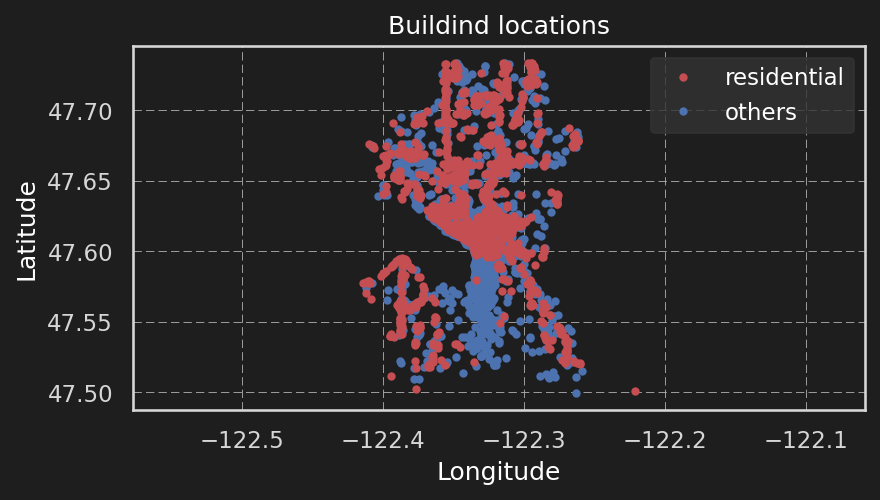

In [8]:
print('initial DataFrame shape:', df.shape )
sr_loc = df['BuildingType'].str.contains('multifamily')

fig, ax = plt.subplots( figsize=(16*cm,8*cm))
ax.plot( df.loc[sr_loc,'Longitude'], df.loc[sr_loc,'Latitude'], 'ro', markersize=3, label='residential', zorder=2 )
ax.plot( df.loc[~sr_loc,'Longitude'], df.loc[~sr_loc,'Latitude'], 'bo', markersize=3, label='others', zorder=1 )
ax.legend()
ax.axis('equal')
ax.set_title('Buildind locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

sr_loc = sr_loc[sr_loc]
df.drop( index=sr_loc.index, inplace=True )
print('DataFrame shape:', df.shape )
display( df['BuildingType'].value_counts() )

Définition d'une fonction pour déterminer les éléments correspondant à du `housing`

In [9]:
def is_housing( sr ):
    sr_loc = (sr.str.contains('hous|multifamily', na=False)) \
        & (~sr.str.contains('warehouse|courthouse', na=True))
    return sr_loc

Vérification et suppression à partir du `PrimaryPropertyType`

In [10]:
var = 'PrimaryPropertyType'
sr_loc = is_housing(df[var])
display( df.loc[sr_loc, var].value_counts() )
df.drop( index=sr_loc[sr_loc].index, inplace=True )
print('DataFrame shape:', df.shape )

low-rise multifamily    3
Name: PrimaryPropertyType, dtype: int64

DataFrame shape: (1665, 45)


1. Vérification et suppression pour le `LargestPropertyUseType`
2. Vérification des LargestPropertyUseType

In [11]:
vars = ['LargestPropertyUseType',
        'SecondLargestPropertyUseType',
        'ThirdLargestPropertyUseType']


sr_loc = is_housing( df[vars[0]] )


print('DataFrame shape:', df.shape )
display( f'housing find in {sr_loc.sum()} elements' )
display( df.loc[sr_loc, vars] )

df.drop( index=sr_loc[sr_loc].index, inplace=True )

print('DataFrame shape:', df.shape )

del vars, var

DataFrame shape: (1665, 45)


'housing find in 9 elements'

,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
164,multifamily housing,supermarket/grocery store,parking
1159,multifamily housing,office,parking
1839,multifamily housing,office,retail store
2314,multifamily housing,hotel,parking
2394,multifamily housing,parking,other
2748,multifamily housing,retail store,social/meeting hall
3003,multifamily housing,supermarket/grocery store,parking
3041,multifamily housing,parking,retail store
3087,multifamily housing,other - entertainment/public assembly,NaN


DataFrame shape: (1656, 45)


## 2.2. <a id='toc2_2_'></a>[Colonnes Outlier et DefaultData](#toc0_)

In [12]:
def value_counts( sr ):
    value_counts = sr.value_counts()
    return pd.DataFrame( {'count': value_counts.values, 
                        '%':value_counts.values*(100/len(sr)) },
                        index=value_counts.index)

print('Outlier:')
display( value_counts( df['Outlier'] ) )
print('DefaultData:')
display( value_counts( df['DefaultData'] ) )

Outlier:


,count,%
low outlier,14,0.845411
high outlier,2,0.120773


DefaultData:


,count,%
False,1568,94.68599
True,88,5.31401


Mapping des "Outliers"

In [13]:
df['Outlier'] = df['Outlier'].map( {'low outlier':-1, 'high outlier':1}).fillna(0).astype('int')

## 2.3. <a id='toc2_3_'></a>[Vérifications doublons](#toc0_)

In [14]:
print("Number of duplicated: {:}".format( df['OSEBuildingID'].duplicated().sum() ) )

Number of duplicated: 0


## 2.4. <a id='toc2_4_'></a>[Variables "inutiles"](#toc0_)

Vérification des variables inutiles: création d'une liste "à supprimer" (suppression faite à la fin)

In [15]:
vars_to_delete = ['OSEBuildingID', 'PropertyName',
        'TaxParcelIdentificationNumber',
        'Address', 'ListOfAllPropertyUseTypes']

In [16]:
vars_to_check = ['DataYear', 'City', 'State']

for var in vars_to_check:
    if not var in df.keys() :
        print( f'{var} not in DataFrame')
        continue
    sr = df[var].value_counts()
    display(sr)
    if len(sr) < 2:
        # df.drop( columns=var, inplace=True )
        vars_to_delete.append( var )
        print( f'{var} added to the drop list')

2016    1656
Name: DataYear, dtype: int64

DataYear added to the drop list


seattle    1656
Name: City, dtype: int64

City added to the drop list


wa    1656
Name: State, dtype: int64

State added to the drop list


## 2.5. <a id='toc2_5_'></a>[Variable liée à la date](#toc0_)
Une variable "AgeOfBuilding(s)" est créée à partir des variables "DataYear" et "YearBuilt".

La variables "DataYear" est remplacée puisque considérée comme inutile (une unique valeur: 2016).

In [17]:
df[['DataYear', 'YearBuilt']].info()
df['DataYear'] = df['DataYear'] - df['YearBuilt']
df.rename( columns={'DataYear':'AgeOfBuilding(s)'}, inplace=True )
vars_to_delete.append( 'YearBuilt' )

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1656 entries, 0 to 3375
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   DataYear   1656 non-null   int64
 1   YearBuilt  1656 non-null   int64
dtypes: int64(2)
memory usage: 38.8 KB


## 2.6. <a id='toc2_6_'></a>[Variable de localité](#toc0_)

In [18]:
mask = 'Neighborhood'
display( df[mask].value_counts() )

downtown                  357
greater duwamish          346
magnolia / queen anne     150
lake union                146
northeast                 127
east                      118
northwest                  86
ballard                    70
north                      67
central                    55
southeast                  46
delridge                   46
southwest                  41
delridge neighborhoods      1
Name: Neighborhood, dtype: int64

mapping "delridge neighborhoods" $\rightarrow$ "delridge"

In [19]:
df.loc[ df[mask] == 'delridge neighborhoods', mask ] = 'delridge'
display( df[mask].value_counts() )

downtown                 357
greater duwamish         346
magnolia / queen anne    150
lake union               146
northeast                127
east                     118
northwest                 86
ballard                   70
north                     67
central                   55
delridge                  47
southeast                 46
southwest                 41
Name: Neighborhood, dtype: int64

In [20]:
df['ZipCode'].value_counts()

98134.0    182
98104.0    156
98101.0    147
98109.0    140
98108.0    120
98122.0     90
98105.0     85
98121.0     83
98103.0     66
98119.0     62
98125.0     52
98115.0     51
98133.0     51
98107.0     49
98144.0     48
98118.0     46
98106.0     26
98102.0     26
98116.0     24
98126.0     22
98199.0     22
98112.0     21
98117.0     20
98195.0      9
98136.0      6
98155.0      4
98178.0      3
98146.0      3
98124.0      2
98177.0      2
98013.0      2
98168.0      2
98111.0      2
98154.0      2
98181.0      1
98185.0      1
98164.0      1
98006.0      1
98191.0      1
98053.0      1
98033.0      1
98070.0      1
98114.0      1
98165.0      1
98011.0      1
98113.0      1
98020.0      1
98145.0      1
Name: ZipCode, dtype: int64

Contigence ZipCode - Neighborhood

On note une corrélation partielle entre le ZipCode et le Neighborhood.
Cependant, certains ZipCode ne contiennent qu'une seule valeur.

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/03_energy/.venv/lib64/python3.10/site-packages/outdated/utils.py:14: OutdatedCheckFailedWarning: Failed to check for latest version of package.
Set the environment variable OUTDATED_RAISE_EXCEPTION=1 for a full traceback.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


Neighborhood,downtown,northwest,lake union,magnolia / queen anne,southwest,northeast,delridge,ballard,greater duwamish,east,southeast,north,Total
ZipCode,,,,,,,,,,,,,
98006,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
98011,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
98013,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
98020,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
98033,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
98053,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
98070,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
98101,131.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,14.0,NaN,NaN,147
98102,NaN,NaN,18.0,NaN,NaN,1.0,NaN,NaN,NaN,7.0,NaN,NaN,26


<Axes: xlabel='Neighborhood', ylabel='ZipCode'>

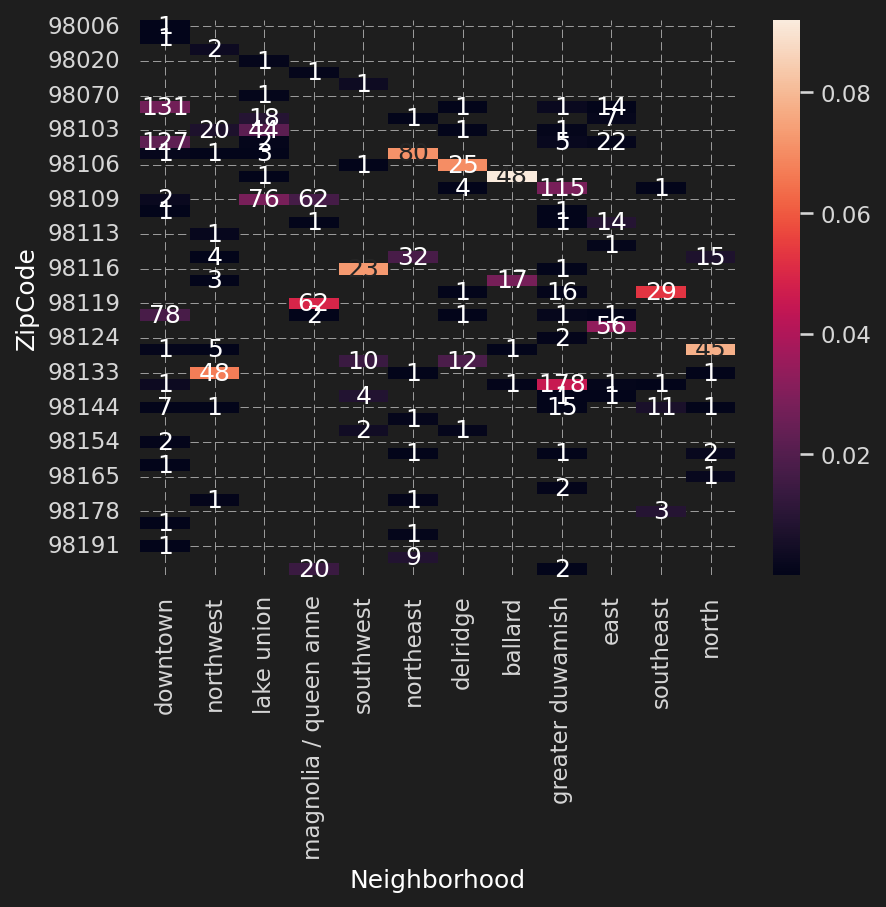

In [21]:
X = "ZipCode"
Y = "Neighborhood"

# display( df[X].value_counts())

tmp = df[[X,Y]].dropna()
tmp[X] = tmp[X].astype(int)
cont = tmp.pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total")
col_index = cont.fillna(0).values[:-1,:-1].argmax( 1 )
# display( col_index )
col_index = [id for i, id in enumerate(col_index) if not id in col_index[:i]] + [cont.shape[1]-1]
# display( col_index )
cont = cont.iloc[:, col_index]
display(cont)


tx = cont.loc[:,["Total"]]
ty = cont.loc[["Total"],:]
indep = tx @ ty / len(df)



# c = cont.fillna(0) # On remplace les valeurs nulles par 0
c = cont
measure = (c-indep)**2/indep
xi_n = measure.sum().sum()
table = measure/xi_n
sns.heatmap(table.iloc[:-1,:-1],annot=c.iloc[:-1,:-1], fmt='.0f')

In [22]:
vars_to_delete += ['ZipCode']

On affiche les zones sur une carte avec le package folium.

In [23]:
import folium
import folium.plugins

fig = folium.Figure(width=400, height=500)
seattle_map = folium.Map( location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=11).add_to(fig)

categories = df['Neighborhood'].value_counts().index
folim_colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'darkblue', 'darkgreen', 'cadetblue', 'darkpurple', 'lightblue', 'lightgreen', 'gray', 'black', 'lightgray']
# 'beige', 'white', 'pink',
dict_color = { categ:color for categ,color in zip( categories, folim_colors ) }

for lat, lon, categ in zip(df['Latitude'], df['Longitude'], df['Neighborhood']):
    folium.CircleMarker(
        [lat, lon],
        radius=5,
        popup = ( str(categ)
        #          'var 2 : ' + str(var2) + '<br>'
        #          'var 3: ' + str(var3) +'%'
                ),
        color=dict_color[categ],
        fill_color=dict_color[categ],
        fill=True,
        fill_opacity=0.9
        ).add_to(seattle_map)
seattle_map


## 2.7. <a id='toc2_7_'></a>[Recherche et gestion des NaN](#toc0_)
### 2.7.1. <a id='toc2_7_1_'></a>[Détection des NaN](#toc0_)
- Pour les Second & Third LargestPropertyUseType : uniquement 1 ou 2 utilisation du bâtiment $\rightarrow$ à gerer lors du hot encoding
- Pour le YearsENERGYSTARCertified : pas de certification
- Pour le ENERGYSTARscore : dropna à faire lors de la modélisation

In [24]:
sum_isna = df.isna().sum()
print( 'sum isna > 0:' )
display( sum_isna[sum_isna > 0])

sum isna > 0:


ZipCode                              16
NumberofBuildings                     2
ListOfAllPropertyUseTypes             2
LargestPropertyUseType                6
LargestPropertyUseTypeGFA             6
SecondLargestPropertyUseType        812
SecondLargestPropertyUseTypeGFA     812
ThirdLargestPropertyUseType        1312
ThirdLargestPropertyUseTypeGFA     1312
YearsENERGYSTARCertified           1558
ENERGYSTARScore                     566
SiteEUI(kBtu/sf)                      3
SiteEUIWN(kBtu/sf)                    3
SourceEUI(kBtu/sf)                    2
SourceEUIWN(kBtu/sf)                  2
SiteEnergyUse(kBtu)                   2
SiteEnergyUseWN(kBtu)                 3
SteamUse(kBtu)                        2
Electricity(kWh)                      2
Electricity(kBtu)                     2
NaturalGas(therms)                    2
NaturalGas(kBtu)                      2
TotalGHGEmissions                     2
GHGEmissionsIntensity                 2
dtype: int64

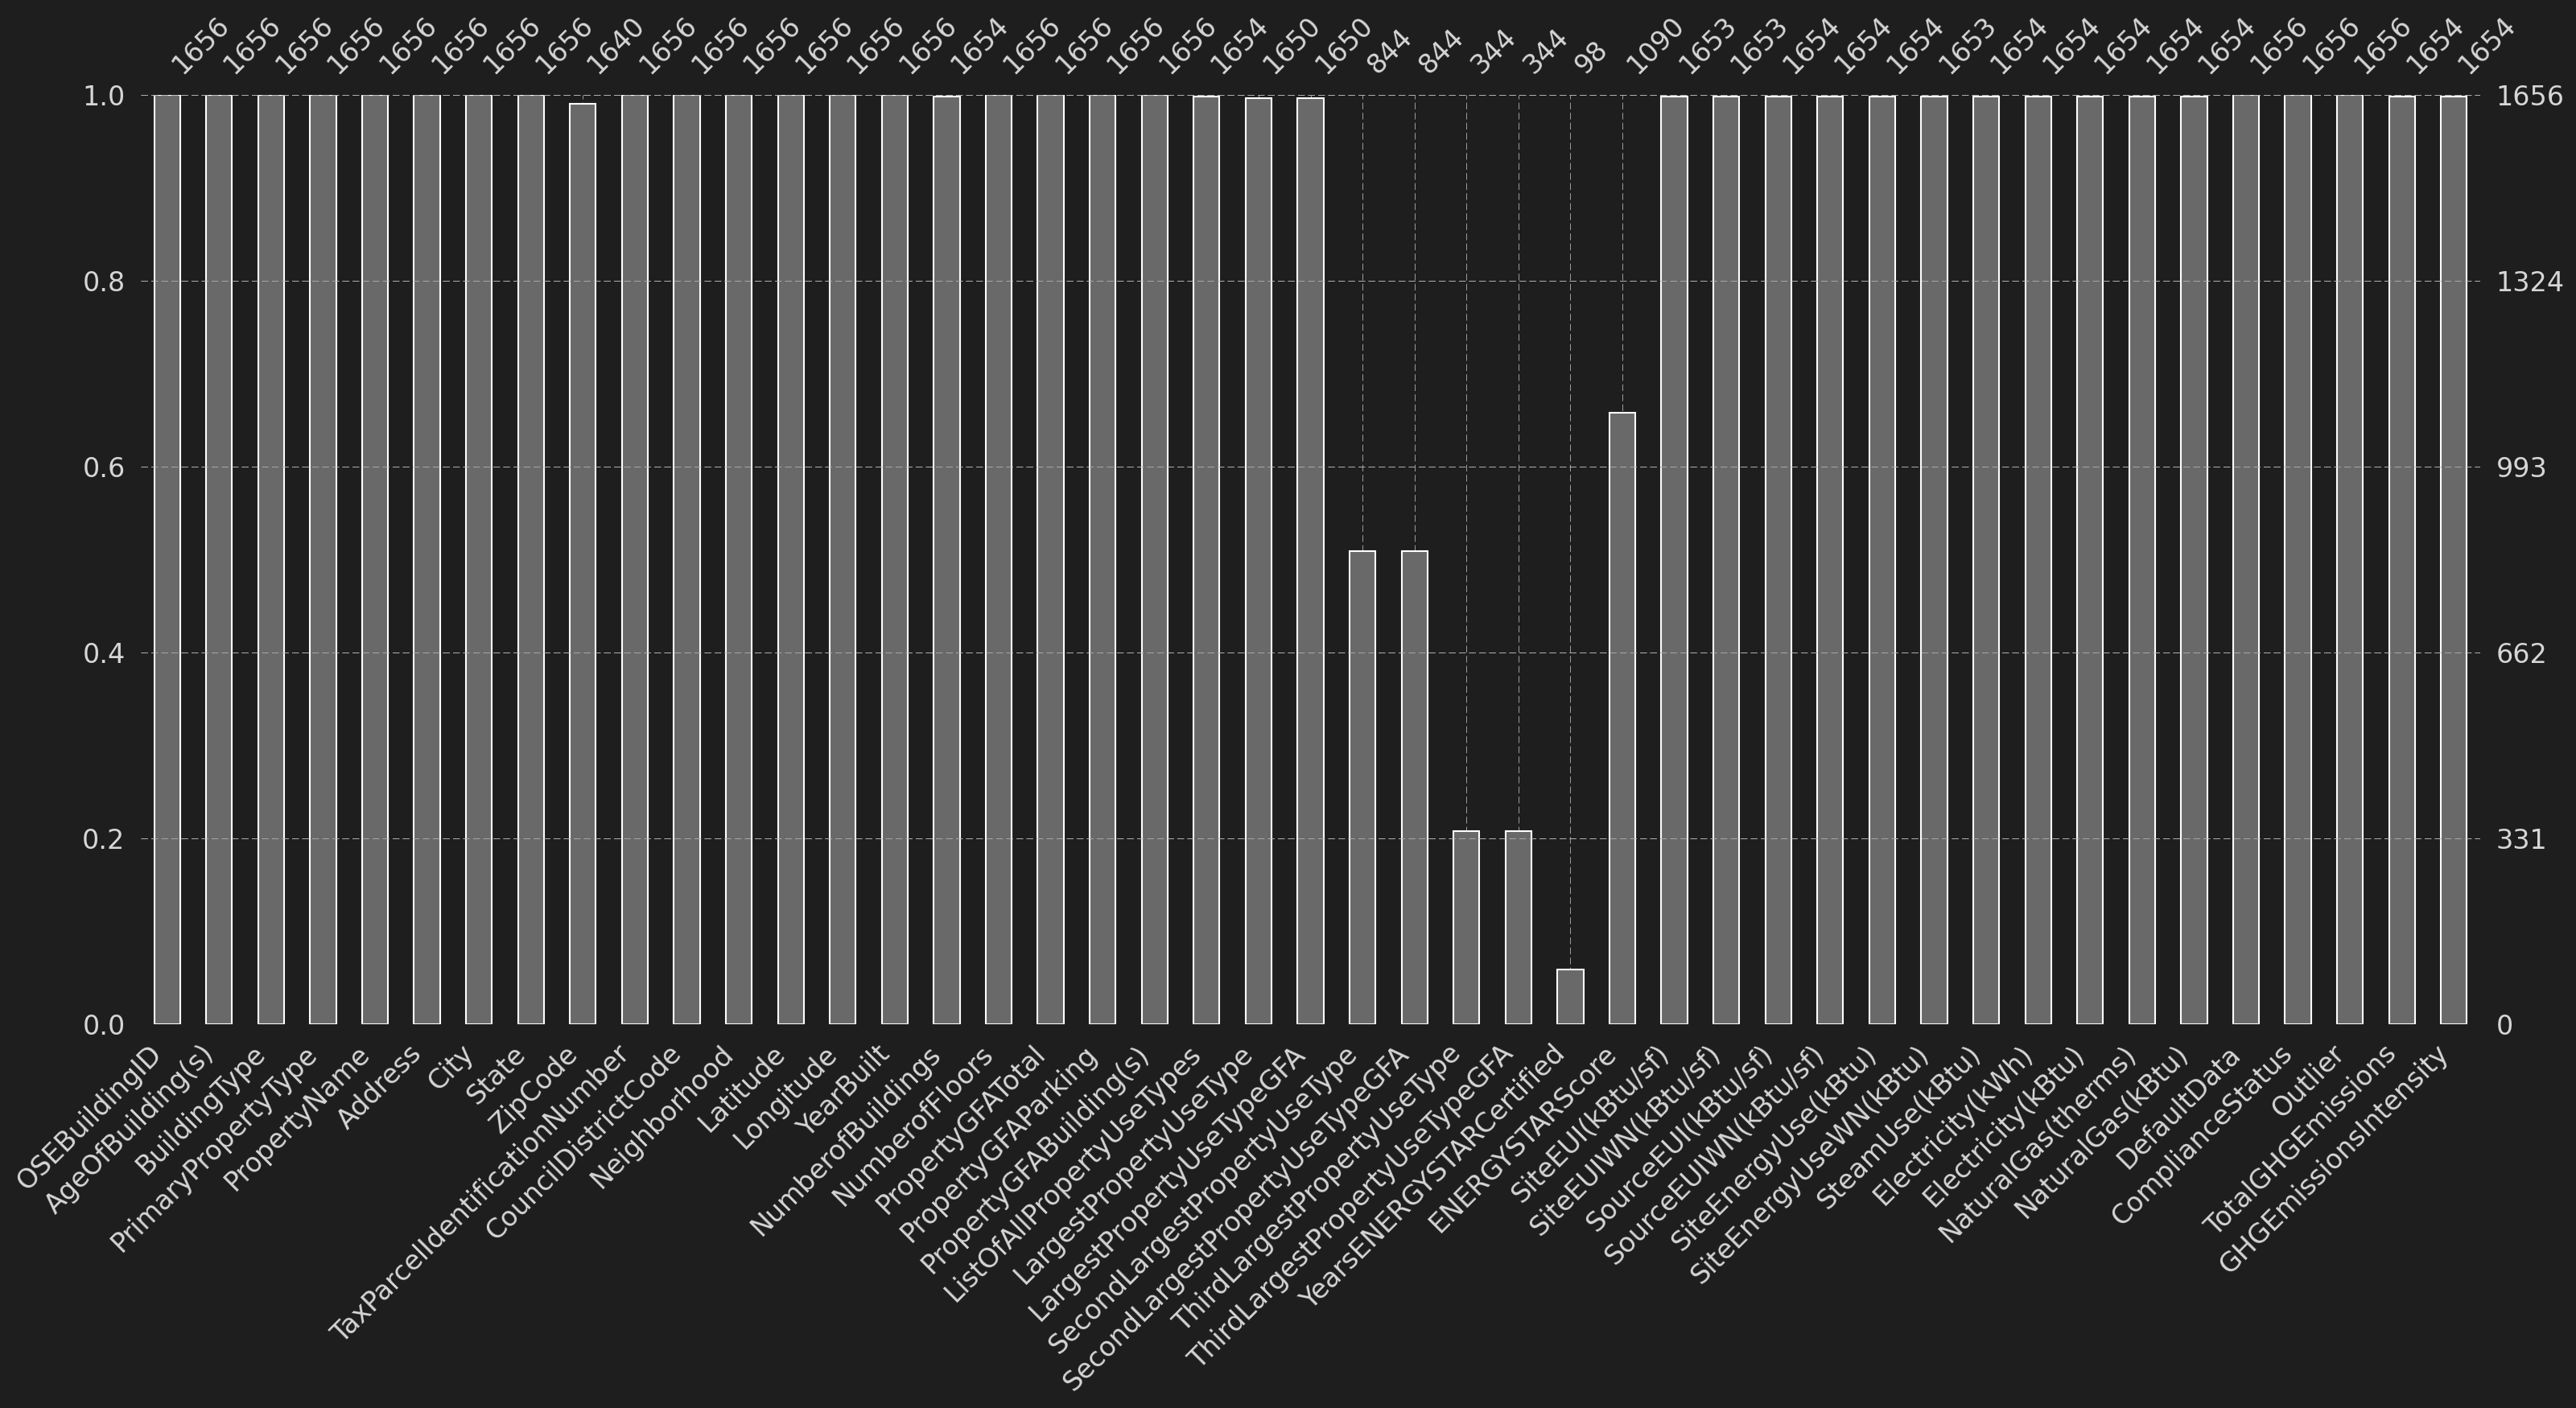

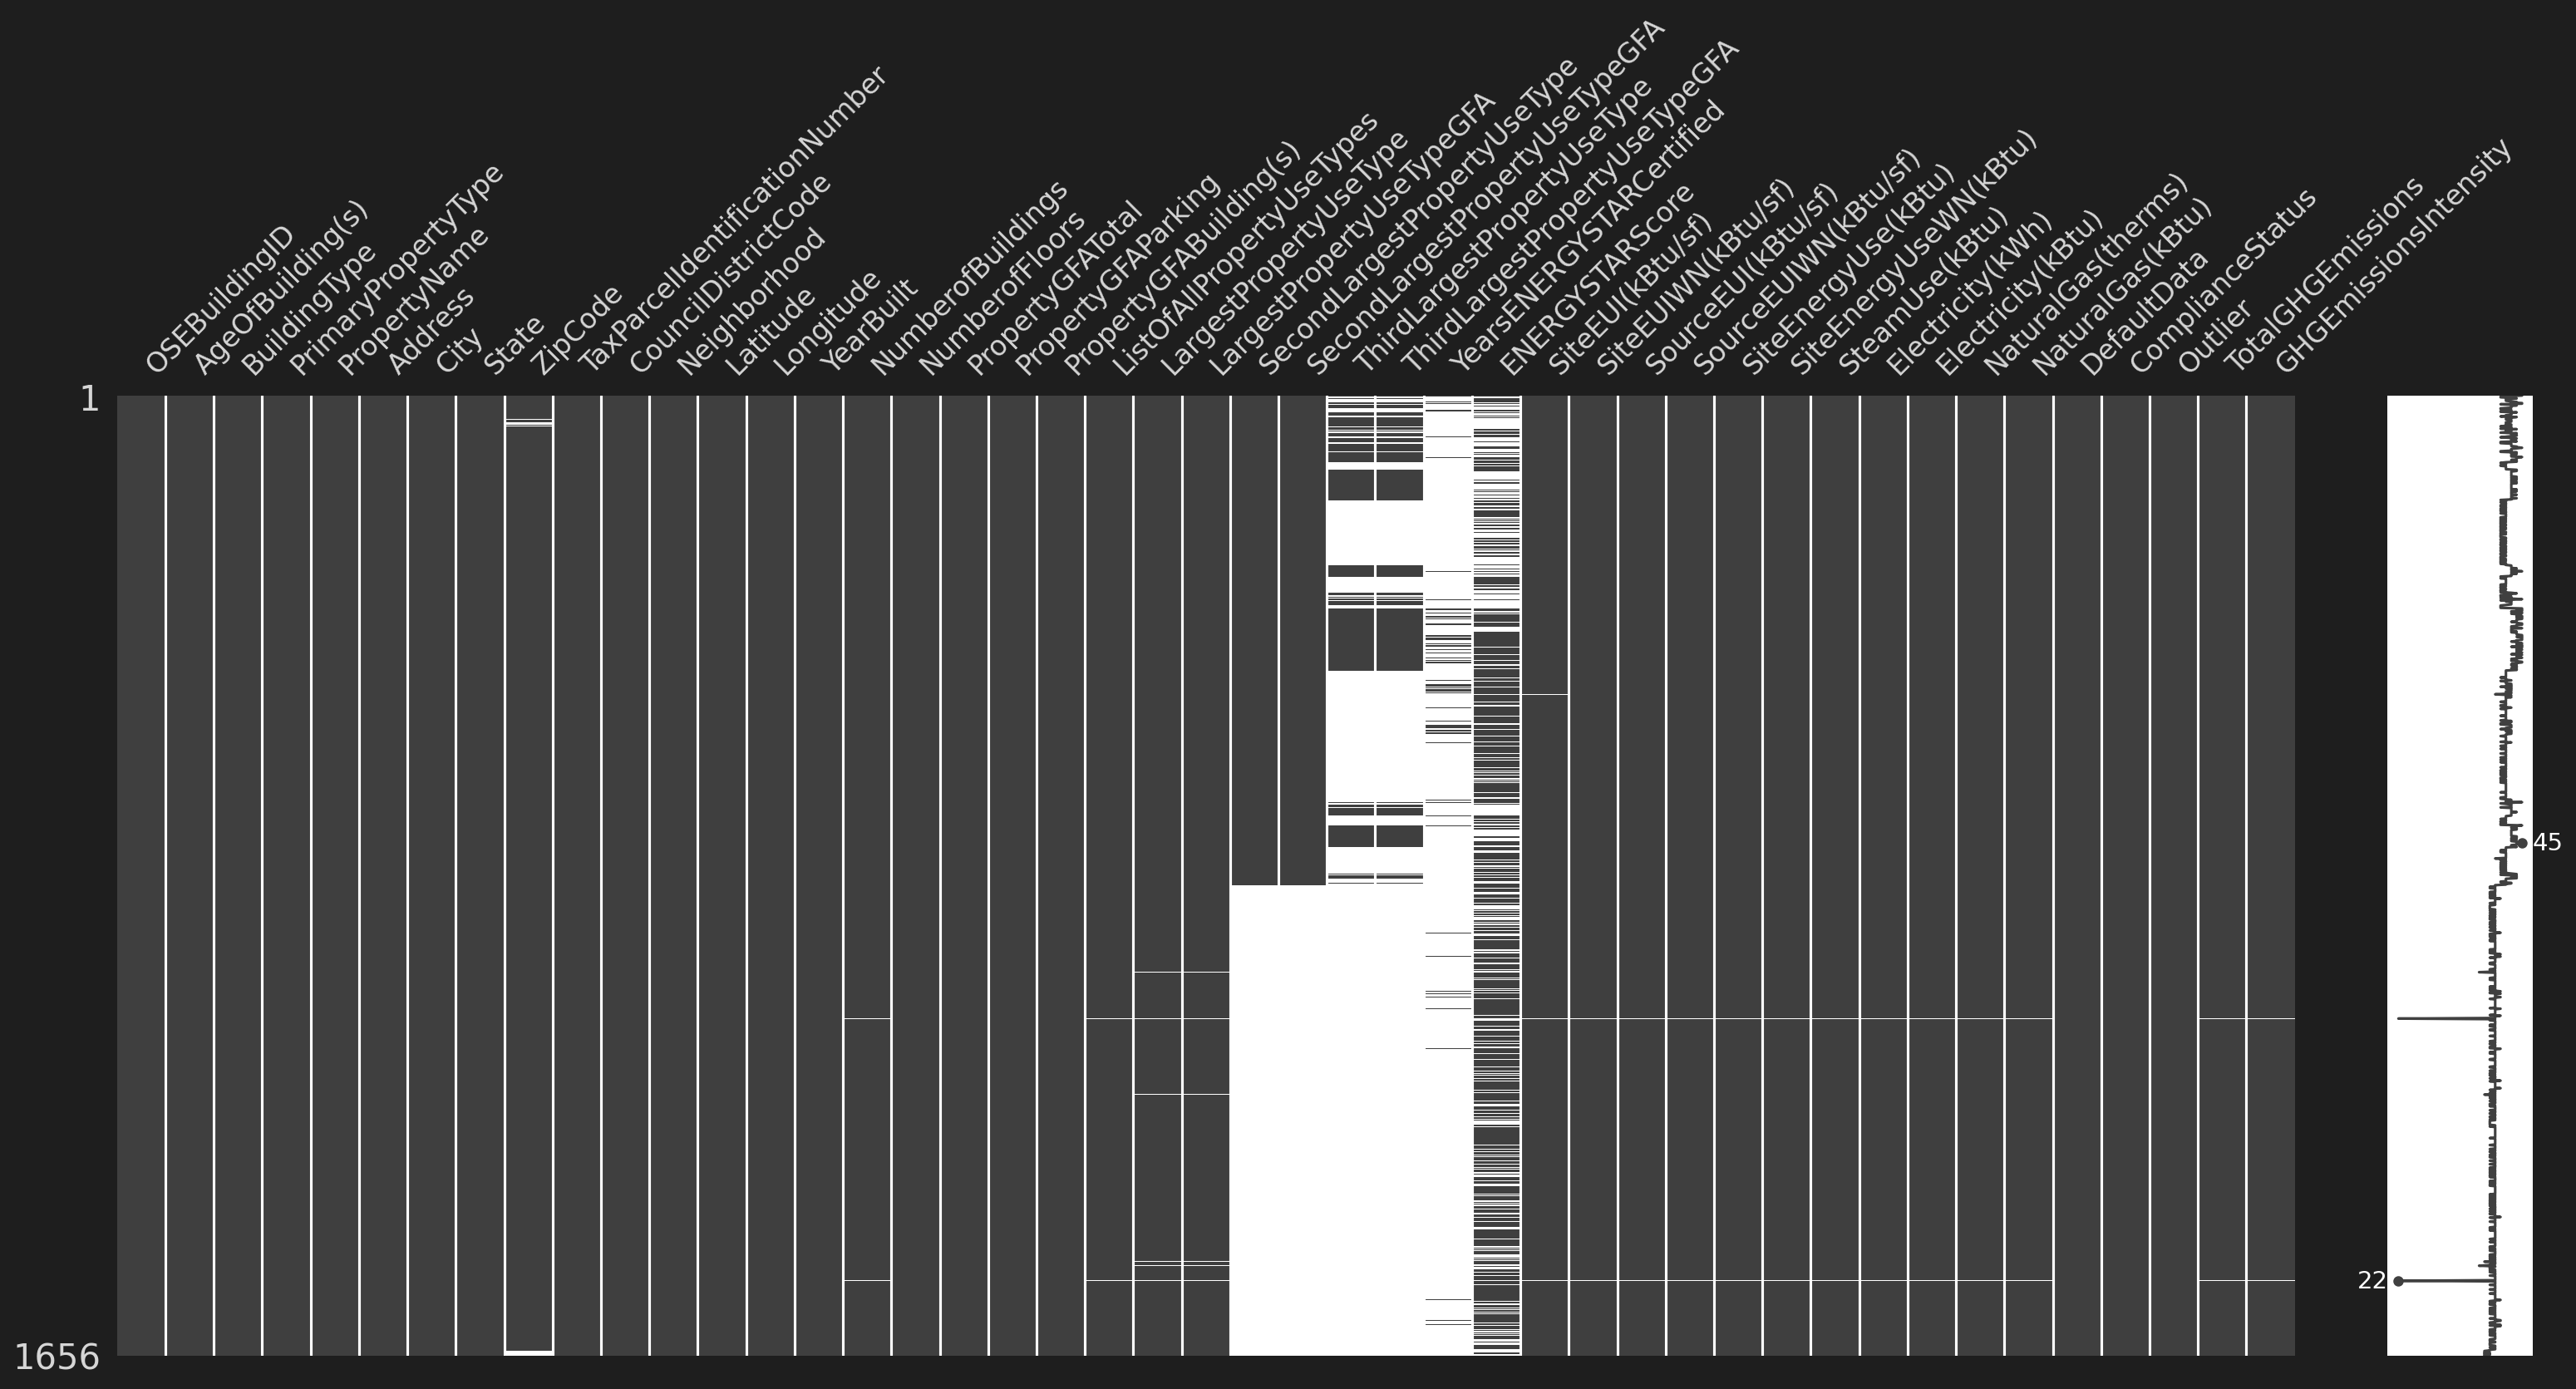

In [25]:
ax = msno.bar( df )
ax = msno.matrix( df.sort_values( by=['SecondLargestPropertyUseType','ThirdLargestPropertyUseType'] ) )

Il y a clairement des lignes avec un gros manque d'informations -> à enlever
- sur les energy : fillna(0) + sum(1) == 0 -> drop
- LargestPropertyUse : à remplir à partir du PrimaryPropertyType 

In [26]:
energy_keys = ['SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)',
'SteamUse(kBtu)', 
'Electricity(kWh)', 'Electricity(kBtu)',
'NaturalGas(therms)', 'NaturalGas(kBtu)',
'TotalGHGEmissions', 'GHGEmissionsIntensity']

property_use_keys = [ 'PrimaryPropertyType', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType']

others = ['NumberofBuildings']

keys = property_use_keys + others + energy_keys

sr_loc = df[keys].isna().sum(1) > 0
print('Entries with empty cells:')
display( df.loc[sr_loc, keys])

# DROP DATA WITHOUT ENERGY INFORMATION / CONSUMPTION
indexes = (df[energy_keys].fillna(0.).sum(1) == 0.)
indexes = indexes[indexes].index
print('indexes to drop:', indexes.values)
print('DataFrame shape:', df.shape)
df.drop( index=indexes , inplace=True )

print('Entries with empty cells (after drop):')
sr_loc = df[keys].isna().sum(1) > 0
display( df.loc[sr_loc, keys])
print('DataFrame shape:', df.shape)

Entries with empty cells:


,PrimaryPropertyType,ListOfAllPropertyUseTypes,LargestPropertyUseType,NumberofBuildings,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
304,other,"convention center, parking",convention center,1.0,NaN,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000,0.0,0.00,0.00
353,self-storage facility,"fitness center/health club/gym, office, other ...",NaN,2.0,47.799999,51.000000,103.000000,106.400002,5.697472e+06,6.076957e+06,0.0,8.814520e+05,3007514.0,26899.582030,2689958.0,163.83,1.47
563,large office,"office, retail store",office,1.0,39.500000,NaN,128.000000,0.000000,5.177270e+06,NaN,0.0,1.427645e+06,4871126.0,14160.409180,1416041.0,109.16,0.83
578,small- and mid-sized office,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1147,hotel,hotel,NaN,1.0,52.200001,53.500000,150.399994,154.399994,2.897080e+06,2.968430e+06,0.0,7.428464e+05,2534592.0,3624.875244,362488.0,36.92,0.60
2414,small- and mid-sized office,office,NaN,1.0,72.199997,74.699997,226.600006,234.600006,3.168131e+06,3.280956e+06,0.0,9.285260e+05,3168131.0,0.000000,0.0,22.09,0.46
2459,restaurant,restaurant,NaN,1.0,31.200001,32.500000,62.000000,62.799999,8.999242e+05,9.358332e+05,0.0,1.180853e+05,402907.0,4970.169922,497017.0,29.21,1.01
2670,mixed use property,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


indexes to drop: [  28  152  304  578  746 1361 2670]
DataFrame shape: (1656, 45)
Entries with empty cells (after drop):


,PrimaryPropertyType,ListOfAllPropertyUseTypes,LargestPropertyUseType,NumberofBuildings,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
353,self-storage facility,"fitness center/health club/gym, office, other ...",NaN,2.0,47.799999,51.000000,103.000000,106.400002,5.697472e+06,6.076957e+06,0.0,8.814520e+05,3007514.0,26899.582030,2689958.0,163.83,1.47
563,large office,"office, retail store",office,1.0,39.500000,NaN,128.000000,0.000000,5.177270e+06,NaN,0.0,1.427645e+06,4871126.0,14160.409180,1416041.0,109.16,0.83
1147,hotel,hotel,NaN,1.0,52.200001,53.500000,150.399994,154.399994,2.897080e+06,2.968430e+06,0.0,7.428464e+05,2534592.0,3624.875244,362488.0,36.92,0.60
2414,small- and mid-sized office,office,NaN,1.0,72.199997,74.699997,226.600006,234.600006,3.168131e+06,3.280956e+06,0.0,9.285260e+05,3168131.0,0.000000,0.0,22.09,0.46
2459,restaurant,restaurant,NaN,1.0,31.200001,32.500000,62.000000,62.799999,8.999242e+05,9.358332e+05,0.0,1.180853e+05,402907.0,4970.169922,497017.0,29.21,1.01


DataFrame shape: (1649, 45)


### 2.7.2. <a id='toc2_7_2_'></a>[Remplissage des NaN](#toc0_)
On regarde les éléments sans LargestPropertyUseType

In [27]:
vars = ['PrimaryPropertyType', 'ListOfAllPropertyUseTypes',
        'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'PropertyGFABuilding(s)',
        'PropertyGFAParking', 'PropertyGFATotal' ]
sr_loc = (df['LargestPropertyUseType'].isna())
display( df.loc[sr_loc,vars])

,PrimaryPropertyType,ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,PropertyGFABuilding(s),PropertyGFAParking,PropertyGFATotal
353,self-storage facility,"fitness center/health club/gym, office, other ...",NaN,NaN,111445,0,111445
1147,hotel,hotel,NaN,NaN,61721,0,61721
2414,small- and mid-sized office,office,NaN,NaN,48350,0,48350
2459,restaurant,restaurant,NaN,NaN,28800,0,28800


In [28]:
display( df.loc[ df['PrimaryPropertyType']=="self-storage facility", 'LargestPropertyUseType'].value_counts() )
display( df.loc[ df['PrimaryPropertyType'].str.contains('office'), 'LargestPropertyUseType'].value_counts() )

self-storage facility    27
Name: LargestPropertyUseType, dtype: int64

office            466
medical office     39
Name: LargestPropertyUseType, dtype: int64

À priori on peut replacer les valeurs manquantes de "LargestPropertyUseType(GFA)" par la "PrimaryPropertyType" / le "PropertyGFABuilding(s)".

Note: si présence de "office" dans le "PrimaryPropertyType", alors la valeur est "office" (pas de distinctions pour les "LargestPropertyUseType")

In [29]:
for index in sr_loc[sr_loc].index:
    Primary = df.at[index, 'PrimaryPropertyType']
    df.at[index, 'LargestPropertyUseTypeGFA'] = df.at[index, 'PropertyGFABuilding(s)']
    if 'office' in Primary:
        df.at[index, 'LargestPropertyUseType'] = 'office'
        continue
    df.at[index, 'LargestPropertyUseType'] = Primary

On vérifie le résultat:

In [30]:
display( df.loc[sr_loc,vars] )

,PrimaryPropertyType,ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,PropertyGFABuilding(s),PropertyGFAParking,PropertyGFATotal
353,self-storage facility,"fitness center/health club/gym, office, other ...",self-storage facility,111445.0,111445,0,111445
1147,hotel,hotel,hotel,61721.0,61721,0,61721
2414,small- and mid-sized office,office,office,48350.0,48350,0,48350
2459,restaurant,restaurant,restaurant,28800.0,28800,0,28800


In [31]:
sum_isna = df.isna().sum()
print( 'sum isna > 0:' )
display( sum_isna[sum_isna > 0])

sum isna > 0:


ZipCode                              16
SecondLargestPropertyUseType        806
SecondLargestPropertyUseTypeGFA     806
ThirdLargestPropertyUseType        1305
ThirdLargestPropertyUseTypeGFA     1305
YearsENERGYSTARCertified           1551
ENERGYSTARScore                     560
SiteEUIWN(kBtu/sf)                    1
SiteEnergyUseWN(kBtu)                 1
dtype: int64

Remplissage du ZipCode à partir de la longitude et de la latitude: toutes les données étant à Seattle, les variables `Longitude` et `Latitude` peuvent être utilisée comme (`x`,`y`).

Si il y avait plus d'écarts entre les positions, possibilité d'utilisé la formule `haversine`.

In [32]:
sr_loc = df['ZipCode'].isna()
for index in sr_loc[sr_loc].index:
    x,y = df.loc[index, ['Longitude', 'Latitude']].values
    for value in df['Longitude']:
        if isinstance( value, str):
            print('value:', value)
    df['Longitude'].values-x
    df['Latitude'].values-y
    argsort = ((df['Longitude'].values-x)**2 + (df['Latitude'].values-y)**2).argsort()
    for i in argsort[1:]: # neglect the first as it corresponds to the current index
        if np.isnan( df['ZipCode'].iloc[i] ) :
            continue
        df.at[index, 'ZipCode'] = df['ZipCode'].iloc[i]
        break 
    # print('\nx,y:', x,y, '\nx2,y2:', df[['Longitude','Latitude']].iloc[i,:].values )

df['ZipCode'] = df['ZipCode'].astype(int)

sum_isna = df.isna().sum()
print( 'After procees sum isna > 0:' )
display( sum_isna[sum_isna > 0])

After procees sum isna > 0:


SecondLargestPropertyUseType        806
SecondLargestPropertyUseTypeGFA     806
ThirdLargestPropertyUseType        1305
ThirdLargestPropertyUseTypeGFA     1305
YearsENERGYSTARCertified           1551
ENERGYSTARScore                     560
SiteEUIWN(kBtu/sf)                    1
SiteEnergyUseWN(kBtu)                 1
dtype: int64

## 2.8. <a id='toc2_8_'></a>[Recherches à partir des variables "DefaultData" et "ComplianceStatus"](#toc0_)

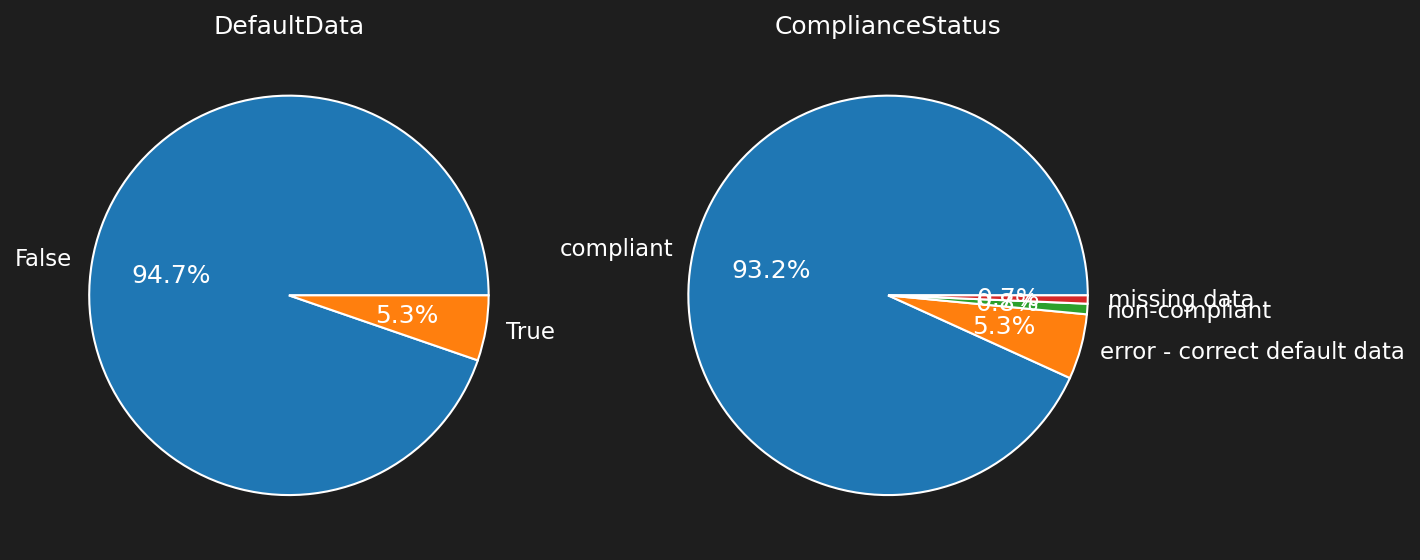

In [33]:
fig, axs = plt.subplots( ncols=2, figsize=(24*cm,12*cm))
for ax, key in zip( axs, ['DefaultData', 'ComplianceStatus']):
    df[key].value_counts(normalize=True).plot( kind='pie', ax=ax, autopct='%.1f%%' )
    ax.set_title( key)
    ax.set_ylabel('')
savefig( fig, 'Figures/outliers_compliant.pdf')

On peut se poser la question de l'intérêt de supprimer certaines entrées.

Dans l'idée, les données seront mesurées pour les nouveaux bâtiments, donc autant enlever les entrées avec des valeurs imputées.

In [34]:
sr_loc = df['DefaultData'] | ( df['ComplianceStatus'].str.contains( '|'.join( ['missing', 'error'] ) ) )
df.drop( index=sr_loc[sr_loc].index ,inplace=True )

***
# 3. <a id='toc3_'></a>[Vérifications des données d'entrée](#toc0_)

In [35]:
df.columns

Index(['OSEBuildingID', 'AgeOfBuilding(s)', 'BuildingType',
       'PrimaryPropertyType', 'PropertyName', 'Address', 'City', 'State',
       'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode',
       'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)',
       'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)',
       'DefaultData', 'ComplianceStatus', 'Outlier', '

## 3.1. <a id='toc3_1_'></a>[Value_counts des variables](#toc0_)

In [36]:
print('DataFrame shape:', df.shape )

DataFrame shape: (1551, 45)


In [37]:
vars = ['BuildingType', 'PrimaryPropertyType',
       'Neighborhood', 'NumberofBuildings',
       'NumberofFloors', 'LargestPropertyUseType',
        'SecondLargestPropertyUseType',
        'ThirdLargestPropertyUseType',
       ]
for var in vars:
    print( f'{var} value_counts:')
    display( df[var].value_counts() )

BuildingType value_counts:


nonresidential        1435
nonresidential cos      82
campus                  23
sps-district k-12       10
nonresidential wa        1
Name: BuildingType, dtype: int64

PrimaryPropertyType value_counts:


small- and mid-sized office    289
other                          248
warehouse                      185
large office                   172
mixed use property             104
retail store                    86
hotel                           76
worship facility                71
distribution center             53
k-12 school                     51
supermarket / grocery store     40
medical office                  39
self-storage facility           28
university                      24
residence hall                  21
senior care community           20
refrigerated warehouse          12
restaurant                      12
hospital                        10
laboratory                      10
Name: PrimaryPropertyType, dtype: int64

Neighborhood value_counts:


...

office                                                  492
non-refrigerated warehouse                              197
other                                                    98
retail store                                             94
hotel                                                    77
worship facility                                         71
distribution center                                      54
k-12 school                                              51
supermarket/grocery store                                41
medical office                                           41
other - recreation                                       31
parking                                                  30
self-storage facility                                    28
college/university                                       24
residence hall/dormitory                                 22
other - entertainment/public assembly                    21
senior care community                   

SecondLargestPropertyUseType value_counts:


parking                                                 332
office                                                  165
retail store                                             82
other                                                    44
restaurant                                               29
non-refrigerated warehouse                               28
fitness center/health club/gym                           16
data center                                              13
multifamily housing                                      12
other - services                                         11
laboratory                                                8
medical office                                            8
supermarket/grocery store                                 7
distribution center                                       7
bank branch                                               7
other - entertainment/public assembly                     6
k-12 school                             

ThirdLargestPropertyUseType value_counts:


office                                                  49
retail store                                            45
parking                                                 41
other                                                   38
restaurant                                              31
data center                                             14
non-refrigerated warehouse                              14
multifamily housing                                     12
swimming pool                                           10
medical office                                           9
food service                                             8
pre-school/daycare                                       8
social/meeting hall                                      7
bank branch                                              5
other - restaurant/bar                                   5
financial office                                         4
fitness center/health club/gym                          

Il semble incohérent d'avoir 0 bâtiments. Idem pour "number of floors" qui, en anglais, prend en compte le rez-de-chaussé.

In [38]:
for X in ['NumberofBuildings', 'NumberofFloors']:
    df.loc[ df[X]==0, X ] = 1
df['NumberofBuildings'] = df['NumberofBuildings'].astype(int)

## 3.2. <a id='toc3_2_'></a>[Diverses vérifications](#toc0_)

### 3.2.1. <a id='toc3_2_1_'></a>[Number of floors](#toc0_)
On regarde les number of floors pour voir si il y a des valeurs aberrantes

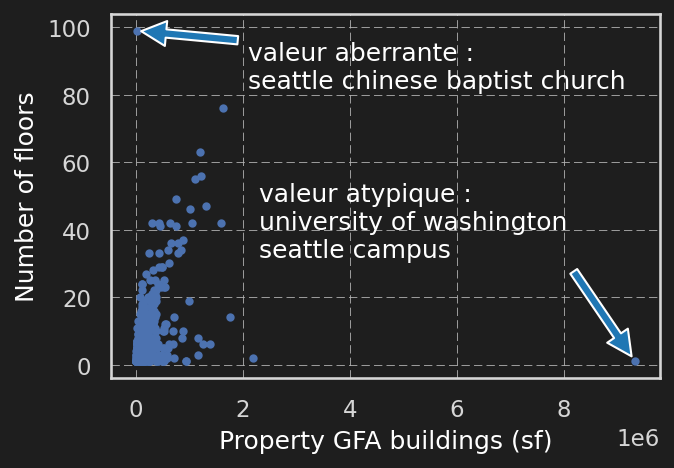

In [39]:
X, Y = 'PropertyGFABuilding(s)', 'NumberofFloors'

fig, ax = plt.subplots( figsize=(12*cm,8*cm) )
ax.plot( df[X], df[Y], 'bo', markersize=3 )

ax.set_ylabel( 'Number of floors' )
ax.set_xlabel( 'Property GFA buildings (sf)' )

index_100 = df[Y] > 90
index_100 = index_100[index_100].index.values[0]

_ = ax.annotate( 'valeur aberrante :\n{:}'.format( 
                df.at[index_100, 'PropertyName'] ),
                xy=[0, 99], xytext=[2.1e6, 82],# ha='left', va='center',
                arrowprops=dict(shrink=0.05) )

index_high_GFA = df[X] > 8e6
index_high_GFA = index_high_GFA[index_high_GFA].index.values[0]

_ = ax.annotate( 'valeur atypique :\n{:}'.format( 
                df.at[index_high_GFA, 'PropertyName'].replace(' - ', '\n') ),
                xy=[df.at[index_high_GFA , X], 1], xytext=[2.3e6, 32],# ha='left', va='center',
                arrowprops=dict(shrink=0.05) )

On assigne la valeur la plus utilisée pour NumberofFloors: 1, sachant que la surface est relativement faible.

In [40]:
df.at[index_100, Y] = 1

### 3.2.2. <a id='toc3_2_2_'></a>[Number of Buildings](#toc0_)

Certains `NumberofBuildings` sont particulièrement élevés, mais à priori OK.

In [41]:
mask = 'NumberofBuildings'
df.loc[ df[mask] > 5, :].sort_values( by=mask )

,OSEBuildingID,AgeOfBuilding(s),BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
124,198,63,nonresidential,hospital,seattle children's hospital main campus,4800 sand point way ne,seattle,wa,98105,2982800005,4,northeast,47.662310,-122.281460,1953,6,10,879000,0,879000,hospital (general medical & surgical),hospital (general medical & surgical),879000.0,NaN,NaN,NaN,NaN,NaN,10.0,288.799988,293.200012,578.200012,576.599976,2.538325e+08,2.577642e+08,0.0,3.389250e+07,115641210.0,1.381912e+06,138191238.0,False,compliant,0,8145.52,9.27
167,268,26,nonresidential,hospital,swedish cherry hill,500 17th ave,seattle,wa,98122,7942600331,3,central,47.607050,-122.309660,1990,6,5,597519,0,597519,"hospital (general medical & surgical), parking",hospital (general medical & surgical),601615.0,parking,48607.0,NaN,NaN,NaN,34.0,238.399994,244.800003,454.399994,459.200012,1.434230e+08,1.472991e+08,0.0,1.722008e+07,58754927.0,8.466809e+05,84668094.0,False,compliant,0,4906.33,8.21
364,516,52,nonresidential,other,aurora shopping center,13201 aurora avenue north,seattle,wa,98133,1926049215,5,northwest,47.725460,-122.346590,1964,6,1,111900,0,111900,"parking, strip mall",strip mall,124231.0,parking,0.0,NaN,NaN,NaN,NaN,79.000000,81.099998,190.500000,193.000000,9.814820e+06,1.007999e+07,0.0,1.872845e+06,6390148.0,3.424670e+04,3424670.0,False,compliant,0,226.43,2.02
2901,27389,60,nonresidential,small- and mid-sized office,leschi lakecenter,120 lakeside,seattle,wa,98122,4114601145,3,central,47.602070,-122.284810,1956,6,2,75868,0,75868,"non-refrigerated warehouse, office, restaurant...",office,50379.0,restaurant,12622.0,retail store,6662.0,NaN,NaN,47.500000,47.500000,149.199997,149.199997,3.605750e+06,3.605750e+06,0.0,1.056785e+06,3605750.0,0.000000e+00,0.0,False,compliant,0,25.14,0.33
618,828,22,nonresidential,hospital,swedish first hill,747 broadway,seattle,wa,98122,1978201096,3,east,47.608951,-122.322402,1994,7,14,1765970,0,1765970,"hospital (general medical & surgical), parking",hospital (general medical & surgical),1639334.0,parking,441551.0,NaN,NaN,NaN,54.0,177.899994,180.500000,377.000000,378.399994,2.916144e+08,2.959299e+08,134943456.0,4.084256e+07,139354828.0,1.731612e+05,17316120.0,False,compliant,0,12307.16,6.97
1672,23071,50,nonresidential,hospital,main hospital - all wings,facilities management ms: b-120,seattle,wa,98133,3026049130,5,northwest,47.714250,-122.336890,1966,8,1,415632,0,415632,"hospital (general medical & surgical), parking",hospital (general medical & surgical),483520.0,parking,266833.0,NaN,NaN,NaN,85.0,204.699997,207.500000,400.200012,402.100006,9.896078e+07,1.003283e+08,0.0,1.256277e+07,42864158.0,5.609661e+05,56096612.0,False,compliant,0,3278.11,7.89
3168,49705,87,nonresidential cos,other,magnuson,7400 sand point way ne,seattle,wa,98115,0225049062,4,northeast,47.682120,-122.263300,1929,8,1,502030,0,502030,other - recreation,other - recreation,564258.0,NaN,NaN,NaN,NaN,NaN,NaN,32.700001,36.599998,69.000000,74.300003,1.847034e+07,2.067295e+07,0.0,2.743225e+06,9359884.0,9.110455e+04,9110455.0,False,compliant,0,549.11,1.09
170,276,16,nonresidential,hospital,harborview medical center,325 9th ave.,seattle,wa,98104,8590900220,3,east,47.603990,-122.323770,2000,9,8,1158691,0,1158691,"hospital (general medical & surgical), parking",ho

### 3.2.3. <a id='toc3_2_3_'></a>[PorpertyGFA](#toc0_)

`university of washington - seattle campus` et `entire campus` correspondent à des valeurs `atypique` mais non aberrantes

In [42]:
mask = 'PropertyGFATotal'
describe = df[mask].describe()
print(mask)
display(describe)

print('Q3 + 1.5*IQ = {:.3e}'.format( describe['75%'] 
            + 1.5*(describe['75%']-describe['25%']) ) )

df_sorted = df.sort_values( by=mask, ascending=False ).iloc[:5,:]
display( df_sorted )

PropertyGFATotal


count    1.551000e+03
mean     1.205977e+05
std      3.050729e+05
min      1.128500e+04
25%      2.880400e+04
50%      4.813900e+04
75%      1.077510e+05
max      9.320156e+06
Name: PropertyGFATotal, dtype: float64

Q3 + 1.5*IQ = 2.262e+05


,OSEBuildingID,AgeOfBuilding(s),BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
3274,49967,116,campus,university,university of washington - seattle campus,ne 45th st & brooklyn ave,seattle,wa,98105,1625049001,4,northeast,47.656440,-122.310410,1900,111,1,9320156,0,9320156,college/university,college/university,9320156.0,NaN,NaN,NaN,NaN,NaN,NaN,93.800003,0.000000,246.600006,0.000000,873923712.0,0.0,8.498524e+07,192577488.0,657074389.0,0.00000,0.0,False,compliant,0,11140.56,1.20
1494,22062,77,campus,university,entire campus,901 12th avenue,seattle,wa,98122,2254500880,3,east,47.610650,-122.317110,1939,1,2,2200000,0,2200000,"college/university, parking",college/university,1719643.0,parking,318960.0,NaN,NaN,NaN,NaN,66.699997,71.599998,145.000000,151.300003,114648520.0,123205560.0,0.000000e+00,18075270.0,61672821.0,529756.93750,52975694.0,False,compliant,0,3243.48,1.47
559,775,31,nonresidential,large office,columbia center - 2015,701 5th avenue,seattle,wa,98104,0942000640,7,downtown,47.604540,-122.330720,1985,1,76,1952220,319400,1632820,"office, parking",office,1680937.0,parking,319368.0,NaN,NaN,2017201620152012200920072006,86.0,55.299999,55.099998,167.300003,166.500000,92937640.0,92537256.0,0.000000e+00,25747908.0,87851862.0,50857.63281,5085763.0,False,compliant,0,882.56,0.45
618,828,22,nonresidential,hospital,swedish first hill,747 broadway,seattle,wa,98122,1978201096,3,east,47.608951,-122.322402,1994,7,14,1765970,0,1765970,"hospital (general medical & surgical), parking",hospital (general medical & surgical),1639334.0,parking,441551.0,NaN,NaN,NaN,54.0,177.899994,180.500000,377.000000,378.399994,291614432.0,295929888.0,1.349435e+08,40842564.0,139354828.0,173161.20310,17316120.0,False,compliant,0,12307.16,6.97
292,422,27,nonresidential,large office,two union square,601 union st.,seattle,wa,98101,1976700125,7,downtown,47.610430,-122.332060,1989,1,56,1605578,389860,1215718,"office, other, parking",office,1314475.0,parking,389860.0,other,30744.0,20092005,97.0,36.799999,37.900002,110.300003,113.300003,49517704.0,50984500.0,9.156549e+05,13505807.0,46081813.0,25202.29883,2520230.0,False,compliant,0,525.78,0.33


Les 2 universités sont des valeurs atypiques.

In [43]:
if False: # suppression des valeurs si True
    print('DataFrame shape:', df.shape)
    display( df_sorted.iloc[:2,:] )
    df.drop( index=df_sorted.index[:2], inplace=True )
    print('DataFrame shape:', df.shape)

### 3.2.4. <a id='toc3_2_4_'></a>[GFA parking](#toc0_)
La plupart des bâtiments semblent ne pas avoir de parkings.

In [44]:
mask = 'PropertyGFAParking'
describe = df[mask].describe()
print('Q3 + 1.5*IQ = {:.3e}'.format( describe['75%'] 
            + 1.5*(describe['75%']-describe['25%']) ) )
display(describe.T)
df.sort_values( by=mask, ascending=False ).iloc[:5,:]

Q3 + 1.5*IQ = 0.000e+00


count      1551.000000
mean      13744.232753
std       43619.470741
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      512608.000000
Name: PropertyGFAParking, dtype: float64

,OSEBuildingID,AgeOfBuilding(s),BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
273,402,27,nonresidential,large office,us bank centre,1420 5th avenue,seattle,wa,98101,1975700080,7,downtown,47.61054,-122.33466,1989,1,46,1536606,512608,1023998,"financial office, office, other, parking, rest...",office,1002403.0,parking,377046.0,other,53116.0,201720162014201320122011201020092007,89.0,51.900002,53.599998,157.300003,162.699997,56606136.0,58506844.0,0.000,15729209.00,53668061.0,29380.69922,2938070.0,False,compliant,0,530.18,0.35
307,438,24,nonresidential,medical office,1101 madison tower,1101 madison,seattle,wa,98104,1978200625,3,east,47.60921,-122.32425,1992,1,14,690158,407795,282363,"medical office, parking",medical office,270384.0,parking,270383.0,NaN,NaN,2012201020072006,58.0,78.199997,78.199997,245.699997,245.699997,21156670.0,21156670.0,0.000,6200665.00,21156669.0,0.00000,0.0,False,compliant,0,147.49,0.21
292,422,27,nonresidential,large office,two union square,601 union st.,seattle,wa,98101,1976700125,7,downtown,47.61043,-122.33206,1989,1,56,1605578,389860,1215718,"office, other, parking",office,1314475.0,parking,389860.0,other,30744.0,20092005,97.0,36.799999,37.900002,110.300003,113.300003,49517704.0,50984500.0,915654.875,13505807.00,46081813.0,25202.29883,2520230.0,False,compliant,0,525.78,0.33
229,353,47,nonresidential,large office,safeco plaza,1001 fourth avenue,seattle,wa,98154,0942000300,7,downtown,47.60615,-122.33388,1969,1,49,1123435,368980,754455,"financial office, food sales, office, other, p...",office,808980.0,parking,232248.0,other,30329.0,20162015201420122008,89.0,52.700001,55.500000,149.000000,154.699997,45163308.0,47518124.0,0.000,11248209.00,38378889.0,67844.14844,6784415.0,False,compliant,0,627.87,0.56
163,263,8,nonresidential,other,building 1,316 ne thornton place,seattle,wa,98125,8632880000,5,north,47.70281,-122.32532,2008,1,6,419848,335109,84739,"fast food restaurant, medical office, movie th...",parking,335109.0,movie theater,65000.0,medical office,13567.0,NaN,NaN,107.800003,109.000000,285.700012,285.100006,9134963.0,9238992.0,0.000,2050189.25,6995246.0,21397.16016,2139716.0,False,compliant,0,162.41,0.39


## 3.3. <a id='toc3_3_'></a>[Categories "LargestPropertyUseType"](#toc0_)

Liste des catégories

In [45]:
value_counts = df['LargestPropertyUseType'].value_counts().add(
    df['SecondLargestPropertyUseType'].value_counts(), fill_value=0 ).add(
    df['ThirdLargestPropertyUseType'].value_counts(), fill_value=0 ).astype(int).sort_values()

print( f'{len(value_counts)} categories')
display( value_counts )

63 categories


wholesale club/supercenter                                1
police station                                            1
residential care facility                                 1
fire station                                              1
fast food restaurant                                      1
enclosed mall                                             1
food sales                                                2
other - technology/science                                2
courthouse                                                2
lifestyle center                                          2
vocational school                                         2
convenience store without gas station                     3
other - utility                                           3
prison/incarceration                                      3
bar/nightclub                                             3
library                                                   4
movie theater                           

Affichage de quelques catégories

In [46]:
df.loc[ df['LargestPropertyUseType'].str.contains('other - entertainment/public assembly', na=False), 'PropertyName']

7              paramount theatre
47                 mann building
97                 benaroya hall
155                  centurylink
158                 safeco field
185                  act theatre
197             seattle aquarium
373           seattle art museum
625                   emp museum
922         neptune theatre bldg
1257           town hall seattle
1293            showbox building
1634    seattle asian art museum
2139                        sodo
2183      (id24701) showbox sodo
2381               art marble 21
2512     swedish cultural center
2521        mlk community center
2568        (id26126) the summit
2607                4130 1st ave
2904      the greenlind building
Name: PropertyName, dtype: object

In [47]:
masks = ['LargestPropertyUseType','SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']
for mask in masks:
    display( df.loc[df[mask].str.contains('recreation', na=False), mask].value_counts() )

other - recreation    31
Name: LargestPropertyUseType, dtype: int64

other - recreation    4
Name: SecondLargestPropertyUseType, dtype: int64

other - recreation    2
Name: ThirdLargestPropertyUseType, dtype: int64

Mapping pour réduire le nombre de catégories

In [48]:
categories_keys = [ ('store', ['wholesale', 'mall', 'store', 'dealership', 'distribution center'] ),
                    ('utility', ['fire', 'utility', 'police', 'courthouse', 'prison', 'bank']),
                    ('restaurant', ['food', 'restaurant']),
                    ('residential - hotel', ['residential', 'housing', 'hotel', 'dormitory']),
                    ('education', ['school', 'education', 'university']),
                    ('medical', ['care', 'hospital']),
                    ('office', ['financial office']),
                    ('entertainment - public assembly', ['theater','nightclub',
                                'recreation', 'swimming', 'performing arts',
                                'library','museum','meeting hall']),
                    ('lifestyle center', ['lifestyle', 'fitness']),
                    ('science', ['technology', 'laboratory']),
                    ('services', ['services']),
                    ('industrial', ['industrial', 'refrigerated']),
             ]
for (category,keys) in categories_keys :
    joint_keys = '|'.join(keys)
    for mask in masks:
        sr_loc = df[mask].str.contains( joint_keys , na=False )
        df.loc[ sr_loc, mask ] = category


value_counts = df['LargestPropertyUseType'].value_counts().add(
    df['SecondLargestPropertyUseType'].value_counts(), fill_value=0 ).add(
    df['ThirdLargestPropertyUseType'].value_counts(), fill_value=0 ).astype(int).sort_values()

print( f'{len(value_counts)} categories')
display( value_counts )

19 categories


science                                   25
utility                                   26
lifestyle center                          27
data center                               30
other - entertainment/public assembly     31
self-storage facility                     33
services                                  37
medical                                   40
medical office                            58
worship facility                          75
entertainment - public assembly           90
restaurant                                95
education                                107
residential - hotel                      134
other                                    180
industrial                               266
store                                    357
parking                                  403
office                                   715
dtype: int64

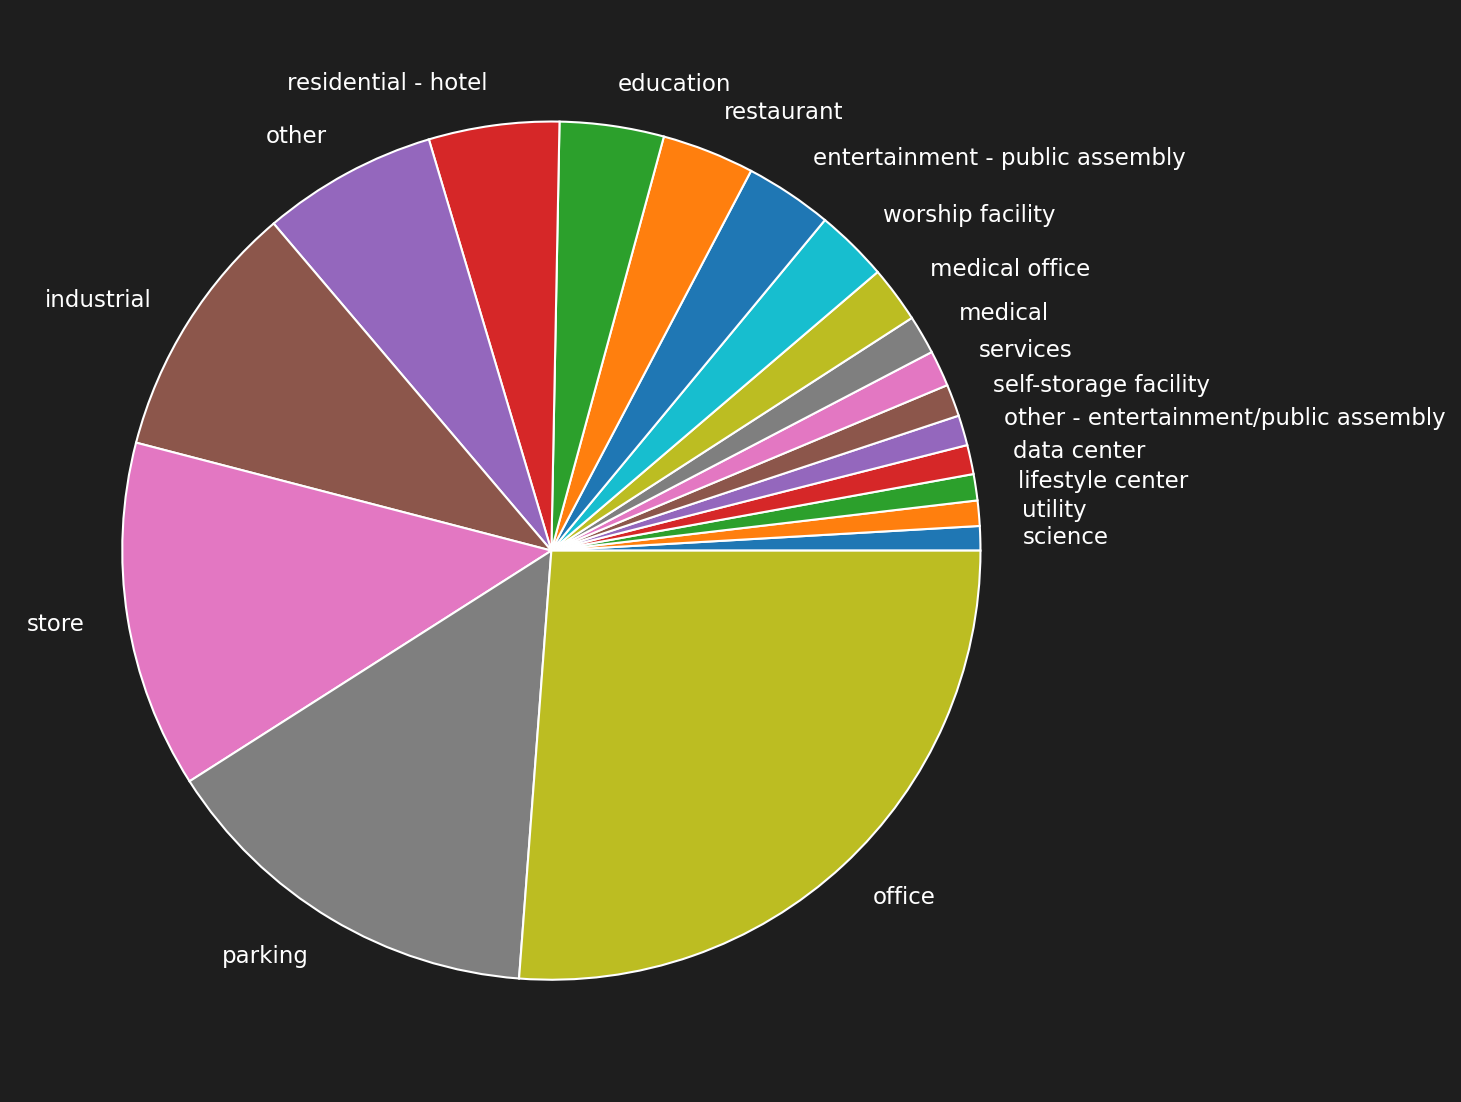

In [49]:
fig, ax = plt.subplots( figsize=(25*cm,25*cm) )
value_counts.plot( kind='pie', ax=ax )
fig.tight_layout()

savefig( fig, 'Figures/categories.pdf')

## 3.4. <a id='toc3_4_'></a>[Year-built -> categories ?](#toc0_)
à priori pas de relation directe évidente -> on peut séparer en plusieurs groupes

min: 1900 max: 2015
[1900 1920 1940 1960 1980 2000]


,YearBuilt,YearBuiltCateg
432,2000,7
159,2005,7
294,1971,5
550,1999,6
1862,1955,4
293,1980,6
1928,1992,6
242,2002,7
2379,1978,5
692,1979,5


,YearBuilt,YearBuiltCateg
0,1927,2
1,1996,6
2,1969,5
3,1926,2
4,1980,6
5,1999,6
6,1926,2
7,1926,2
8,1904,1
10,1969,5


breaks begin at: [1932 1942]
breaks end at: [1935 1944]


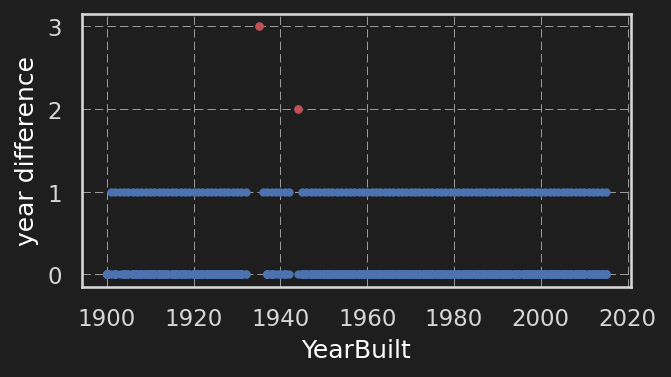

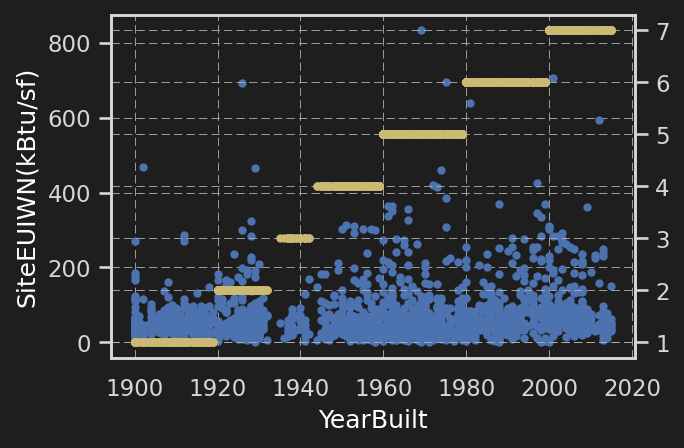

In [50]:
X, Y = 'YearBuilt', 'SiteEUIWN(kBtu/sf)'

print('min:', df[X].min(), 'max:', df[X].max() )
print( np.arange( 1900, 2020, 20 ) )

bins_yearbuilt = [1900, 1920, 1934, 1943, 1960, 1980, 2000, 2020]
df['YearBuiltCateg'] = np.digitize( df[X], bins_yearbuilt )
display( df[[X, 'YearBuiltCateg']].sample(10) )
display( df[[X, 'YearBuiltCateg']].head(10) )

x = df[X].values.copy()
x.sort()
diff_x = x[1:]-x[:-1]
b_break = diff_x > 1
print( 'breaks begin at:', x[:-1][ b_break ])
print( 'breaks end at:', x[1:][ b_break ])

fig, ax = plt.subplots( figsize=(12*cm,6*cm) )
ax.plot( x[1:], diff_x, 'bo', markersize=3 )
ax.plot( x[1:][ b_break ], diff_x[ b_break ], 'ro', markersize=3 )
ax.set_xlabel(X)
ax.set_ylabel( 'year difference' )

fig, ax = plt.subplots( figsize=(12*cm,8*cm) )
ax.plot( df[X], df[Y], 'bo', markersize=3 )
ax_twinx = ax.twinx()
ax_twinx.plot( df[X], df['YearBuiltCateg'], 'yo', markersize=3 )


ax.set_xlabel( X )
ax.set_ylabel( Y )
fig.tight_layout()

***
# 4. <a id='toc4_'></a>[Target](#toc0_)

## 4.1. <a id='toc4_1_'></a>[Vérifications et gestion des données](#toc0_)

Vérification de conversion kWh -> Btu : OK

estmated coefficient: 3.412, theoretical: 3.412142


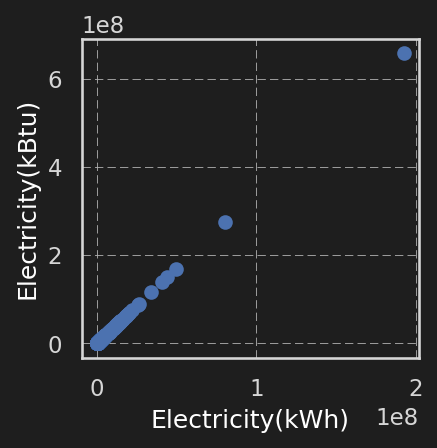

In [51]:
X, Y = 'Electricity(kWh)', 'Electricity(kBtu)'
coef = 3.412142 # in [Btu] / [Wh]

lr = linear_model.LinearRegression()
lr.fit( df[X].values.reshape(-1,1), df[Y] )
print( f'estmated coefficient: {lr.coef_[0]:.3f}, theoretical: {coef:}' )

fig, ax = plt.subplots( figsize=(8*cm,8*cm))
ax.plot( df[X], df[Y], 'bo' )
ax.set_xlabel(X)
ax.set_ylabel(Y)
fig.tight_layout()

vars_to_delete.append( X )

Vérification de conversion therms -> Btu : OK

estmated coefficient: 100.000, theoretical: 100.0


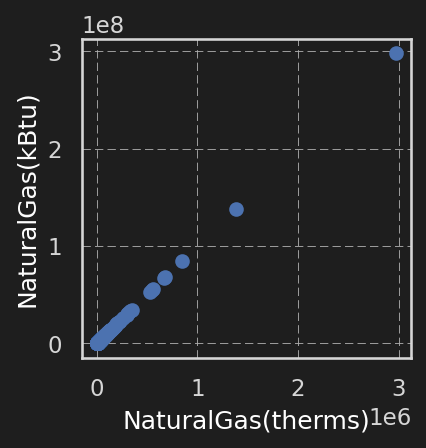

In [52]:
X, Y = 'NaturalGas(therms)', 'NaturalGas(kBtu)'
coef = 1e2 # in [kBtu]/[therms]

lr = linear_model.LinearRegression()
lr.fit( df[X].values.reshape(-1,1), df[Y] )
print( f'estmated coefficient: {lr.coef_[0]:.3f}, theoretical: {coef:}' )

fig, ax = plt.subplots( figsize=(8*cm,8*cm))
ax.plot( df[X], df[Y], 'bo' )
ax.set_xlabel(X)
ax.set_ylabel(Y)
fig.tight_layout()

vars_to_delete.append( X )

Pair plot des données énergie: les consommations sont principalement électrique, avec un partage avec du nas naturel, et relativement peu de vapeur. 

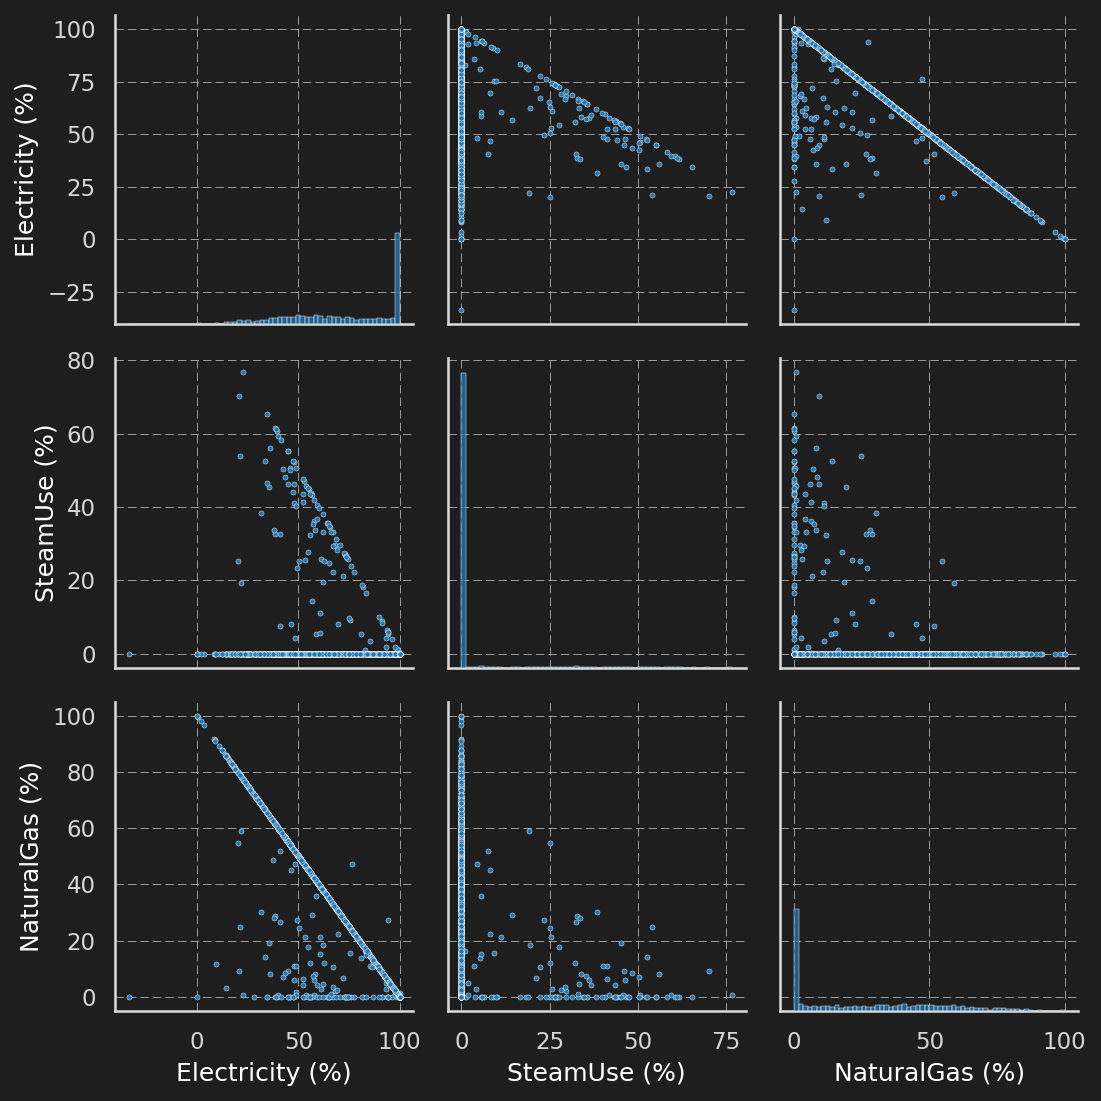

In [53]:
energies = ['Electricity(kBtu)', 'SteamUse(kBtu)', 'NaturalGas(kBtu)']
tmp = df[energies].copy()
for X in energies:
    tmp[X] = 100* tmp[X] / df['SiteEnergyUse(kBtu)']
    tmp.rename( columns={X:X[:-6] + ' (%)'}, inplace=True)

g = sns.pairplot( data=tmp, plot_kws={'s':6}, diag_kws={'bins':60} )
g.fig.tight_layout()

savefig( g, 'Figures/prop_energies.pdf')

Vérification de la somme des ressources utilisées.

`SiteEnergyUse(kBtu)`: The annual amount of energy consumed by the property from all sources of energy.

Certaines valeurs diffèrent mais la proportion semble assez faible.<br>Cette différence est possiblement due à des erreurs lors du calcul de la variable.

Les valeurs 'Electricity(kBtu)', 'SteamUse(kBtu)', 'NaturalGas(kBtu)' sont aussi mieux corrélées à la valeur 'SiteEnergyUse(kBtu)' qu'à la valeur WeatherNormalized.

,Electricity(kBtu),SteamUse(kBtu),NaturalGas(kBtu)
count,1.551000e+03,1.551000e+03,1.551000e+03
mean,6.145245e+06,5.501169e+05,2.028564e+06
std,2.151337e+07,5.713017e+06,9.701680e+06
min,-1.154170e+05,0.000000e+00,0.000000e+00
25%,7.217060e+05,0.000000e+00,0.000000e+00
50%,1.699980e+06,0.000000e+00,4.749870e+05
75%,5.258300e+06,0.000000e+00,1.528708e+06
max,6.570744e+08,1.349435e+08,2.979090e+08


X_values:


count    1.551000e+03
mean     8.723927e+06
std      2.901297e+07
min     -1.154170e+05
25%      1.233460e+06
50%      2.686765e+06
75%      7.269166e+06
max      7.420596e+08
dtype: float64

1 sumed values equals 0

Bulding with negative Electricity:


,OSEBuildingID,AgeOfBuilding(s),BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,YearBuiltCateg
3206,49784,3,nonresidential,small- and mid-sized office,bullitt center,1501 e. madison st.,seattle,wa,98122,7234600195,3,central,47.61432,-122.31257,2013,1,6,52000,0,52000,office,office,48159.0,NaN,NaN,NaN,NaN,NaN,100.0,7.1,5.0,2.0,-2.1,342726.0938,240132.0938,0.0,-33826.80078,-115417.0,0.0,0.0,False,compliant,0,-0.8,-0.02,7


DataFrame shape: (1551, 46)
27 values differs more than 1%
25 values differs more than 30%
3 values corresponds to sum energies > 1.1 * SiteEnergy

Estmated coefficient: 1.075, ideal: 1


,OSEBuildingID,AgeOfBuilding(s),BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,YearBuiltCateg
206,328,40,nonresidential,large office,1600 seventh,1600 7th ave,seattle,wa,98191,0659000165,7,downtown,47.61316,-122.33430,1976,1,33,791396,0,791396,"lifestyle center, office, other, parking, rest...",office,622034.0,parking,132465.0,other,33110.0,20172015,89.0,60.299999,62.400002,189.500000,195.899994,40847752.0,42227404.0,0.0,1.196941e+07,40839637.0,5382.505371,538251.0,False,compliant,0,313.30,0.40,5
563,757,37,nonresidential,large office,market place i & ii-2003 western avenue,2003 western avenue,seattle,wa,98121,1977200280,7,downtown,47.61051,-122.34439,1979,1,7,131143,87160,43983,"office, retail store",office,120248.0,store,10853.0,NaN,NaN,NaN,93.0,39.500000,NaN,128.000000,0.000000,5177270.5,NaN,0.0,1.427645e+06,4871126.0,14160.409180,1416041.0,False,compliant,0,109.16,0.83,5
2441,25661,107,nonresidential,small- and mid-sized office,buttnick city loan,206 1st avenue south,seattle,wa,98104,5247800380,7,downtown,47.60071,-122.33377,1909,1,3,47215,0,47215,"office, retail store",office,23659.0,store,22376.0,NaN,NaN,NaN,58.0,45.500000,46.400002,131.600006,135.100006,2092696.0,2136896.0,0.0,4.682223e+05,1597575.0,9918.134766,991813.0,False,compliant,0,63.81,1.35,1


,count,mean,std,min,25%,50%,75%,max
SiteEnergyUse(kBtu),1551.0,8.859374e+06,3.129079e+07,16808.90039,1238203.5,2717863.25,7298149.25,873923712.0
sum ressources,1551.0,8.723927e+06,2.901297e+07,-115417.00000,1233459.5,2686765.00,7269166.00,742059629.0


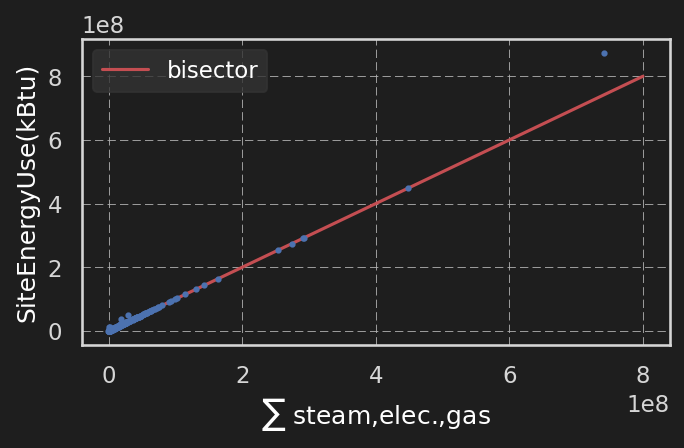

In [54]:
X, Y = energies, 'SiteEnergyUse(kBtu)'

display( df[X].describe() )

X_values = df[X].sum(1)

print('X_values:')
display(X_values.describe())

print('{:} sumed values equals 0'.format( (X_values==0).sum() ) )

diff = X_values - df[Y]
diff_ratio = diff / df[Y].abs() * 100


print('\nBulding with negative Electricity:')
display(df.loc[df['Electricity(kBtu)'] < 0 , :] )

print('DataFrame shape:', df.shape)
print('{:} values differs more than 1%'.format( (diff_ratio.abs() > 0.01).sum() ))

print('{:} values differs more than 30%'.format( (diff_ratio.abs() > 0.3).sum() ))
print('{:} values corresponds to sum energies > 1.1 * SiteEnergy'.format( (diff_ratio > 0.1).sum() ))

lr = linear_model.LinearRegression()
lr.fit( X_values.values.reshape(-1,1), df[Y].values )
print( f'\nEstmated coefficient: {lr.coef_[0]:.3f}, ideal: {1:}' )

display( df.loc[ diff_ratio > 0.1, :] )

display( pd.DataFrame( {Y:df[Y], 'sum ressources':X_values} ).describe().T )

fig, ax = plt.subplots( figsize=(12*cm,8*cm))
ax.plot( X_values, df[Y], 'bo', markersize=2 )
ax.plot( [0, 8e8], [0,8e8], 'r', label='bisector', zorder=1)
ax.legend()
ax.set_xlabel(r'$\sum$ steam,elec.,gas')
ax.set_ylabel(Y)

fig.tight_layout()
savefig( fig, 'Figures/verif_energies.pdf')

Le siteEnergyUse est recalculé puisque des erreurs sont visibles

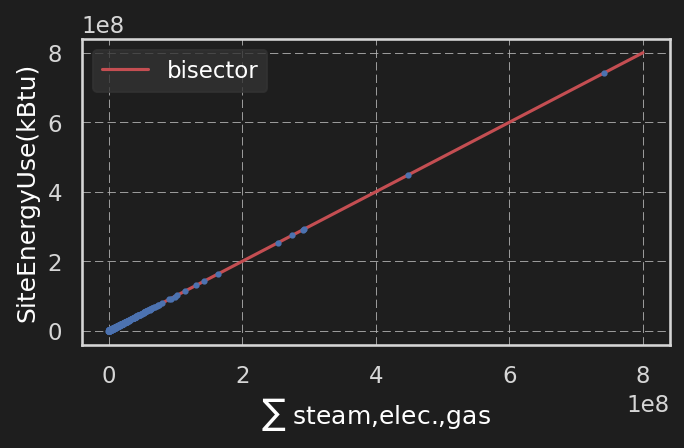

In [55]:
# pour le X_values == 0 -> considérons une ressource purement électrique puisque plus probable en regardant le pairplot plus haut)
loc = X_values == 0
df.loc[loc,'Electricity(kBtu)'] = df.loc[loc, Y]

df[Y] = df[energies].sum(1)

X_values = df[energies].sum(1)
fig, ax = plt.subplots( figsize=(12*cm,8*cm))
ax.plot( X_values, df[Y], 'bo', markersize=2 )
ax.plot( [0, 8e8], [0,8e8], 'r', label='bisector', zorder=1)
ax.legend()
ax.set_xlabel(r'$\sum$ steam,elec.,gas')
ax.set_ylabel(Y)

fig.tight_layout()

SiteEnergyUse(WN) 

estmated coefficient: 1.023


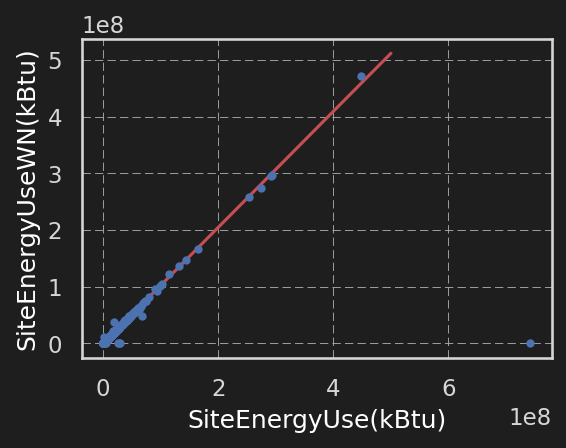

In [56]:
X, Y = 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)'

x,y = df[[X,Y]].dropna().values.T

loc = y != 0.

lr_WN = linear_model.LinearRegression()
lr_WN.fit( x[loc].reshape(-1,1), y[loc] )
print( f'estmated coefficient: {lr_WN.coef_[0]:.3f}' )

fig, ax = plt.subplots( figsize=(10*cm,8*cm))
ax.plot( x, y, 'bo', markersize=3, zorder=2 )
ax.plot( [0,5e8], [0,lr_WN.coef_[0]*5e8], 'r', zorder=1 )
ax.set_xlabel(X)
ax.set_ylabel(Y)
fig.tight_layout()

savefig( fig, 'Figures/verif_nrgUseWN.pdf')


Certaines valeurs sont à 0. ou semblent ne pas correspondre -> recalcul de la somme des énergies et application du coefficient de la régression linéaire

nombre de 0 | NaN: 10


,OSEBuildingID,AgeOfBuilding(s),BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,YearBuiltCateg
220,343,58,nonresidential,large office,norton building,801 2nd ave suite 1300,seattle,wa,98104,0939000355,7,downtown,47.60370,-122.33447,1958,1,17,378525,84600,293925,"office, parking",office,236827.0,parking,83311.0,restaurant,14679.0,NaN,69.0,105.199997,0.0,240.899994,0.0,2.490613e+07,0.0,10921066.00,4.098788e+06,13985064.0,0.000000,0.0,False,compliant,0,940.47,2.48,4
247,372,28,nonresidential,large office,metropolitan park east,1730 minor avenue,seattle,wa,98101,0660002410,7,downtown,47.61695,-122.32965,1988,1,20,497513,118744,378769,"office, parking",office,367623.0,parking,114510.0,NaN,NaN,2015201320122010,65.0,73.000000,0.0,227.899994,0.0,2.682322e+07,0.0,0.00,7.796691e+06,26602310.0,2209.050049,220905.0,False,compliant,0,197.19,0.40,6
284,414,87,nonresidential,large office,onni 1411 fourth development lp,1411 4th ave,seattle,wa,98101,1975700345,7,downtown,47.60923,-122.33625,1929,1,15,151039,0,151039,office,office,125473.0,NaN,NaN,NaN,NaN,NaN,84.0,43.400002,0.0,92.300003,0.0,5.446624e+06,0.0,2850077.75,7.610041e+05,2596546.0,0.000000,0.0,False,compliant,0,238.09,1.58,2
350,493,45,nonresidential,small- and mid-sized office,200 first ave w,200 1st ave w,seattle,wa,98119,1989201020,7,magnolia / queen anne,47.62014,-122.35768,1971,1,5,88000,21600,66400,"office, parking",office,69691.0,parking,17487.0,NaN,NaN,NaN,75.0,50.000000,0.0,157.000000,0.0,3.484915e+06,0.0,0.00,1.021370e+06,3484915.0,0.000000,0.0,False,compliant,0,24.29,0.28,5
563,757,37,nonresidential,large office,market place i & ii-2003 western avenue,2003 western avenue,seattle,wa,98121,1977200280,7,downtown,47.61051,-122.34439,1979,1,7,131143,87160,43983,"office, retail store",office,120248.0,store,10853.0,NaN,NaN,NaN,93.0,39.500000,NaN,128.000000,0.0,6.287167e+06,NaN,0.00,1.427645e+06,4871126.0,14160.409180,1416041.0,False,compliant,0,109.16,0.83,5
882,20130,106,nonresidential,worship facility,green lake united methodist church,6415 1st ave ne,seattle,wa,98115,1257200735,6,northwest,47.67572,-122.32850,1910,1,2,23931,0,23931,worship facility,worship facility,23931.0,NaN,NaN,NaN,NaN,NaN,88.0,20.700001,0.0,36.400002,0.0,4.964770e+05,0.0,0.00,4.896690e+04,167075.0,3294.021729,329402.0,False,compliant,0,18.66,0.78,1
953,20324,16,nonresidential,worship facility,temple beth am,2632 ne 80th st.,seattle,wa,98115,1513800009,4,northeast,47.68752,-122.29852,2000,1,2,31386,0,31386,worship facility,worship facility,30000.0,NaN,NaN,NaN,NaN,NaN,52.0,37.599998,0.0,89.000000,0.0,1.128179e+06,0.0,0.00,2.082293e+05,710478.0,4177.007813,417701.0,False,compliant,0,27.14,0.86,7
3274,49967,116,campus,university,university of washington - seattle campus,ne 45th st & brooklyn ave,seattle,wa,98105,1625049001,4,northeast,47.65644,-122.31041,1900,111,1,9320156,0,9320156,college/university,education,9320156.0,NaN,NaN,NaN,NaN,NaN,NaN,93.800003,0.0,246.600006,0.0,7.420596e+08,0.0,84985240.00,1.925775e+08,657074389.0,0.000000,0.0,False,compliant,0,11140.56,1.20,1
3275,49968,47,nonresidential,university,aerospace,3795 e stevens way ne,seattle,wa,98195,1625049001,4,northeast,47.65395,-122.30584,1969,1,4,58779,0,58779,college/university,education,58779.0,NaN,NaN,NaN,NaN,NaN,NaN,85.099998,0.0

nombre de 0 | NaN: 0


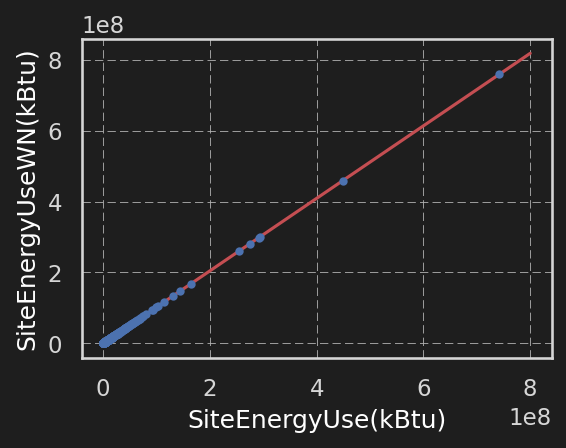

In [57]:
sr_loc = (df[Y] == 0.) | (df[Y].isna())
print('nombre de 0 | NaN:', sr_loc.sum())
display( df.loc[sr_loc,:] )

df[Y] = lr_WN.predict( df[X].values.reshape(-1,1) ).ravel()

sr_loc = (df[Y] == 0.) | (df[Y].isna())
print('nombre de 0 | NaN:', sr_loc.sum())

fig, ax = plt.subplots( figsize=(10*cm,8*cm))
ax.plot( df[X], df[Y], 'bo', markersize=3, zorder=2 )
ax.plot( [0,8e8], [0,lr_WN.coef_[0]*8e8], 'r', zorder=1 )
ax.set_xlabel(X)
ax.set_ylabel(Y)
fig.tight_layout()


Données par unité de surface
- `SiteEUI(kBtu/sf)` est basée sur les factures
- `SourceEUI(kbtu/sf)` : "the annual energy used to operate the property, including losses from generation, transmission, & distribution."

estmated coefficient: 2.377


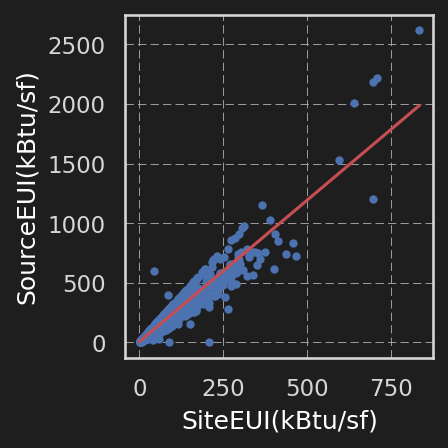

In [58]:
X, Y = 'SiteEUI(kBtu/sf)', 'SourceEUI(kBtu/sf)'

lr = linear_model.LinearRegression()
lr.fit( df[X].values.reshape(-1,1), df[Y] )
print( f'estmated coefficient: {lr.coef_[0]:.3f}' )

fig, ax = plt.subplots( figsize=(8*cm,8*cm))
ax.plot( df[X], df[Y], 'bo', markersize=3 )

x = np.array([0, df[X].max()]).reshape(2,1)
ax.plot( x, lr.predict(x), 'r' )
ax.set_xlabel(X)
ax.set_ylabel(Y)
fig.tight_layout()

On regarde à quoi correspondent les surfaces

Il y a clairement des incohérences entre les `LargestPropertyUseTypeGFA` et (`PropertyGFATotal`, `PropertyGFABuilding(s)`, `PropertyGFAParking`, `NumberofFloors`)

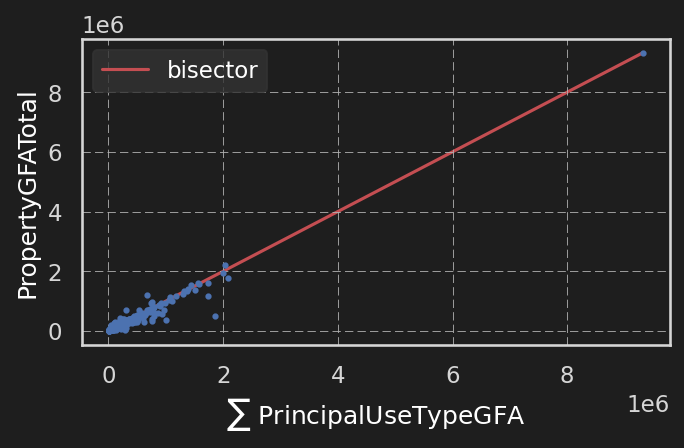

In [59]:
x = df[['LargestPropertyUseTypeGFA',
        'SecondLargestPropertyUseTypeGFA',
        'ThirdLargestPropertyUseTypeGFA']].fillna(0.).sum(1)


Y = 'PropertyGFATotal'
y = df[Y]


fig, ax = plt.subplots( figsize=(12*cm,8*cm))
ax.plot( x, y, 'bo', markersize=2 )
ax.plot( [0, y.max()], [0, y.max()], 'r', zorder=0, label='bisector' )
ax.legend()
ax.set_xlabel(r'$\sum$ PrincipalUseTypeGFA')
ax.set_ylabel(Y)

fig.tight_layout()
savefig( fig, 'Figures/verif_GFA.pdf')

On regarde la cohérence entre le SiteEnergyUseWN(kBtu/sf) et le SiteEUIWN(kBtu/sf):
- la surface utilisée pour calculer le SiteEUIWN semble être plus proche de la somme des GFA use type
- comme on souhaite modéliser la consommation et les émissiones `totales`, les variables surfaciques seront recalculée à partir du GFABuilding(s)

['OSEBuildingID', 'AgeOfBuilding(s)', 'BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'DefaultData', 'ComplianceStatus', 'Outlier', 'TotalGHGEmissions', 'GHGEmissionsIntensity', 'YearBuiltCateg']


,count,mean,std,min,25%,50%,75%,max
SiteEUIWN(kBtu/sf),1550.0,77.415032,76.782471,0.000000,36.599998,56.099998,87.775002,834.400024
re-calculated,1551.0,73.031203,77.358819,-1.183965,33.507273,50.336329,80.733176,927.417754


,count,mean,std,min,25%,50%,75%,max
SiteEUI(kBtu/sf),1551.0,74.990135,75.762906,0.700000,34.599998,53.599998,84.899998,834.400024
re-calculated,1551.0,70.123935,75.601914,-2.219558,31.326288,47.941308,77.671230,906.130898


,count,mean,std,min,25%,50%,75%,max
SiteEUIWN(kBtu/sf),1550.0,77.415032,76.782471,0.000000,36.599998,56.099998,87.775002,834.400024
re-calculated,1551.0,73.025009,72.748779,-1.278394,33.465001,52.449430,82.421173,855.469764


,count,mean,std,min,25%,50%,75%,max
SiteEUI(kBtu/sf),1551.0,74.990135,75.762906,0.700000,34.599998,53.599998,84.899998,834.400024
re-calculated,1551.0,70.094036,71.086867,-2.396582,31.414085,49.814006,79.576949,834.402417


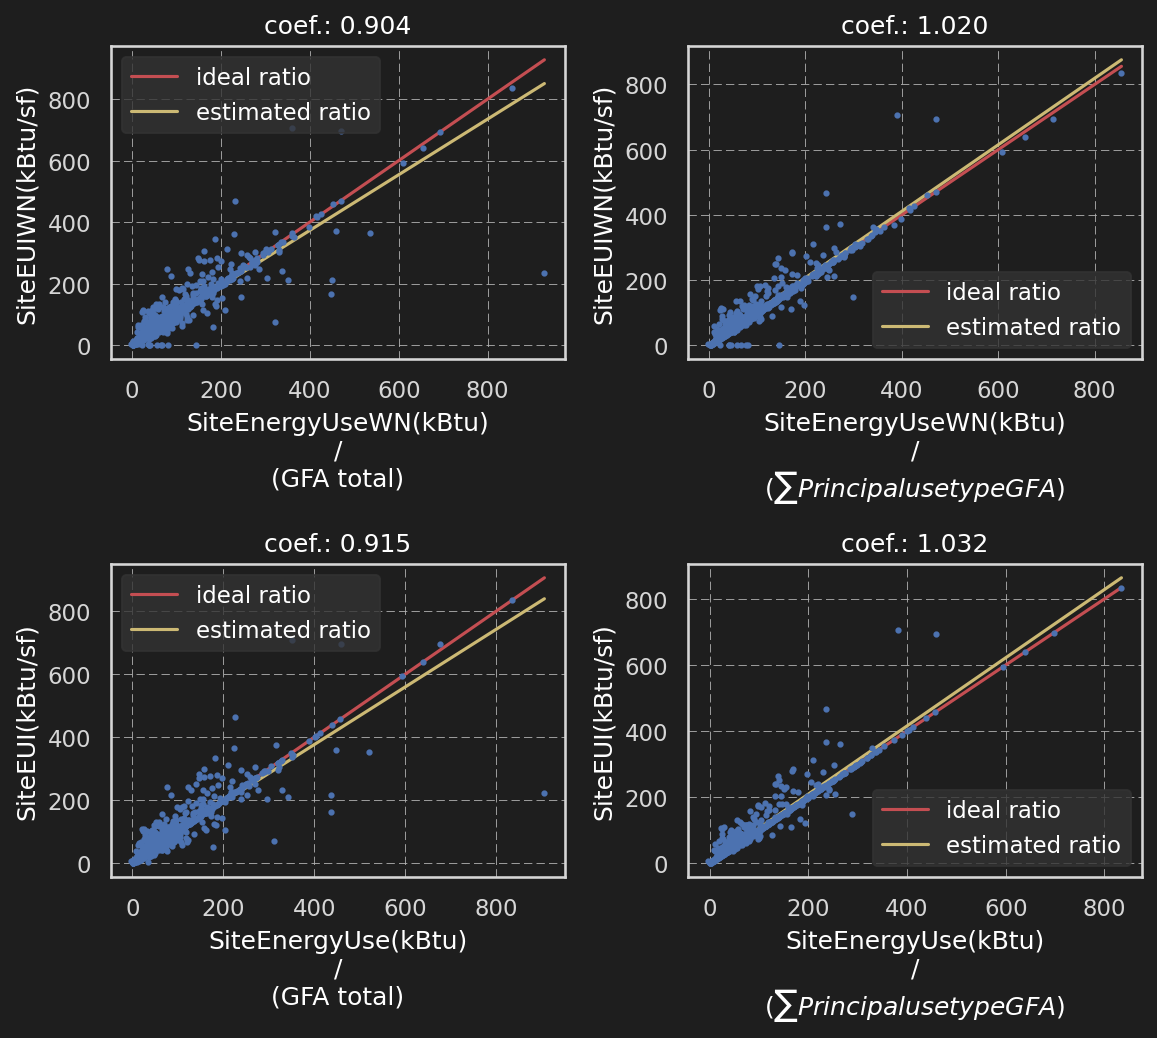

In [60]:
print( df.keys().tolist())
fig, axs = plt.subplots( ncols=2,nrows=2, figsize=(20*cm,18*cm))

for i, (srfc, srfc_label) in enumerate( zip( [y,x], ['GFA total', r'$\sum Principal use type GFA$'] ) ):
    for j, (X,Y) in enumerate([ ('SiteEnergyUseWN(kBtu)', 'SiteEUIWN(kBtu/sf)'), ('SiteEnergyUse(kBtu)', 'SiteEUI(kBtu/sf)')]) :
        ax = axs[j][i]
        # X_values = df[X] / y
        X_values = df[X] / srfc
        diff = X_values - df[Y]

        sr_drop = (X_values.isna()) | ( df[Y].isna())

        lr = linear_model.LinearRegression()
        lr.fit( X_values.loc[~sr_drop].values.reshape(-1,1), df.loc[~sr_drop, Y] )
        # print( f'\nEstmated coefficient: {lr.coef_[0]:.3f}, ideal: {1:}' )

        display( pd.DataFrame( {Y:df[Y], 're-calculated':X_values} ).describe().T )

        ymax = df[Y].max()
        xmax = X_values.max()
        ax.set_title( f'coef.: {lr.coef_[0]:.3f}' )
        ax.plot( [0,xmax], [0,xmax], 'r', label='ideal ratio' )
        ax.plot( [0,xmax], lr.predict( np.array([0,xmax]).reshape(-1,1) ), 'y', label='estimated ratio' )
        ax.plot( X_values, df[Y], 'bo', markersize=2 )
        ax.set_xlabel( X + f'\n/\n({srfc_label})')
        ax.set_ylabel(Y)
        ax.legend()

        # ax_twinx = ax.twinx()
        # ax_twinx.plot( X_values, np.abs(diff) / X_values * 100, 'ro', markersize=4 )
        # ax_twinx.set_ylabel('difference (%)', color='r')

fig.tight_layout()
savefig( fig, 'Figures/verif_SiteEUI.pdf')

In [61]:
vars_to_delete += df.columns[df.columns.str.contains('/sf|Intensity')].tolist()

,OSEBuildingID,AgeOfBuilding(s),BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,YearBuiltCateg
1279,21435,55,nonresidential,other,space needle,400 broard street,seattle,wa,98109,1985200495,7,magnolia / queen anne,47.62049,-122.34930,1961,1,2,33971,0,33971,other - recreation,entertainment - public assembly,50000.0,NaN,NaN,NaN,NaN,NaN,NaN,353.700012,363.299988,747.700012,757.900024,17686444.0,1.815625e+07,0.0,2.638551e+06,9002735.0,8.683709e+04,8683709.0,False,compliant,0,523.95,15.42,5
3171,49709,4,nonresidential,other,"seattle procure management, llc.",1570 north 115th street,seattle,wa,98013,3026049128,5,northwest,47.71286,-122.33635,2012,1,2,53575,0,53575,urgent care/clinic/other outpatient,medical,53575.0,NaN,NaN,NaN,NaN,NaN,NaN,593.599976,593.599976,1527.300049,1527.300049,31803566.0,3.260323e+07,0.0,6.791758e+06,23173477.0,8.630089e+04,8630089.0,False,compliant,0,619.90,11.57,7
558,753,35,nonresidential,other,westinbuilding,2001 6th ave,seattle,wa,98121,0659000950,7,downtown,47.61438,-122.33871,1981,1,33,429405,0,429405,"data center, office",data center,218997.0,office,210409.0,NaN,NaN,NaN,98.0,639.700012,639.799988,2007.900024,2008.000000,274682167.0,2.811569e+08,0.0,8.046087e+07,274532495.0,1.496720e+03,149672.0,False,compliant,0,1921.82,4.48,6
809,19900,90,nonresidential,laboratory,3000/3018 western,3018 western ave.,seattle,wa,98121,0695000090,7,downtown,47.61763,-122.35507,1926,1,4,49249,0,49249,"laboratory, office",science,40584.0,office,7165.0,NaN,NaN,NaN,NaN,696.700012,693.099976,1206.699951,1195.099976,33268410.0,3.410230e+07,0.0,3.181345e+06,10854749.0,2.241366e+05,22413661.0,False,compliant,0,1266.06,25.71,2
309,440,15,nonresidential,mixed use property,fisher plaza - west building,100 4th ave n,seattle,wa,98109,1991200170,7,lake union,47.61915,-122.34857,2001,1,6,213834,104922,108912,"data center, financial office, office, other, ...",parking,104922.0,data center,54385.0,office,37721.0,NaN,100.0,707.299988,707.299988,2217.800049,2217.800049,75073877.0,7.688459e+07,0.0,2.195702e+07,74917352.0,1.565250e+03,156525.0,False,compliant,0,530.59,2.48,7
3203,49780,41,nonresidential,other,2020 fifth avenue dat center,2020 fifth avenue,seattle,wa,98121,0659000905,7,downtown,47.61449,-122.33956,1975,1,7,90679,35120,55559,"data center, parking",data center,60000.0,parking,30700.0,NaN,NaN,NaN,100.0,694.700012,694.700012,2181.300049,2181.300049,41680634.0,4.271109e+07,0.0,1.221590e+07,41680634.0,0.000000e+00,0.0,False,compliant,0,290.57,3.20,5
2380,25452,28,nonresidential,mixed use property,chandler's cove - sedo,901 fairview ave. n.,seattle,wa,98109,4088803045,3,lake union,47.62774,-122.33384,1988,1,2,34639,15402,19237,"other, parking, restaurant",restaurant,23373.0,other,19659.0,parking,15402.0,NaN,NaN,359.700012,370.899994,700.299988,712.099976,15480680.0,1.589895e+07,0.0,1.946760e+06,6642344.0,8.838336e+04,8838336.0,False,compliant,0,515.71,14.89,6
240,365,47,nonresidential,other,uw tower data center,4333 brooklyn ave ne,seattle,wa,98185,1142000290,4,northeast,47.66060,-122.31512,1969,1,5,36000,0,36000,data center,data center,36000.0,NaN,NaN,NaN,NaN,2016201520142013,96.0,834.400024,834.400024,2620.000000,2620.000000,30038487.0,3.079691e+07,0.0,8.803777e+06,30038487.0,0.000000e+00,0.0,False,compliant,0,209.41,5

Text(0.5, 0, 'SiteEnergyUseWN / GFA Buildind(s) (kBtu/sf)')

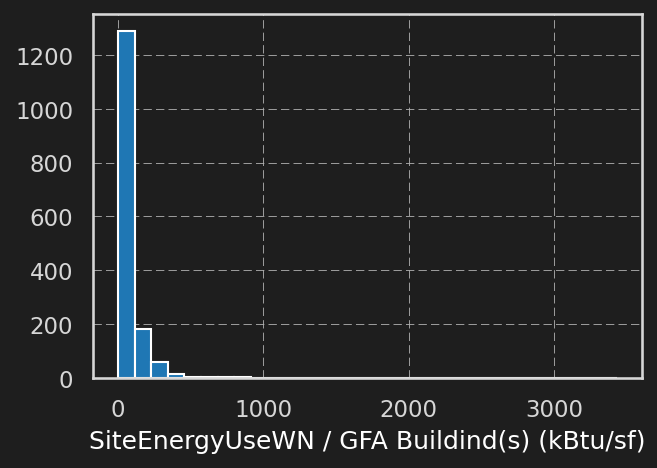

In [62]:
x,y = df[['PropertyGFABuilding(s)', 'SiteEnergyUseWN(kBtu)']].values.T

values = y / x

# affichage des valeurs élevée
display( df.iloc[ values.argsort()[-10:] , : ] )


fig, ax = plt.subplots( figsize=(12*cm,8*cm) )
ax.hist( y/x, bins=30 )
ax.set_xlabel( 'SiteEnergyUseWN / GFA Buildind(s) (kBtu/sf)')

Le TotalGHGEmissions est calculé en utilisant :
> - Light's 2015 emissions factor of 52.44 lbs CO2e/MWh until the 2016 factor is available.
> - Enwave steam factor = 170.17 lbs CO2e/MMBtu.
> - Gas factor sourced from EPA Portfolio Manager = 53.11 kg CO2e/MBtu.

La variables `TotalGHGEmissions` est exprimée en `metric tons of carbon dioxide equivalent`.

Estimer cette variable revient à estimer l'`énergie consommée` connaissant les `proportions d'énergies utilisée`.

estimated coefficient: 1.000e+00


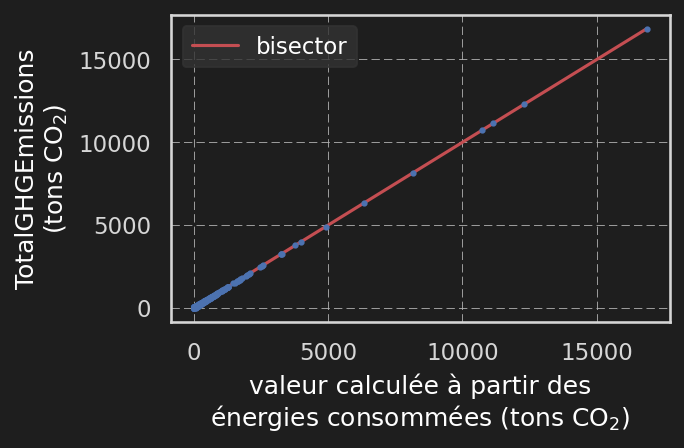

In [63]:
y = df['TotalGHGEmissions']

def energies_to_emissions( elec_kBtu, steam_kBtu, gas_kBtu):
    return 1e-3 *( # conversion kg->tons
            0.4535924*( # conversion lbs-> kg
                (52.44e-3/3.412142) * elec_kBtu # conversion kBtu->kWh->lbs
                + 170.17e-3 * steam_kBtu) # conversion kBtu->lbs
                + 53.11e-3 * gas_kBtu ) # coonversion kBtu->kg

# x =  0.4535924*(52.44e-3 * df['Electricity(kWh)'] + 170.17e-3 * df['SteamUse(kBtu)']) + 53.11e-3 * df['NaturalGas(kBtu)']
# x = x*0.001 # conversion en tonne

# x = df[energies].values.T*1e-3

x = energies_to_emissions( *(df[energies].values.T) )
lr = linear_model.LinearRegression()
lr.fit( x.reshape(-1,1), y )


vmax = max( x.max(), y.max() )
fig, ax = plt.subplots( figsize=(12*cm,8*cm) )
ax.plot( [0, vmax], [0, vmax], 'r', label='bisector')
ax.plot( x, y, 'bo', markersize=2 )
ax.set_xlabel( 'valeur calculée à partir des\nénergies consommées (tons CO$_2$)')
ax.set_ylabel( 'TotalGHGEmissions\n(tons CO$_2$)')
ax.legend()
fig.tight_layout()
savefig( fig, 'Figures/verif_emissions.pdf')

print('estimated coefficient: {:.3e}'.format( lr.coef_[0]))

Avec la valeur `WeatherNormalized` pour le  `SiteEnergyUse` calculer la valeur `WeatherNormalized` pour le `TotalGHGEmissions` sera plus coherent (voir section Features des modèles).

In [64]:
targets = ['SiteEnergyUseWN(kBtu)', 'TotalGHGEmissions']

In [65]:
df[targets].info()

for target in targets:
    sr_0 = (df[target] == 0) | (df[target].isna())
    print( f'\nnumber of elements {target} == 0 | isna:', (sr_0).sum())
# display( df.loc[sr_0,:])

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1551 entries, 0 to 3375
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SiteEnergyUseWN(kBtu)  1551 non-null   float64
 1   TotalGHGEmissions      1551 non-null   float64
dtypes: float64(2)
memory usage: 68.6 KB

number of elements SiteEnergyUseWN(kBtu) == 0 | isna: 0

number of elements TotalGHGEmissions == 0 | isna: 1


Des emissions sont à 0, ce qui n'est pas cohérent

In [66]:
df.loc[sr_0,:]

,OSEBuildingID,AgeOfBuilding(s),BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,YearBuiltCateg
513,700,8,nonresidential,supermarket / grocery store,iuc- whole foods interbay,2001 15th avenue west,seattle,wa,98119,7666201460,7,magnolia / queen anne,47.63718,-122.37734,2008,1,1,57176,0,57176,"personal services (health/beauty, dry cleaning...",store,39500.0,store,15000.0,services,5500.0,NaN,31.0,208.800003,214.100006,0.0,0.0,12525174.0,1.287438e+07,0.0,0.0,12525174.0,0.0,0.0,False,compliant,0,0.0,0.0,7


Calcul de la valeur manquante.

In [67]:
df.loc[sr_0,'TotalGHGEmissions'] = energies_to_emissions( *( df.loc[sr_0, energies].values.T ))

df.loc[sr_0,:]

,OSEBuildingID,AgeOfBuilding(s),BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,YearBuiltCateg
513,700,8,nonresidential,supermarket / grocery store,iuc- whole foods interbay,2001 15th avenue west,seattle,wa,98119,7666201460,7,magnolia / queen anne,47.63718,-122.37734,2008,1,1,57176,0,57176,"personal services (health/beauty, dry cleaning...",store,39500.0,store,15000.0,services,5500.0,NaN,31.0,208.800003,214.100006,0.0,0.0,12525174.0,1.287438e+07,0.0,0.0,12525174.0,0.0,0.0,False,compliant,0,87.314249,0.0,7


count    1.551000e+03
mean     8.992581e+06
std      2.969018e+07
min     -6.156616e+04
25%      1.323683e+06
50%      2.808046e+06
75%      7.508688e+06
max      7.594551e+08
Name: SiteEnergyUseWN(kBtu), dtype: float64

count     1551.000000
mean       193.096702
std        778.407004
min         -0.800000
25%         20.110000
50%         49.730000
75%        147.315000
max      16870.980000
Name: TotalGHGEmissions, dtype: float64

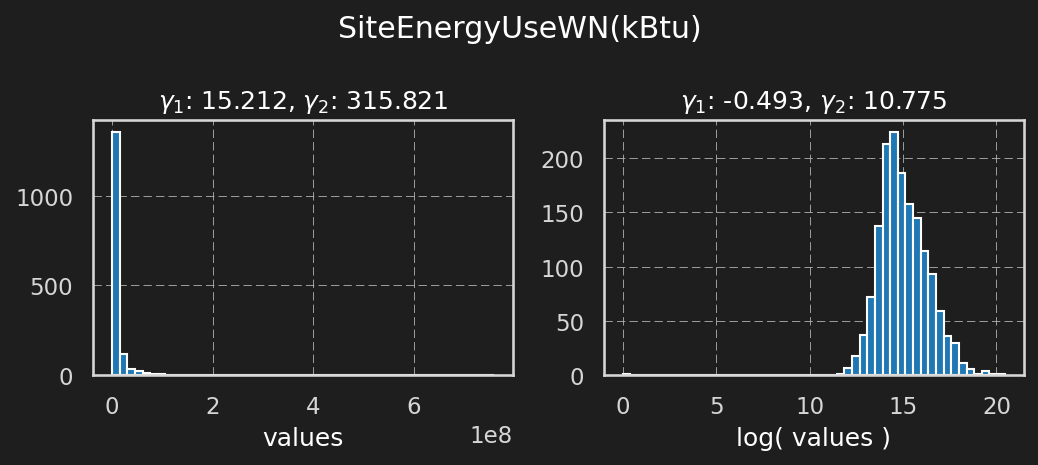

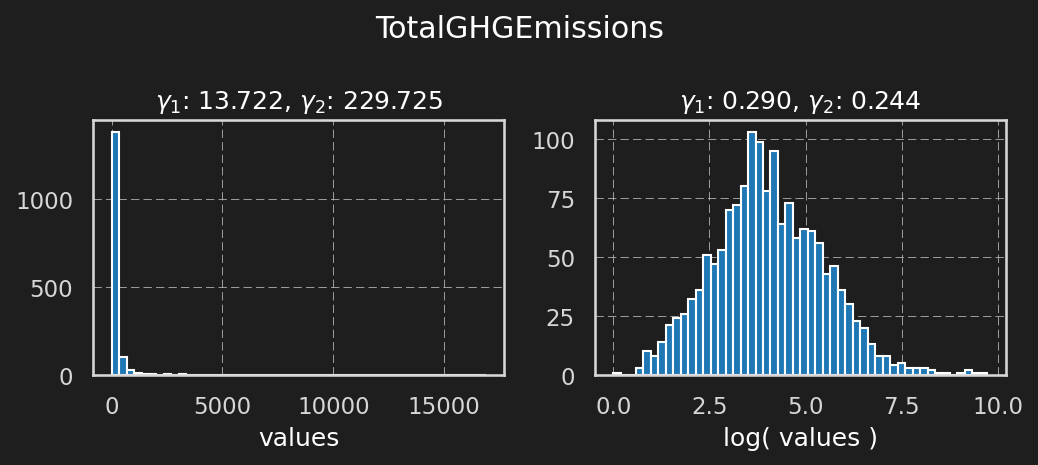

In [68]:
# power_inv_targets = [6, 6]
# for target, power_inv in zip( targets, power_inv_targets ):
for target in targets:
    y = df[target].dropna()

    display( y.describe() )

    # y_pow = (y+1.-y.min())**(1/power_inv)

    # print( ( y + (1-y.min()) ).min() )
    y_log = np.log( y + (1-y.min() ) )


    fig, axs = plt.subplots( ncols=2, figsize=(18*cm,8*cm) )
    n, bins, _ = axs[0].hist( y, bins=50 )
    n, bins, _ = axs[1].hist( y_log, bins=50 )
    # n, bins, _ = axs[2].hist( y_pow, bins=50 )
    axs[0].set_xlabel( 'values' )
    axs[1].set_xlabel( f'log( values )' )
    # axs[2].set_xlabel( f'values ** (1/{power_inv})' )

    axs[0].set_title( r'$\gamma_1$: {:.3f}, $\gamma_2$: {:.3f}'.format( st.skew(y), st.kurtosis(y) ) )
    axs[1].set_title( r'$\gamma_1$: {:.3f}, $\gamma_2$: {:.3f}'.format( st.skew(y_log), st.kurtosis(y_log) ) )
    # axs[2].set_title( r'$\gamma_1$: {:.3f}, $\gamma_2$: {:.3f}'.format( st.skew(y_pow), st.kurtosis(y_pow) ) )

    fig.suptitle( target )
    fig.tight_layout()
    savefig( fig, f'Figures/histo_{target}_log.pdf')

    log_target_bins_center = (bins[:-1] + bins[1:]) * 0.5 



Il est probablement plus intéressant d'estimer le SiteEnergyUse(kBtu) divisé par le PropertyGFABuilding(s).<br>
Le feature engineering est à adapté en conséquence.

count    1551.000000
mean       82.155833
std       120.377646
min        -1.183965
25%        36.700921
50%        55.396589
75%        89.131084
max      3434.854960
dtype: float64

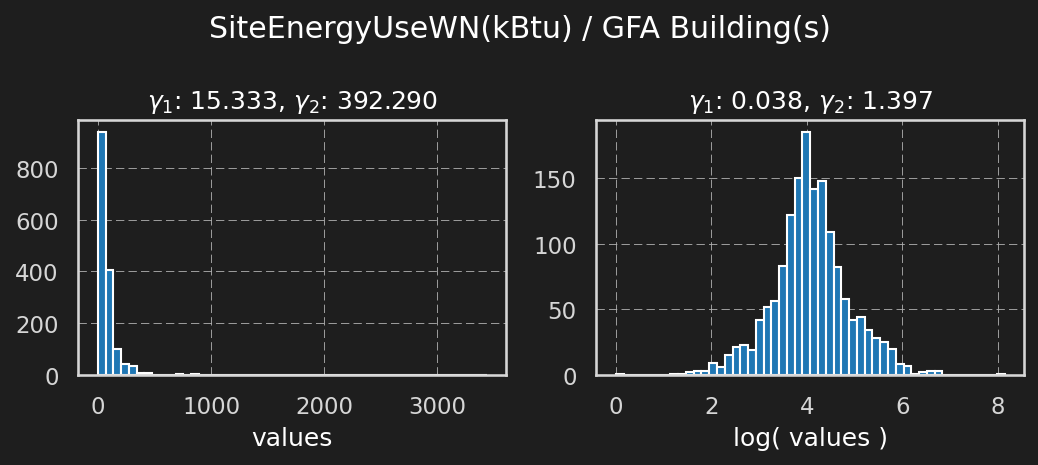

In [69]:
y = df[targets[0]] / df['PropertyGFABuilding(s)']
y_label = targets[0] + ' / GFA Building(s)'

display( y.describe() )

y_log = np.log( y + (1-y.min() ) )


fig, axs = plt.subplots( ncols=2, figsize=(18*cm,8*cm) )
n, bins, _ = axs[0].hist( y, bins=50 )
n, bins, _ = axs[1].hist( y_log, bins=50 )
# n, bins, _ = axs[2].hist( y_pow, bins=50 )
axs[0].set_xlabel( 'values' )
axs[1].set_xlabel( f'log( values )' )
# axs[2].set_xlabel( f'values ** (1/{power_inv})' )

axs[0].set_title( r'$\gamma_1$: {:.3f}, $\gamma_2$: {:.3f}'.format( st.skew(y), st.kurtosis(y) ) )
axs[1].set_title( r'$\gamma_1$: {:.3f}, $\gamma_2$: {:.3f}'.format( st.skew(y_log), st.kurtosis(y_log) ) )
# axs[2].set_title( r'$\gamma_1$: {:.3f}, $\gamma_2$: {:.3f}'.format( st.skew(y_pow), st.kurtosis(y_pow) ) )

fig.suptitle( y_label )
fig.tight_layout()

savefig( fig, f'Figures/histo_Nrg_GFA_Buildings_log.pdf')


log_target_bins_center = (bins[:-1] + bins[1:]) * 0.5 

## 4.2. <a id='toc4_2_'></a>[Scatter plots](#toc0_)

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/03_energy/.venv/lib64/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


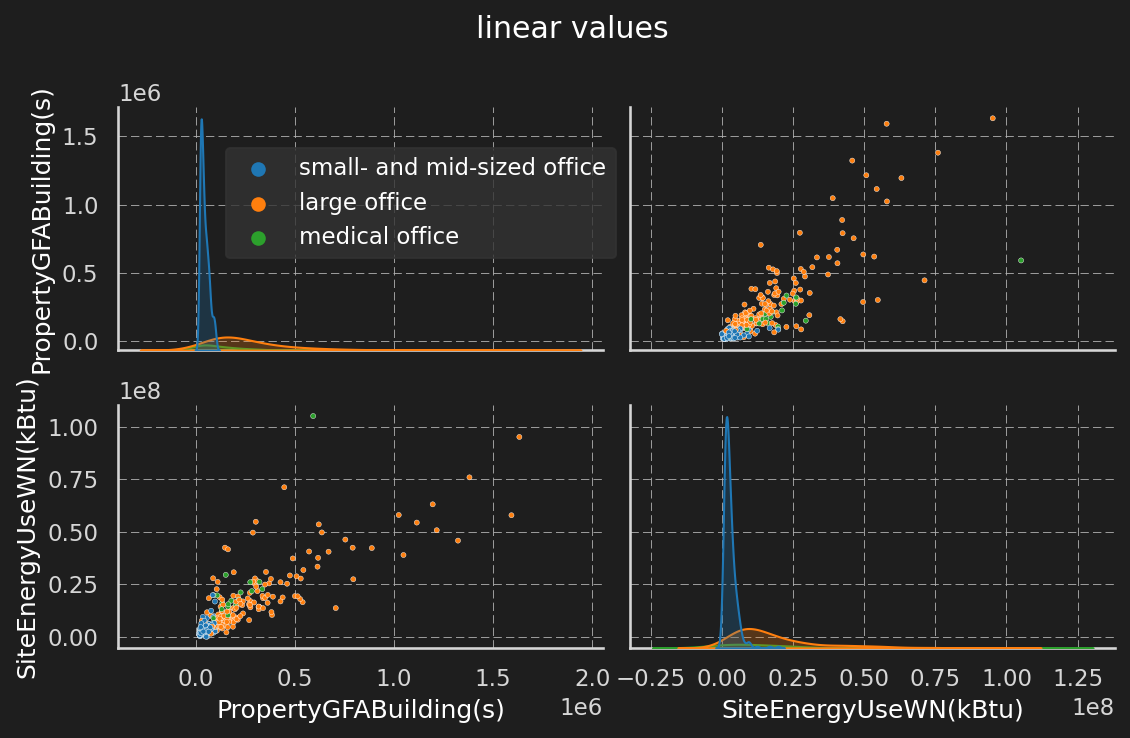

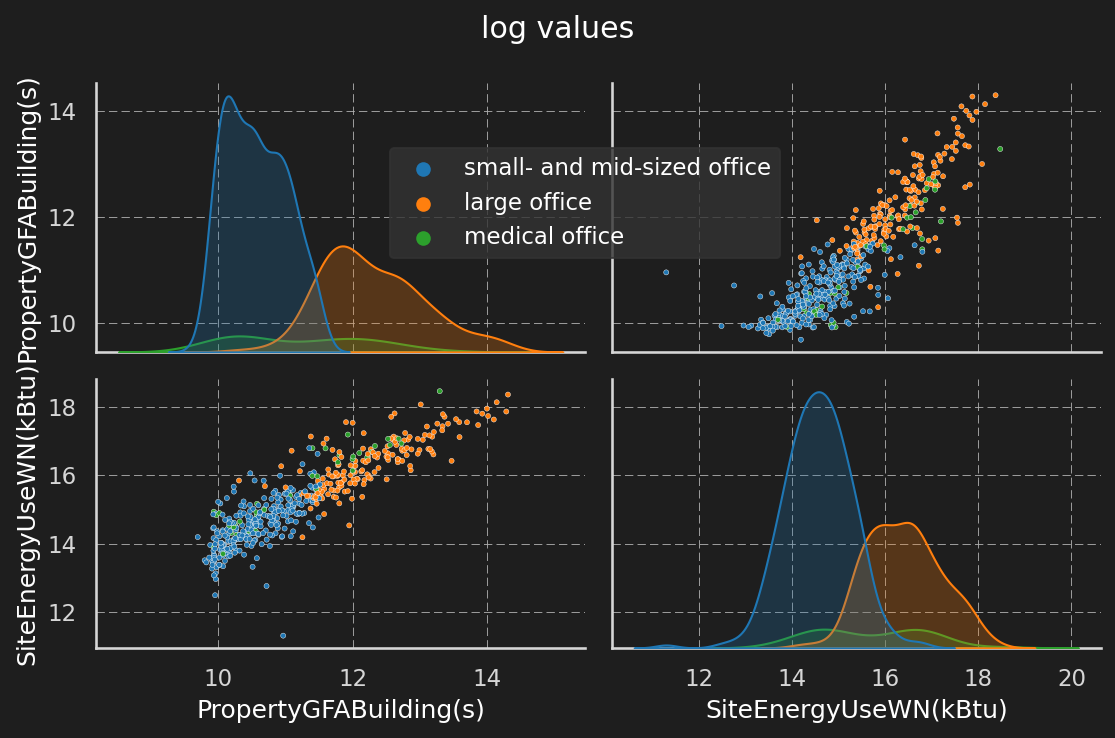

In [70]:

Xs = ['PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA']
hues = ['PrimaryPropertyType', 'LargestPropertyUseType']

# df[target]

Y = targets[0]

sr_loc = (df[Y] != 0)
for X in Xs:
    sr_loc = sr_loc & (df[X]!=0)
tmp = df.loc[sr_loc, Xs + hues + [Y, 'Outlier']]
# tmp = df[[X,target, 'Outlier', hue]]

if True:
    # tmp[ Xs[1] ] /= tmp[ Xs[0] ]
    # sr_loc = tmp[Xs[1]] > 0.7
    sr_loc = tmp[hues[0]].str.contains('office')
    tmp = tmp.loc[sr_loc,:]


for X,hue in zip( Xs, hues ):
    g = sns.pairplot( data=tmp, vars=[X,Y], hue=hue,
        plot_kws={'s':6} )
    
    handles = g._legend_data.values()
    labels = g._legend_data.keys()
    g.fig.legend(handles=handles, labels=labels, loc=[0.2,0.65], ncol=1)
    g.legend.remove()
    g.fig.suptitle('linear values')
    g.fig.tight_layout()
    

    tmp[X] = np.log( tmp[X] )
    tmp[Y] = np.log( tmp[Y] )
    g = sns.pairplot( data=tmp, vars=[X,Y], hue=hue,
        plot_kws={'s':6} )
    # g.legend(bbox_to_anchor= (1.03, 1) )
    handles = g._legend_data.values()
    labels = g._legend_data.keys()
    g.fig.legend(handles=handles, labels=labels, loc=[0.35,0.65], ncol=1)
    g.legend.remove()
    g.fig.suptitle('log values')
    g.fig.tight_layout()
    
    break

Le PropertyGFABuilding(s) est fortement corrélé au SiteEnergyUseWN(kBtu) pour les offices.
Les groupes sont différents puisque les GFA sont différents.

In [71]:
def ANOVA( df, hue, Y, transform=None ):
    groups = df[[Y,hue]].dropna().groupby(hue)[Y]
    index = pd.MultiIndex.from_tuples( [('shape','skew'), ('shape','kurtosis'),('shapiro','statistic'), ('shapiro','p-value')] )
    df_shape = pd.DataFrame( index = index)
    names = [name for name,yi in groups]
    for name, yi in groups:
        if not transform is None:
            yi = transform( yi )
        # print('\nname:', name)
        # print( st.skew(yi) )
        # print( st.kurtosis(yi) )
        # print( st.shapiro(yi) )
        # sr = pd.Series( [  ] ).astype(float)
        shapiro = st.shapiro(yi)
        df_shape[name] = [st.skew(yi), st.kurtosis(yi), shapiro.statistic, shapiro.pvalue]
    
    print(f'ANOVA on variable {Y}')
    print('p-value is the probability to have found a particular set of observations if the null hypothesis were true (valid if p-value is high)')
    print('Shapiro null hypothesis: data has a normal distribution')
    display(df_shape.round(3))

    levene = pg.homoscedasticity( df.dropna(), dv=Y, group=hue )
    print( 'small p-value suggests that the populations do not have equal variances' )
    display( levene )

    # tpl = tuple( [df.query( f'{hue} == "{name}"')[Y].dropna() for name in names ] )
    # print( st.levene( *tpl ) )
    

    print('small p-value suggests that there is a statistically significant difference between the means of groups')
    display( pg.pairwise_tukey( dv=Y, between=hue, data=df.dropna() ) )

    # for i, (name,yi) in enumerate(groups):
    #     print('\n\n| {:} |\n\n'.format( '-'*20 ))
    #     if i+1 == len(names):
    #         break
    #     print(f'name: {name}')
    #     for j, (name_2,yi2) in enumerate(groups):
    #         if j <= i:
    #             continue
    #         print( f'\n{name} - {name_2}:' )
    #         stat, p = st.levene(yi, yi2)
    #         print( f'levene stat: {stat:.3f}, p-value: {p:.3f}' )
    #         print('std: {:.3f} - {:.3f}'.format( yi.std(), yi2.std() ) )

mask = 'SiteEnergyUseWN / GFA Building(s)(kBtu/sf)'
tmp[mask] = df[targets[0]] / df['PropertyGFABuilding(s)']
print('LINEAR VALUES')
ANOVA( tmp, 'PrimaryPropertyType', mask )
print('LOG VALUES')
ANOVA( tmp, 'PrimaryPropertyType', mask, lambda y:np.log( y + (1-y.min())) )

LINEAR VALUES
ANOVA on variable SiteEnergyUseWN / GFA Building(s)(kBtu/sf)
p-value is the probability to have found a particular set of observations if the null hypothesis were true (valid if p-value is high)
Shapiro null hypothesis: data has a normal distribution


large office  medical office  small- and mid-sized office
shape   skew              2.812           1.467                        2.418
        kurtosis          8.486           1.653                        7.996
shapiro statistic         0.663           0.843                        0.784
        p-value           0.000           0.000                        0.000

small p-value suggests that the populations do not have equal variances


,W,pval,equal_var
levene,1.005945,0.366444,True


small p-value suggests that there is a statistically significant difference between the means of groups


...

large office  medical office  small- and mid-sized office
shape   skew             -0.570          -1.754                       -1.553
        kurtosis          5.610           5.825                       11.989
shapiro statistic         0.911           0.857                        0.878
        p-value           0.000           0.000                        0.000

small p-value suggests that the populations do not have equal variances


,W,pval,equal_var
levene,1.005945,0.366444,True


small p-value suggests that there is a statistically significant difference between the means of groups


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,large office,medical office,70.841652,93.657990,-22.816338,7.468942,-3.054829,0.006697,-0.464876
1,large office,small- and mid-sized office,70.841652,62.247641,8.594011,4.058194,2.117693,0.087291,0.203605
2,medical office,small- and mid-sized office,93.657990,62.247641,31.410349,7.185545,4.371324,0.000045,0.845808


Les "large office" et "small- and mid-sized office" semblent correspondrent à une consommation par unité de surface similaires, mais les "medial offices" semble être différents.

><span style="color:orange"> Note: </span>
> - Les p-value des test shapiro indiquent bien que les valeurs ne sont pas de distribution normale
> - le test de levene indiquent que les variances sont suffisamment semblables

***
# 5. <a id='toc5_'></a>[Features des modèles](#toc0_)

## 5.1. <a id='toc5_1_'></a>[Suppression des variables non utilisées](#toc0_)

In [72]:
print('Columns to delete:', vars_to_delete)

Columns to delete: ['OSEBuildingID', 'PropertyName', 'TaxParcelIdentificationNumber', 'Address', 'ListOfAllPropertyUseTypes', 'DataYear', 'City', 'State', 'YearBuilt', 'ZipCode', 'Electricity(kWh)', 'NaturalGas(therms)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'GHGEmissionsIntensity']


In [73]:
df_annexe = df[['PropertyName']].copy() # DataFrame des variables à garder sous le coude
df.drop( columns= [col for i, col in enumerate(vars_to_delete) if (col in df.columns) and (not col in vars_to_delete[:i])], inplace=True )
vars_to_delete = []
print('DataFrame.shape', df.shape)
df.columns

DataFrame.shape (1551, 30)


Index(['AgeOfBuilding(s)', 'BuildingType', 'PrimaryPropertyType',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)',
       'NaturalGas(kBtu)', 'DefaultData', 'ComplianceStatus', 'Outlier',
       'TotalGHGEmissions', 'YearBuiltCateg'],
      dtype='object')

Les variables 'BuildingType', 'PrimaryPropertyType' ne seront pas utilisées, car redondant par rapport aux `LargestPropertyUseTypes` 

In [74]:
df.drop( columns=['BuildingType', 'PrimaryPropertyType'] , inplace=True )
print('DataFrame.shape', df.shape)
df.columns

DataFrame.shape (1551, 28)


Index(['AgeOfBuilding(s)', 'CouncilDistrictCode', 'Neighborhood', 'Latitude',
       'Longitude', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)',
       'NaturalGas(kBtu)', 'DefaultData', 'ComplianceStatus', 'Outlier',
       'TotalGHGEmissions', 'YearBuiltCateg'],
      dtype='object')

In [75]:
print('DataFrame shape:', df.shape )


mask = ['YearsENERGYSTARCertified', 'Outlier',
    'YearBuiltCateg', 'DefaultData', 'ComplianceStatus']
df_annexe[mask] = df[mask].copy()
df.drop( columns=mask, inplace=True )

print('DataFrame shape:', df.shape )
print('DataFrame annexe shape:', df_annexe.shape )

df.columns

DataFrame shape: (1551, 28)
DataFrame shape: (1551, 23)
DataFrame annexe shape: (1551, 6)


Index(['AgeOfBuilding(s)', 'CouncilDistrictCode', 'Neighborhood', 'Latitude',
       'Longitude', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'ENERGYSTARScore', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)',
       'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)',
       'TotalGHGEmissions'],
      dtype='object')

## 5.2. <a id='toc5_2_'></a>[Corrélation des variables](#toc0_)
Une (force) corrélation est à noter entre les variables:
- PropertyTotalGFA, PropertyGFABuilding(s) LargestPropertyUseTypeGFA et SecondLargestPropertyUseTypeGFA 
- TotalGHGEmissionIntensity et SiteEUIWN(kBtu/sf)
- Electricity(kBtu) et les variables GFA

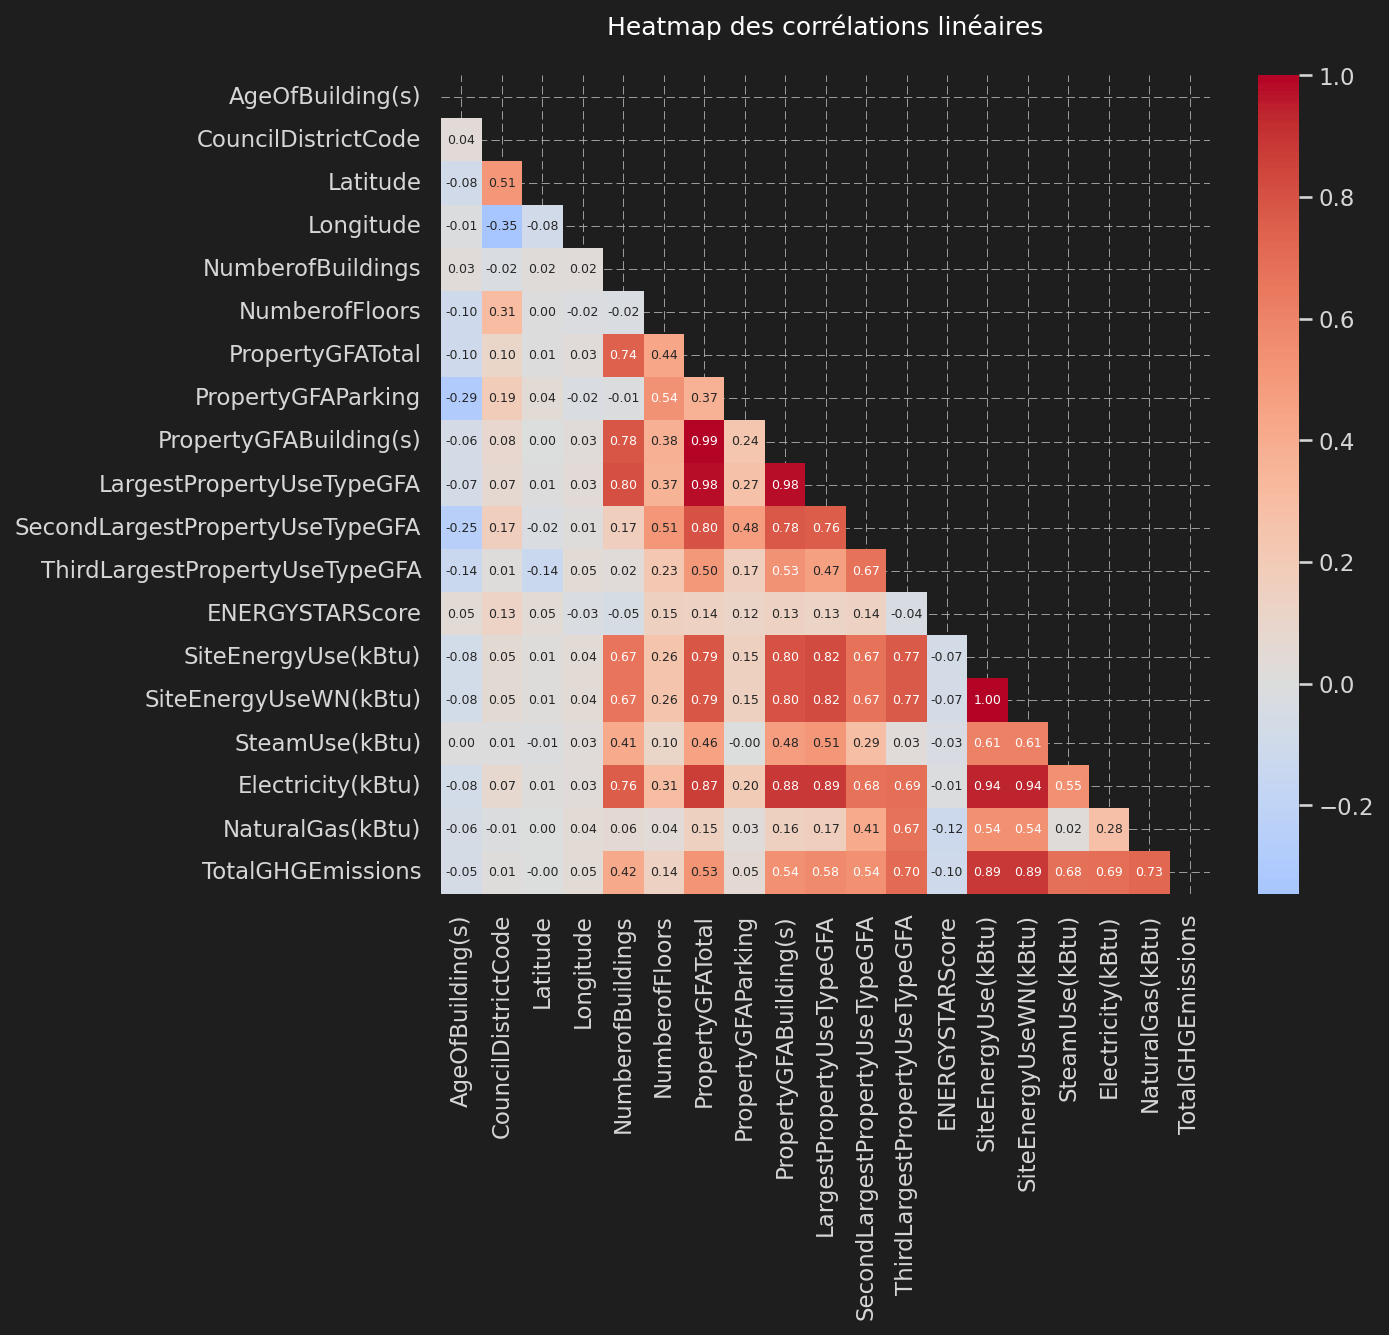

In [76]:
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
fig, ax = plt.subplots(figsize=(21*cm,18*cm))
ax = sns.heatmap(corr, annot=True, fmt=".2f", annot_kws={'size':6}, 
                 mask=mask, center=0, cmap="coolwarm")
plt.title(f"Heatmap des corrélations linéaires\n")
plt.show()
fig.tight_layout()
savefig( fig, 'Figures/correl_init.pdf')

Vérification de **multicolinéarité avec le VIF** *(Variance Inflation Factor)* : $VIF = \dfrac{1}{1-R^2}$

On sélectionne les variables qui ne sont pas des variables cibles

In [77]:
variables = corr.columns.values[ ~corr.columns.str.contains( 'SiteEnergy|Emissi') ]
variables

array(['AgeOfBuilding(s)', 'CouncilDistrictCode', 'Latitude', 'Longitude',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore',
       'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)'],
      dtype=object)

In [78]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


tmp = df[variables].dropna()

tmp_vif = pd.DataFrame()
tmp_vif["feature"] = tmp.columns
tmp_vif["VIF"] = [variance_inflation_factor(tmp.values, i) 
                   for i in range(len(tmp.columns))]

# print( df2ltx( tmp_vif[tmp_vif['VIF'] > 5].round(2) ) )

display(tmp_vif[tmp_vif['VIF'] > 5])

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/03_energy/.venv/lib64/python3.10/site-packages/statsmodels/stats/outliers_influence.py:195: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


,feature,VIF
4,NumberofBuildings,1.141189e+08
6,PropertyGFATotal,inf
7,PropertyGFAParking,inf
8,PropertyGFABuilding(s),inf
9,LargestPropertyUseTypeGFA,3.036231e+01
10,SecondLargestPropertyUseTypeGFA,5.896614e+00
11,ThirdLargestPropertyUseTypeGFA,6.302195e+00
14,Electricity(kBtu),5.922956e+00
15,NaturalGas(kBtu),5.526634e+00


Des scores VIF supérieur à 5 indiquent généralement une forte multicolinéarité. Les variables fortement corrélées peuvent dégrader les résultats des modèles.

La variable ENERGYSTARScore est mise de côté, puisque dans l'idéale, il est préférable de s'en affranchir.

In [79]:
mask = ['ENERGYSTARScore']
df_annexe[mask] = df[mask].copy()
df.drop( columns=mask, inplace=True )

## 5.3. <a id='toc5_3_'></a>[PCA](#toc0_)

In [80]:
tmp = df.select_dtypes(include=[np.number])
features = [col for col in tmp.columns if not col in vars_to_delete]
print(features)

['AgeOfBuilding(s)', 'CouncilDistrictCode', 'Latitude', 'Longitude', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'TotalGHGEmissions']


In [81]:
X = df[features].dropna()
scaler_pca = preprocessing.StandardScaler()
X_scaled = scaler_pca.fit_transform(X) # fit and transform
idx = ["mean", "std"]
display( pd.DataFrame(X_scaled).describe().round(2).loc[idx, :] )

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
mean,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [82]:
from sklearn.decomposition import PCA
n_components = X_scaled.shape[1]
pca = PCA(n_components=n_components)

# entrainement
pca.fit(X_scaled)

PCA(n_components=18)

scree: [42.04 16.64  9.28  6.55  5.18  5.17  4.09  3.13  2.39  2.15  1.36  1.23
  0.65  0.14  0.    0.    0.    0.  ]
sum scree: 100.0


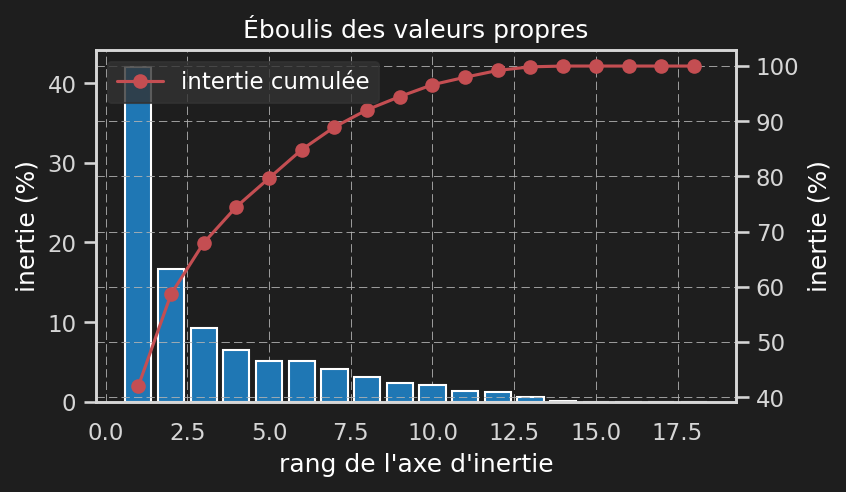

In [83]:
x_list = range(1, n_components+1)
scree = (pca.explained_variance_ratio_*100)
print('scree:', scree.round(2))
print('sum scree:', scree.sum().round(2))
fig, ax = plt.subplots( figsize=(14*cm,8*cm))
ax.bar( x_list, scree )
ax.set_xlabel("rang de l'axe d'inertie")
ax.set_ylabel("inertie (%)")
ax.set_title('Éboulis des valeurs propres')
ax.yaxis.grid( visible=False )

ax = ax.twinx()
ax.set_ylabel("inertie (%)")

ax.plot( x_list, scree.cumsum(), c='r', marker='o', label='intertie cumulée')
ax.legend()

fig.tight_layout(pad=0.2)
savefig( fig, 'Figures/PCA_eboulis.pdf')

On observe les premiers axes d'inertie

,Electricity(kBtu),SecondLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),SiteEnergyUse(kBtu),LargestPropertyUseTypeGFA,PropertyGFATotal,PropertyGFABuilding(s),ThirdLargestPropertyUseTypeGFA,TotalGHGEmissions,NaturalGas(kBtu),NumberofFloors,PropertyGFAParking,CouncilDistrictCode,SteamUse(kBtu),NumberofBuildings,Longitude,Latitude,AgeOfBuilding(s)
F1,0.33662,0.323873,0.321369,0.321369,0.309653,0.299227,0.294686,0.280251,0.256902,0.228193,0.224739,0.179386,0.064701,0.059677,0.016501,0.015358,-0.04306,-0.116481


,NaturalGas(kBtu),TotalGHGEmissions,SiteEnergyUseWN(kBtu),SiteEnergyUse(kBtu),ThirdLargestPropertyUseTypeGFA,AgeOfBuilding(s),Longitude,NumberofBuildings,Electricity(kBtu),SteamUse(kBtu),SecondLargestPropertyUseTypeGFA,Latitude,CouncilDistrictCode,LargestPropertyUseTypeGFA,PropertyGFABuilding(s),PropertyGFAParking,PropertyGFATotal,NumberofFloors
F2,0.414943,0.378678,0.250734,0.250734,0.190823,0.102673,0.089937,0.058922,0.02121,-0.049154,-0.056357,-0.130285,-0.236222,-0.252046,-0.263446,-0.290179,-0.298227,-0.339533


,Longitude,NumberofBuildings,PropertyGFABuilding(s),PropertyGFATotal,LargestPropertyUseTypeGFA,NumberofFloors,SecondLargestPropertyUseTypeGFA,Electricity(kBtu),PropertyGFAParking,ThirdLargestPropertyUseTypeGFA,AgeOfBuilding(s),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),NaturalGas(kBtu),TotalGHGEmissions,Latitude,CouncilDistrictCode
F3,0.505131,0.31828,0.121109,0.107143,0.102648,0.053093,0.01457,0.009279,0.006828,-0.017589,-0.040751,-0.077469,-0.077469,-0.085121,-0.133115,-0.133133,-0.498256,-0.5466


,SteamUse(kBtu),AgeOfBuilding(s),NumberofFloors,CouncilDistrictCode,PropertyGFABuilding(s),NumberofBuildings,LargestPropertyUseTypeGFA,TotalGHGEmissions,Electricity(kBtu),PropertyGFATotal,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),ThirdLargestPropertyUseTypeGFA,NaturalGas(kBtu),SecondLargestPropertyUseTypeGFA,Longitude,PropertyGFAParking,Latitude
F4,0.607261,0.592326,0.198994,0.130493,0.08599,0.066309,0.059418,0.027321,0.014537,0.008616,0.008198,0.008198,-0.015903,-0.060168,-0.087847,-0.122003,-0.280191,-0.319824


,NumberofBuildings,SteamUse(kBtu),Latitude,CouncilDistrictCode,Longitude,PropertyGFAParking,Electricity(kBtu),TotalGHGEmissions,SiteEnergyUseWN(kBtu),SiteEnergyUse(kBtu),NaturalGas(kBtu),SecondLargestPropertyUseTypeGFA,NumberofFloors,LargestPropertyUseTypeGFA,PropertyGFATotal,PropertyGFABuilding(s),ThirdLargestPropertyUseTypeGFA,AgeOfBuilding(s)
F5,0.693955,0.471299,0.25691,0.147999,0.112364,0.108637,0.051297,0.049412,0.043279,0.043279,-0.02107,-0.031765,-0.072263,-0.073856,-0.083387,-0.125206,-0.146927,-0.344679


,NumberofBuildings,AgeOfBuilding(s),CouncilDistrictCode,ThirdLargestPropertyUseTypeGFA,PropertyGFABuilding(s),Electricity(kBtu),PropertyGFATotal,SecondLargestPropertyUseTypeGFA,LargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),NaturalGas(kBtu),NumberofFloors,Latitude,PropertyGFAParking,TotalGHGEmissions,Longitude,SteamUse(kBtu)
F6,0.614618,0.268396,0.12501,0.086281,0.085169,0.083395,0.053452,0.033232,0.020174,-0.003352,-0.003352,-0.032499,-0.064015,-0.081889,-0.087713,-0.089915,-0.459377,-0.519491


,Longitude,Latitude,AgeOfBuilding(s),CouncilDistrictCode,NumberofBuildings,NumberofFloors,ThirdLargestPropertyUseTypeGFA,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,NaturalGas(kBtu),PropertyGFATotal,SecondLargestPropertyUseTypeGFA,TotalGHGEmissions,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),Electricity(kBtu),PropertyGFAParking,SteamUse(kBtu)
F7,0.601865,0.5427,0.503975,0.136131,0.104803,0.079131,0.064356,0.05884,0.054196,0.045372,0.037079,0.017808,0.012866,-0.005393,-0.005393,-0.038516,-0.059958,-0.184047


,PropertyGFABuilding(s),ThirdLargestPropertyUseTypeGFA,Latitude,PropertyGFATotal,SecondLargestPropertyUseTypeGFA,SteamUse(kBtu),LargestPropertyUseTypeGFA,Electricity(kBtu),Longitude,NumberofBuildings,CouncilDistrictCode,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),TotalGHGEmissions,NaturalGas(kBtu),NumberofFloors,AgeOfBuilding(s),PropertyGFAParking
F8,0.322662,0.268548,0.211979,0.100514,0.083701,0.07964,0.048451,0.035237,-0.00928,-0.023152,-0.049739,-0.064692,-0.064692,-0.12564,-0.152074,-0.161445,-0.304627,-0.763253


,AgeOfBuilding(s),CouncilDistrictCode,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions
F1,-0.12,0.06,-0.04,0.02,0.02,0.22,0.30,0.18,0.29,0.31,0.32,0.28,0.32,0.32,0.06,0.34,0.23,0.26
F2,0.10,-0.24,-0.13,0.09,0.06,-0.34,-0.30,-0.29,-0.26,-0.25,-0.06,0.19,0.25,0.25,-0.05,0.02,0.41,0.38
F3,-0.04,-0.55,-0.50,0.51,0.32,0.05,0.11,0.01,0.12,0.10,0.01,-0.02,-0.08,-0.08,-0.09,0.01,-0.13,-0.13
F4,0.59,0.13,-0.32,-0.12,0.07,0.20,0.01,-0.28,0.09,0.06,-0.09,-0.02,0.01,0.01,0.61,0.01,-0.06,0.03
F5,-0.34,0.15,0.26,0.11,0.69,-0.07,-0.08,0.11,-0.13,-0.07,-0.03,-0.15,0.04,0.04,0.47,0.05,-0.02,0.05
F6,0.27,0.13,-0.08,-0.46,0.61,-0.06,0.05,-0.09,0.09,0.02,0.03,0.09,-0.00,-0.00,-0.52,0.08,-0.03,-0.09
F7,0.50,0.14,0.54,0.60,0.10,0.08,0.04,-0.06,0.06,0.05,0.02,0.06,-0.01,-0.01,-0.18,-0.04,0.05,0.01
F8,-0.30,-0.05,0.21,-0.01,-0.02,-0.16,0.10,-0.76,0.32,0.05,0.08,0.27,-0.06,-0.06,0.08,0.04,-0.15,-0.13


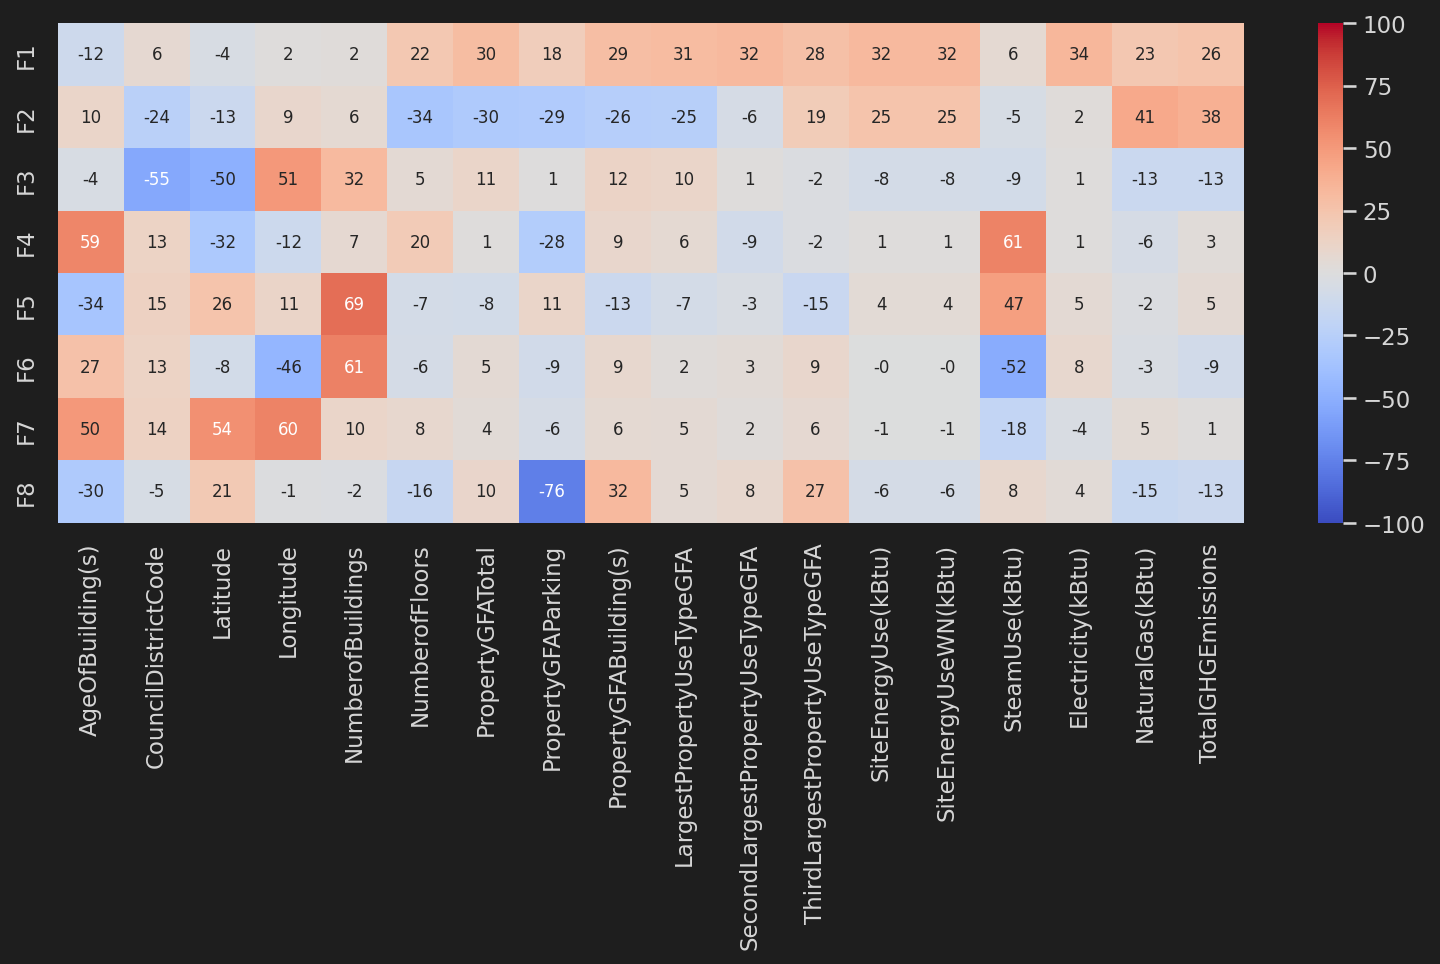

In [86]:
pcs = pd.DataFrame( pca.components_.transpose() )
pcs.index = features
columns = [f"F{i}" for i in x_list]
pcs.columns = columns

for i in range(8):
    key = f'F{i+1:}'
    display( pcs[[key]].sort_values( key, ascending=False ).T )

display( pcs.iloc[:,:8].round(2).T ) #.sort_values(by=indexes , ascending=False) )
fig, ax = plt.subplots(figsize=(26*cm, 16*cm))
sns.heatmap(pcs.iloc[:,:8].T*100, vmin=-100, vmax=100, annot=True, cmap="coolwarm", fmt="0.0f", annot_kws={"size": 8})
fig.tight_layout( pad=0.2 )
savefig( fig, 'Figures/PCA_heatmap.pdf' )

## 5.4. <a id='toc5_4_'></a>[Calcul de ratios](#toc0_)

On s'intrésse à des variables rapportée à la surface totale d'un site, donc on ramène les GFA à des ratios, avec comme référence les GFABuilding(s)

In [226]:
GFA_ref = df['PropertyGFABuilding(s)'].values.copy()

mask = ['PropertyGFATotal', 'PropertyGFABuilding(s)', 'PropertyGFAParking']
df_annexe[mask] = df[mask].copy()
df.drop( columns=mask, inplace=True )


mask2 = ['LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA']
df[ mask2 ] = df[mask2].fillna(0.).values / GFA_ref.reshape(-1,1)
df.rename( columns={ mask2[0]:'prop_use_1', mask2[1]:'prop_use_2', mask2[2]:'prop_use_3' }, inplace=True)
df.rename( columns={ mask2[0][:-3]:'Type_use_1', mask2[1][:-3]:'Type_use_2', mask2[2][:-3]:'Type_use_3' }, inplace=True)
df.sample(5)

,AgeOfBuilding(s),CouncilDistrictCode,Neighborhood,Latitude,Longitude,NumberofBuildings,NumberofFloors,Type_use_1,prop_use_1,Type_use_2,prop_use_2,Type_use_3,prop_use_3,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions
60,46,5,northwest,47.72426,-122.35599,1,2,medical,1.000000,NaN,0.000000,NaN,0.0,16402562.0,1.684237e+07,0.0,5679498.0,10723064.0,609.10
1162,105,6,lake union,47.65115,-122.35024,1,2,store,0.494980,residential - hotel,0.389940,NaN,0.0,1021796.0,1.102219e+06,0.0,264984.0,756812.0,42.04
1430,102,2,greater duwamish,47.56067,-122.32705,1,2,industrial,1.000000,NaN,0.000000,NaN,0.0,1351268.0,1.439389e+06,0.0,1351268.0,0.0,9.42
59,94,1,southwest,47.55837,-122.37751,1,5,medical,1.361714,parking,0.000000,NaN,0.0,42792072.0,4.384850e+07,0.0,11824772.0,30967300.0,1727.11
1876,30,4,lake union,47.64040,-122.32553,1,4,office,0.961549,parking,0.553116,NaN,0.0,2520483.0,2.635924e+06,0.0,2520483.0,0.0,17.57


Pour éviter les fuites de données, des ratios sont calculés pour les énergies

In [227]:
df[energies] = df[energies].fillna(0.)
sr_0 = df[energies].sum(1) == 0.
print(f'Entrées avec des 0 : {sr_0.sum()}')

df.loc[sr_0,'Electricity(kBtu)'] = 1.

df[energies] = df[energies] / df['SiteEnergyUse(kBtu)'].values.reshape(-1,1)
df.rename( columns={ var:'prop_{:}'.format( var.replace('(kBtu)', '') ) for var in energies }, inplace=True )
df.sample(5)

Entrées avec des 0 : 0


,AgeOfBuilding(s),CouncilDistrictCode,Neighborhood,Latitude,Longitude,NumberofBuildings,NumberofFloors,Type_use_1,prop_use_1,Type_use_2,prop_use_2,Type_use_3,prop_use_3,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),prop_SteamUse,prop_Electricity,prop_NaturalGas,TotalGHGEmissions
475,90,2,greater duwamish,47.58365,-122.33467,1,7,industrial,1.000000,NaN,0.000000,NaN,0.0,3929371.0,4.077732e+06,0.0,0.608195,0.391805,98.43
2325,71,7,magnolia / queen anne,47.65019,-122.36173,14,2,education,0.994089,NaN,0.000000,NaN,0.0,90609635.0,9.278336e+07,0.0,0.249632,0.750368,3768.66
810,91,7,downtown,47.61812,-122.35509,1,1,store,0.591631,industrial,0.443044,NaN,0.0,439521.0,5.063385e+05,0.0,0.601835,0.398165,11.14
2008,59,2,greater duwamish,47.56680,-122.32149,1,1,industrial,0.987461,NaN,0.000000,NaN,0.0,1610794.0,1.704979e+06,0.0,0.357182,0.642818,59.00
2202,7,5,north,47.70178,-122.32352,1,6,medical,1.000000,NaN,0.000000,NaN,0.0,11019640.0,1.133367e+07,0.0,0.575211,0.424789,292.80


Calcul du TotalGHGEmissions `WeatherNormalized`. Les valeurs obtenues sont bien du même ordre de grandeur que les valeurs brutes.

In [228]:
prop_energies = [ 'prop_{:}'.format( var.replace('(kBtu)', '') ) for var in energies]
df['TotalGHGEmissionsWN'] = energies_to_emissions( *( ( df[prop_energies].values * df['SiteEnergyUseWN(kBtu)'].values.reshape(-1,1) ).T ) )
display( df[['TotalGHGEmissions','TotalGHGEmissionsWN']].describe().T )
df.head(5)

,count,mean,std,min,25%,50%,75%,max
TotalGHGEmissions,1551.0,193.096702,778.407004,-0.800000,20.110000,49.730000,147.315000,16870.980000
TotalGHGEmissionsWN,1551.0,198.802551,796.700807,-0.429184,21.524839,52.150166,151.942223,17267.264793


,AgeOfBuilding(s),CouncilDistrictCode,Neighborhood,Latitude,Longitude,NumberofBuildings,NumberofFloors,Type_use_1,prop_use_1,Type_use_2,prop_use_2,Type_use_3,prop_use_3,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),prop_SteamUse,prop_Electricity,prop_NaturalGas,TotalGHGEmissions,TotalGHGEmissionsWN
0,89,7,downtown,47.61220,-122.33799,1,12,residential - hotel,1.000000,NaN,0.000000,NaN,0.000000,7226362.00,7.451760e+06,0.277302,0.546060,0.176638,249.98,257.772875
1,20,7,downtown,47.61317,-122.33393,1,11,residential - hotel,0.947775,parking,0.170211,restaurant,0.052225,8387933.00,8.640472e+06,0.000000,0.386609,0.613391,295.86,304.769188
2,47,7,downtown,47.61393,-122.33810,1,41,residential - hotel,0.996182,NaN,0.000000,NaN,0.000000,72587018.00,7.433963e+07,0.297113,0.682307,0.020579,2089.28,2139.711573
3,90,7,downtown,47.61412,-122.33664,1,10,residential - hotel,1.000000,NaN,0.000000,NaN,0.000000,6794583.25,7.009893e+06,0.325913,0.407519,0.266567,286.43,295.500567
4,36,7,downtown,47.61375,-122.34047,1,18,residential - hotel,1.086855,parking,0.598776,entertainment - public assembly,0.000000,14172605.00,1.456031e+07,0.000000,0.378802,0.621198,505.01,518.820284


In [229]:
mask = ['SiteEnergyUse(kBtu)', 'TotalGHGEmissions']
df_annexe[mask] = df[mask].copy()
df.drop( columns=mask, inplace=True )
df.head(5)

,AgeOfBuilding(s),CouncilDistrictCode,Neighborhood,Latitude,Longitude,NumberofBuildings,NumberofFloors,Type_use_1,prop_use_1,Type_use_2,prop_use_2,Type_use_3,prop_use_3,SiteEnergyUseWN(kBtu),prop_SteamUse,prop_Electricity,prop_NaturalGas,TotalGHGEmissionsWN
0,89,7,downtown,47.61220,-122.33799,1,12,residential - hotel,1.000000,NaN,0.000000,NaN,0.000000,7.451760e+06,0.277302,0.546060,0.176638,257.772875
1,20,7,downtown,47.61317,-122.33393,1,11,residential - hotel,0.947775,parking,0.170211,restaurant,0.052225,8.640472e+06,0.000000,0.386609,0.613391,304.769188
2,47,7,downtown,47.61393,-122.33810,1,41,residential - hotel,0.996182,NaN,0.000000,NaN,0.000000,7.433963e+07,0.297113,0.682307,0.020579,2139.711573
3,90,7,downtown,47.61412,-122.33664,1,10,residential - hotel,1.000000,NaN,0.000000,NaN,0.000000,7.009893e+06,0.325913,0.407519,0.266567,295.500567
4,36,7,downtown,47.61375,-122.34047,1,18,residential - hotel,1.086855,parking,0.598776,entertainment - public assembly,0.000000,1.456031e+07,0.000000,0.378802,0.621198,518.820284


## 5.5. <a id='toc5_5_'></a>[Calcul de variables liées à la surface et au périmètre](#toc0_)
Les pertes de chaleur sont liées à la surface d'échange avec l'extérieur, qui ici correspond principalement aux murs et donc au périmètre de chaque bâtiment multiplié par la hauteur non connue ici, mais probablement standardisée. Le plafond correspond aussi à une surface d'échange avec l'extérieur, le résultat final est donc probablement lié à la surface par étape et au nombre d'étage.

Deux variables sont donc calculées : le GFA per floor et sa racine carrée, qui estime le périmètre pour un carré (inexacte mais possiblement mieux que rien).

In [230]:
df = df.copy() # suppress warning
df['GFA_per_floor'] = GFA_ref / ( df['NumberofBuildings'].values * df['NumberofFloors'].values )
df['sqrt_GFA_per_floor'] = np.sqrt( df['GFA_per_floor'].values )
df.head(5)

,AgeOfBuilding(s),CouncilDistrictCode,Neighborhood,Latitude,Longitude,NumberofBuildings,NumberofFloors,Type_use_1,prop_use_1,Type_use_2,prop_use_2,Type_use_3,prop_use_3,SiteEnergyUseWN(kBtu),prop_SteamUse,prop_Electricity,prop_NaturalGas,TotalGHGEmissionsWN,GFA_per_floor,sqrt_GFA_per_floor
0,89,7,downtown,47.61220,-122.33799,1,12,residential - hotel,1.000000,NaN,0.000000,NaN,0.000000,7.451760e+06,0.277302,0.546060,0.176638,257.772875,7369.500000,85.845792
1,20,7,downtown,47.61317,-122.33393,1,11,residential - hotel,0.947775,parking,0.170211,restaurant,0.052225,8.640472e+06,0.000000,0.386609,0.613391,304.769188,8045.636364,89.697471
2,47,7,downtown,47.61393,-122.33810,1,41,residential - hotel,0.996182,NaN,0.000000,NaN,0.000000,7.433963e+07,0.297113,0.682307,0.020579,2139.711573,18521.756098,136.094659
3,90,7,downtown,47.61412,-122.33664,1,10,residential - hotel,1.000000,NaN,0.000000,NaN,0.000000,7.009893e+06,0.325913,0.407519,0.266567,295.500567,6132.000000,78.307088
4,36,7,downtown,47.61375,-122.34047,1,18,residential - hotel,1.086855,parking,0.598776,entertainment - public assembly,0.000000,1.456031e+07,0.000000,0.378802,0.621198,518.820284,6310.000000,79.435508


Les variables targets sont mises à la fin du DataFrame.

In [231]:
targets = ['SiteEnergyUseWN(kBtu)', 'TotalGHGEmissionsWN']
print( targets, 'in DataFrame:', [key in df.columns for key in targets])

# les colonnes targets sont mises à la fin
df = df[ [key for key in df.columns if not key in targets ] + targets ]
df.head(5)

['SiteEnergyUseWN(kBtu)', 'TotalGHGEmissionsWN'] in DataFrame: [True, True]


,AgeOfBuilding(s),CouncilDistrictCode,Neighborhood,Latitude,Longitude,NumberofBuildings,NumberofFloors,Type_use_1,prop_use_1,Type_use_2,prop_use_2,Type_use_3,prop_use_3,prop_SteamUse,prop_Electricity,prop_NaturalGas,GFA_per_floor,sqrt_GFA_per_floor,SiteEnergyUseWN(kBtu),TotalGHGEmissionsWN
0,89,7,downtown,47.61220,-122.33799,1,12,residential - hotel,1.000000,NaN,0.000000,NaN,0.000000,0.277302,0.546060,0.176638,7369.500000,85.845792,7.451760e+06,257.772875
1,20,7,downtown,47.61317,-122.33393,1,11,residential - hotel,0.947775,parking,0.170211,restaurant,0.052225,0.000000,0.386609,0.613391,8045.636364,89.697471,8.640472e+06,304.769188
2,47,7,downtown,47.61393,-122.33810,1,41,residential - hotel,0.996182,NaN,0.000000,NaN,0.000000,0.297113,0.682307,0.020579,18521.756098,136.094659,7.433963e+07,2139.711573
3,90,7,downtown,47.61412,-122.33664,1,10,residential - hotel,1.000000,NaN,0.000000,NaN,0.000000,0.325913,0.407519,0.266567,6132.000000,78.307088,7.009893e+06,295.500567
4,36,7,downtown,47.61375,-122.34047,1,18,residential - hotel,1.086855,parking,0.598776,entertainment - public assembly,0.000000,0.000000,0.378802,0.621198,6310.000000,79.435508,1.456031e+07,518.820284


## 5.6. <a id='toc5_6_'></a>[Corrélation des nouvelles variables](#toc0_)

Index(['GFA Building(s)', 'AgeOfBuilding(s)', 'CouncilDistrictCode',
       'Latitude', 'Longitude', 'NumberofBuildings', 'NumberofFloors',
       'prop_use_1', 'prop_use_2', 'prop_use_3', 'prop_SteamUse',
       'prop_Electricity', 'prop_NaturalGas', 'GFA_per_floor',
       'sqrt_GFA_per_floor', 'SiteEnergyUseWN(kBtu)_per_GFA',
       'TotalGHGEmissionsWN_per_GFA'],
      dtype='object')

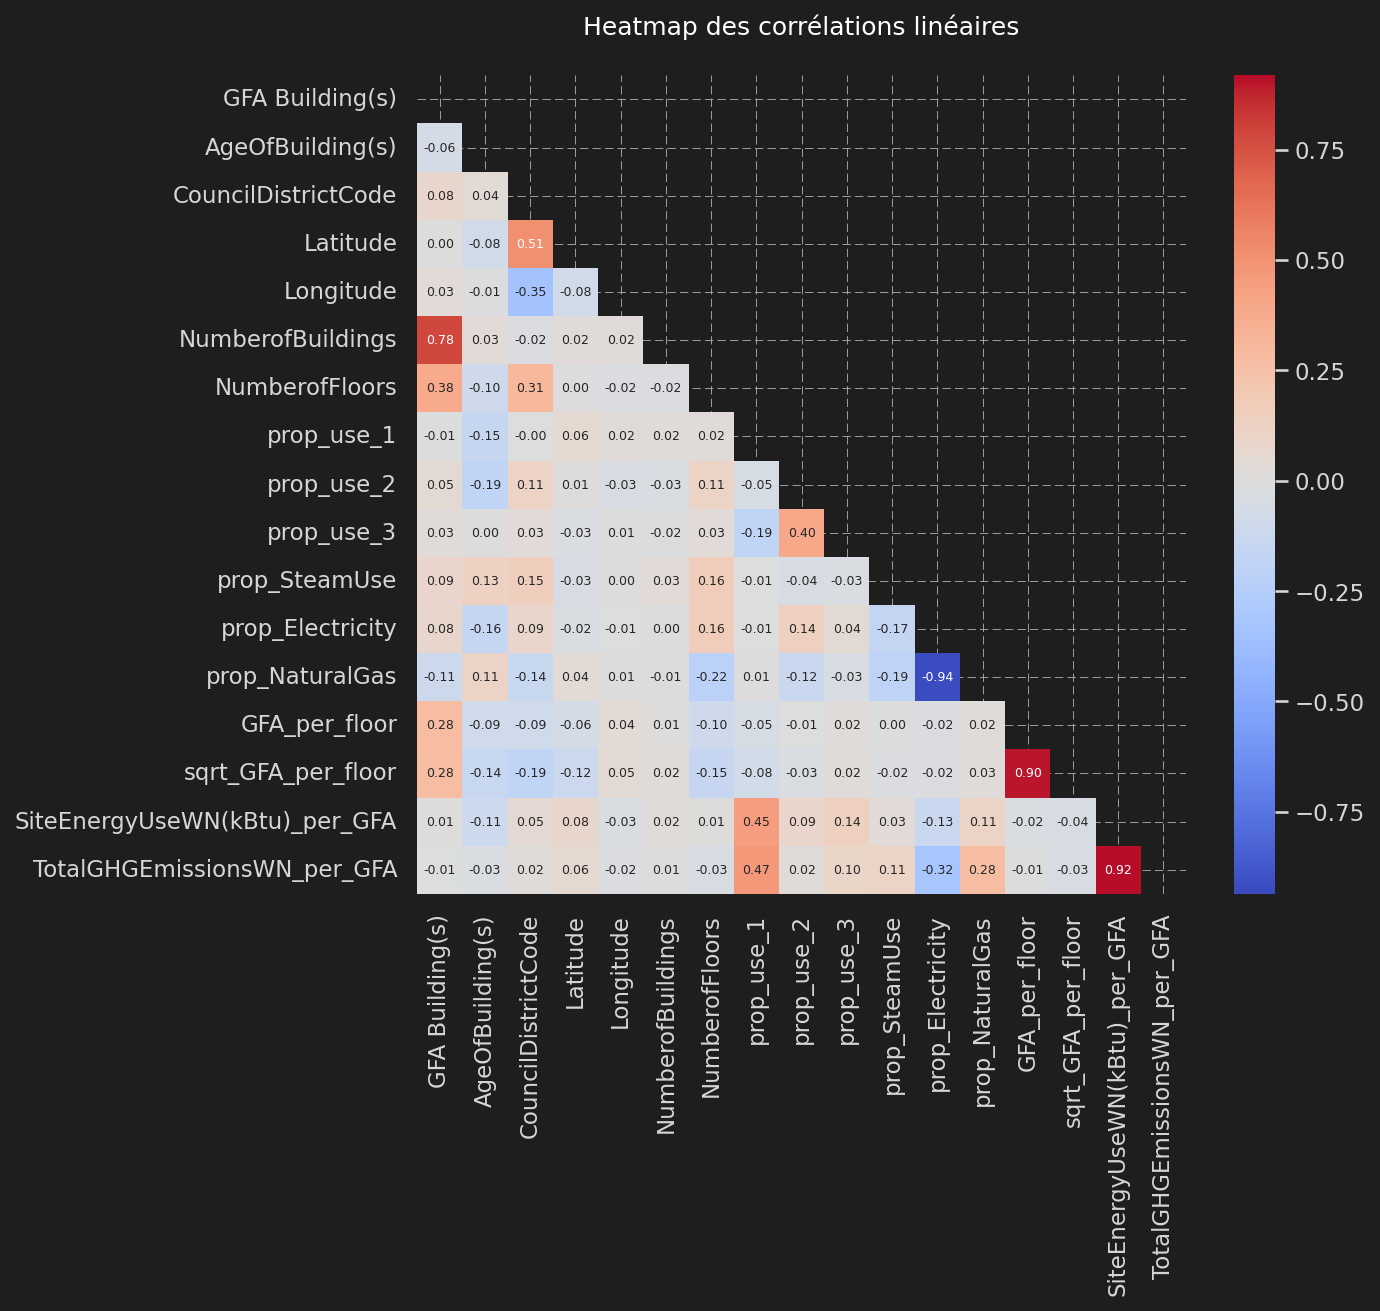

In [232]:
tmp = pd.DataFrame()
tmp['GFA Building(s)'] = GFA_ref
tmp2 = df.select_dtypes(include=[np.number]).copy()
tmp[tmp2.columns] = tmp2.values 
tmp.iloc[:,-2:] = tmp.iloc[:,-2:].values / GFA_ref.reshape(-1,1)



tmp.rename( columns={var:f'{var}_per_GFA' for var in tmp.columns.tolist()[-2:] }, inplace=True )
display( tmp.columns )
corr = tmp.corr()

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
fig, ax = plt.subplots(figsize=(21*cm,18*cm))
ax = sns.heatmap(corr, annot=True, fmt=".2f", annot_kws={'size':6}, 
                 mask=mask, center=0, cmap="coolwarm")
plt.title(f"Heatmap des corrélations linéaires\n")
plt.show()

fig.tight_layout()
savefig( fig, 'Figures/correl_engineered.pdf')

In [233]:
variables = corr.columns.values[ ~corr.columns.str.contains( 'SiteEnergy|Emissi') ]
variables

array(['GFA Building(s)', 'AgeOfBuilding(s)', 'CouncilDistrictCode',
       'Latitude', 'Longitude', 'NumberofBuildings', 'NumberofFloors',
       'prop_use_1', 'prop_use_2', 'prop_use_3', 'prop_SteamUse',
       'prop_Electricity', 'prop_NaturalGas', 'GFA_per_floor',
       'sqrt_GFA_per_floor'], dtype=object)

In [234]:

tmp2 = tmp[variables]
tmp2 = tmp2.drop( columns='GFA Building(s)' )

tmp_vif = pd.DataFrame()
tmp_vif["feature"] = tmp2.columns
tmp_vif["VIF"] = [variance_inflation_factor(tmp2.values, i) 
                   for i in range(len(tmp2.columns))]

# print( df2ltx( tmp_vif[tmp_vif['VIF'] > 5].round(2) ) )

display(tmp_vif[tmp_vif['VIF'] > 5])

,feature,VIF
9,prop_SteamUse,3.425206e+05
10,prop_Electricity,2.045063e+07
11,prop_NaturalGas,5.218316e+06
12,GFA_per_floor,5.502334e+00
13,sqrt_GFA_per_floor,5.823218e+00


In [235]:
mask = 'PropertyGFABuilding(s)'
print( f'{mask} in df_annexe:', mask in df_annexe.columns )

PropertyGFABuilding(s) in df_annexe: True


## 5.7. <a id='toc5_7_'></a>[Scatter plots](#toc0_)

1109    ballard center
Name: PropertyName, dtype: object

,AgeOfBuilding(s),CouncilDistrictCode,Neighborhood,Latitude,Longitude,NumberofBuildings,NumberofFloors,Type_use_1,prop_use_1,Type_use_2,prop_use_2,Type_use_3,prop_use_3,prop_SteamUse,prop_Electricity,prop_NaturalGas,GFA_per_floor,sqrt_GFA_per_floor,SiteEnergyUseWN(kBtu),TotalGHGEmissionsWN
1109,50,6,ballard,47.69875,-122.36725,1,2,medical,9.90099,parking,0.0,NaN,0.0,0.0,0.293148,0.706852,1818.0,42.638011,1.248913e+07,494.375635


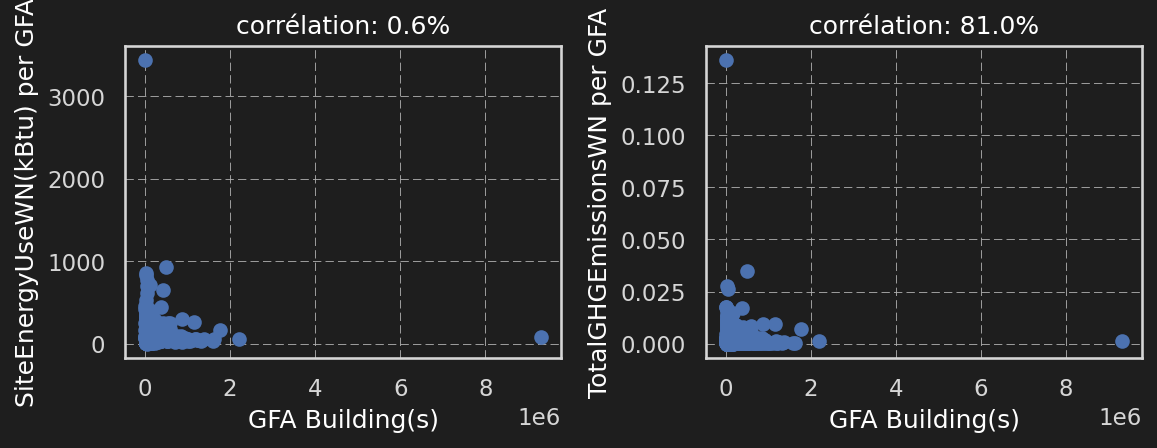

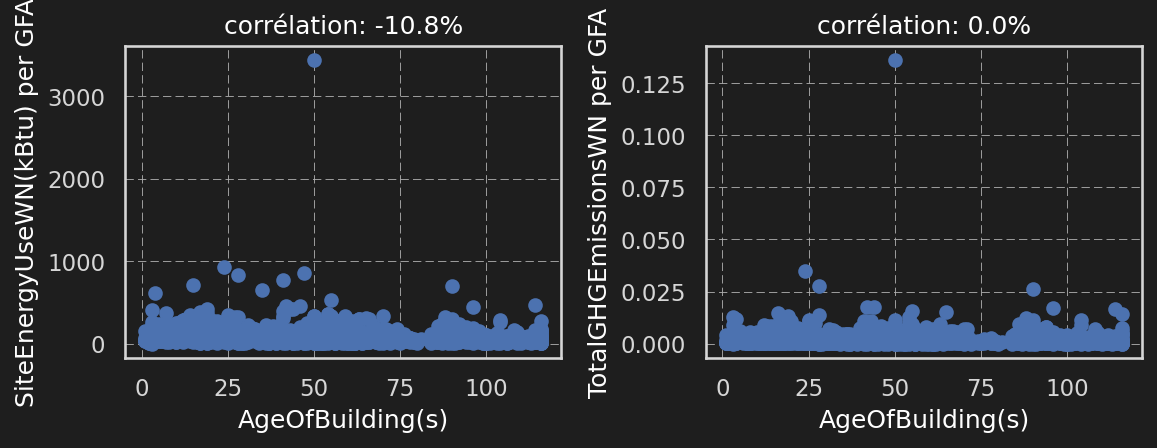

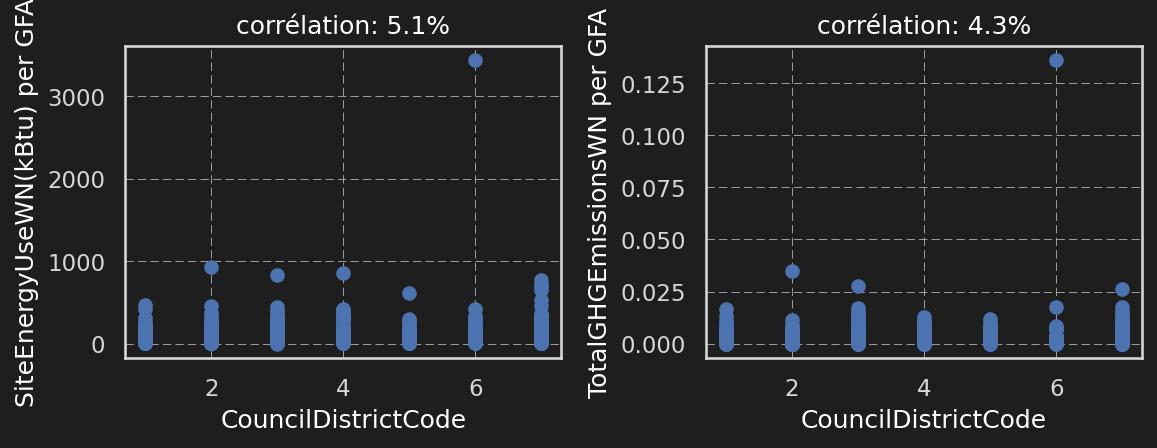

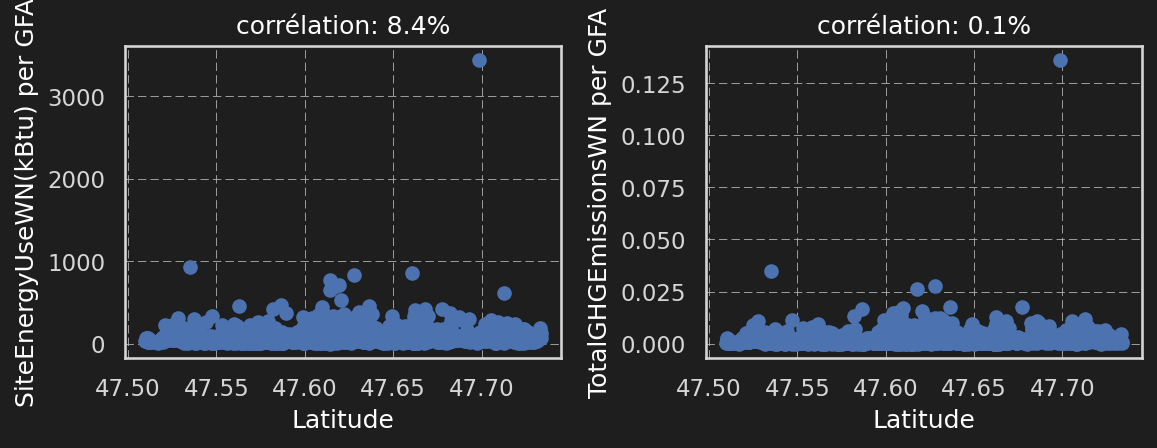

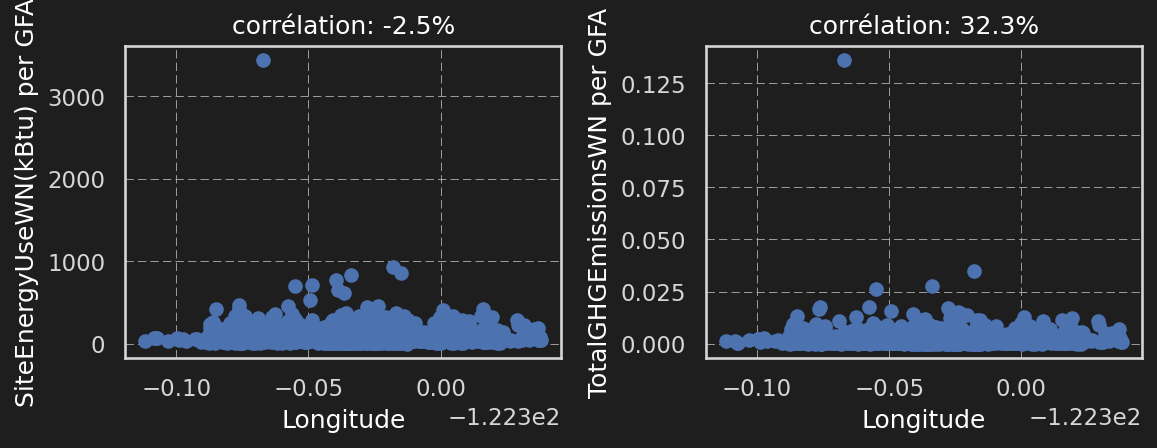

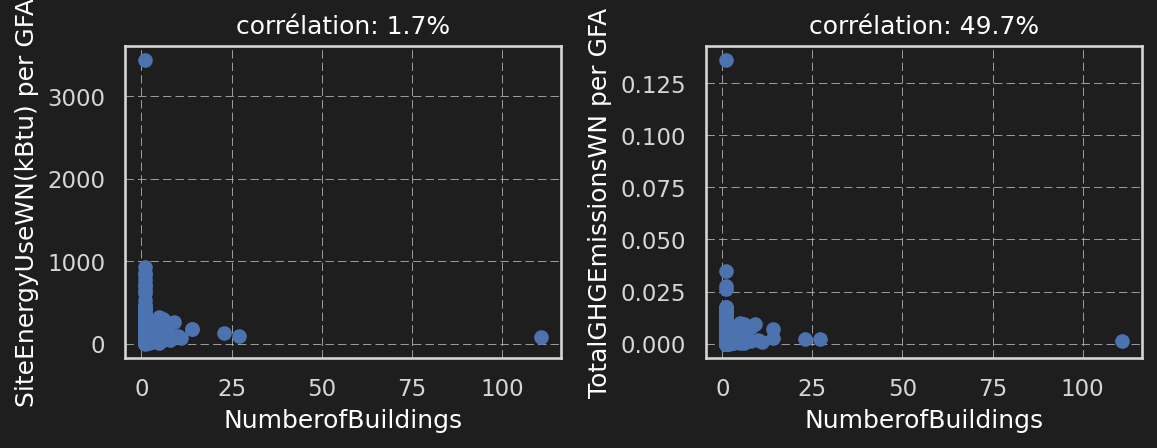

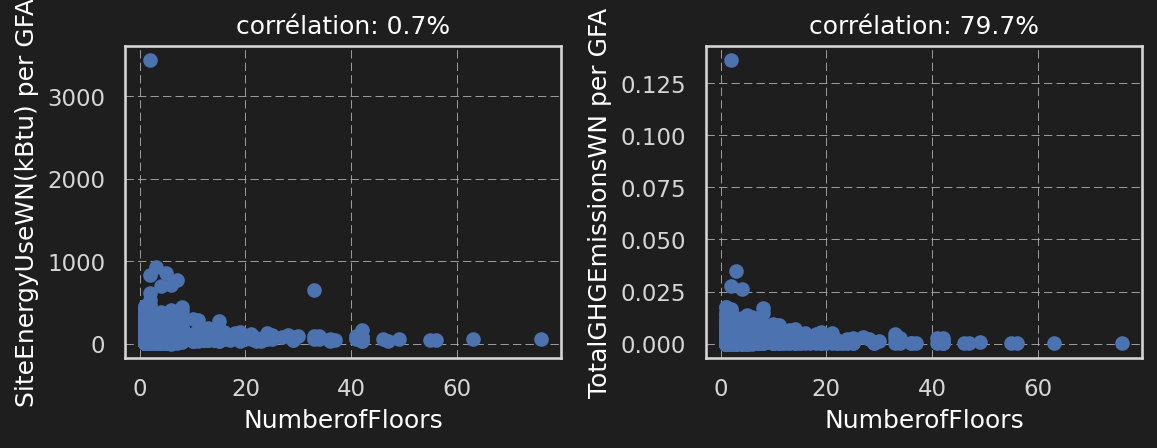

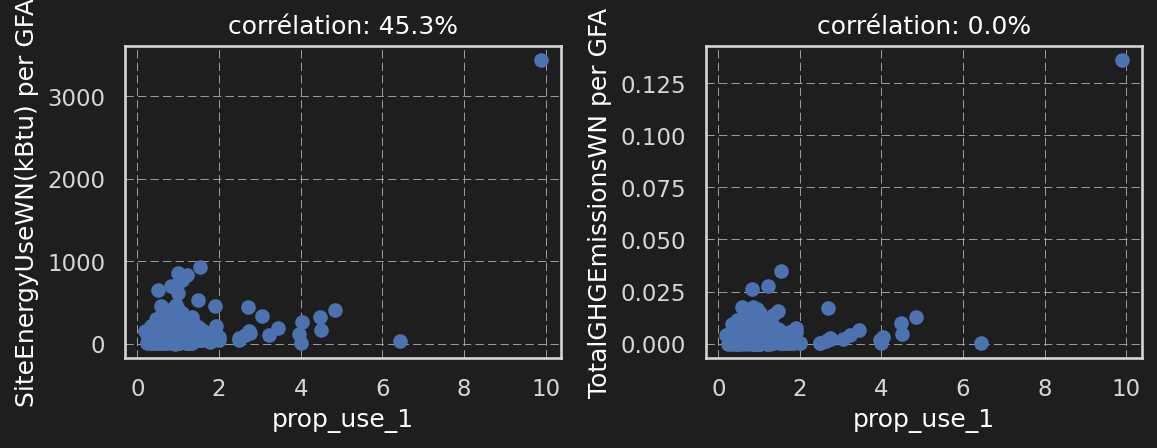

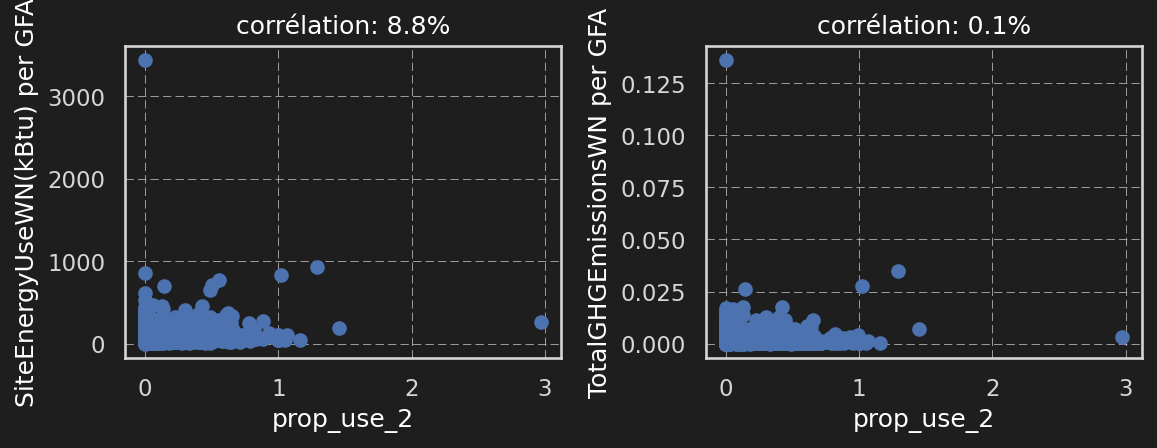

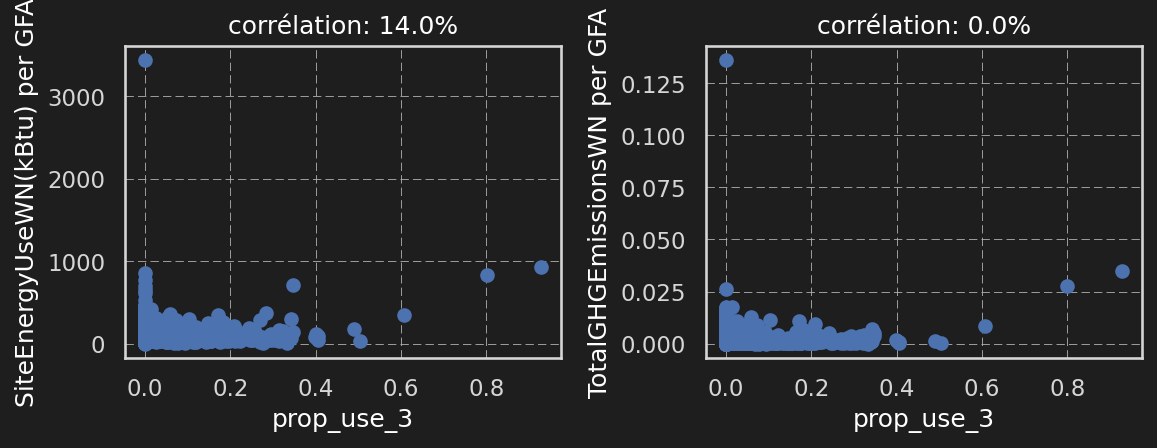

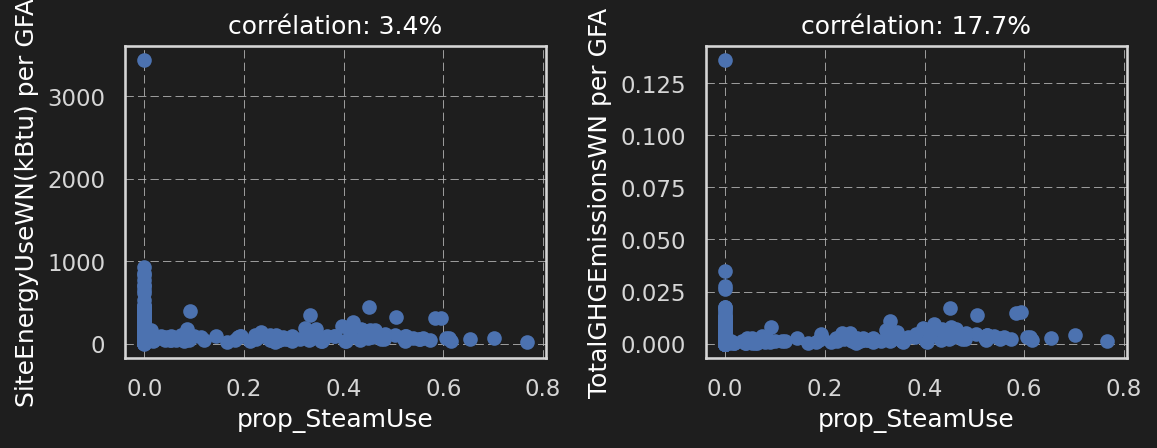

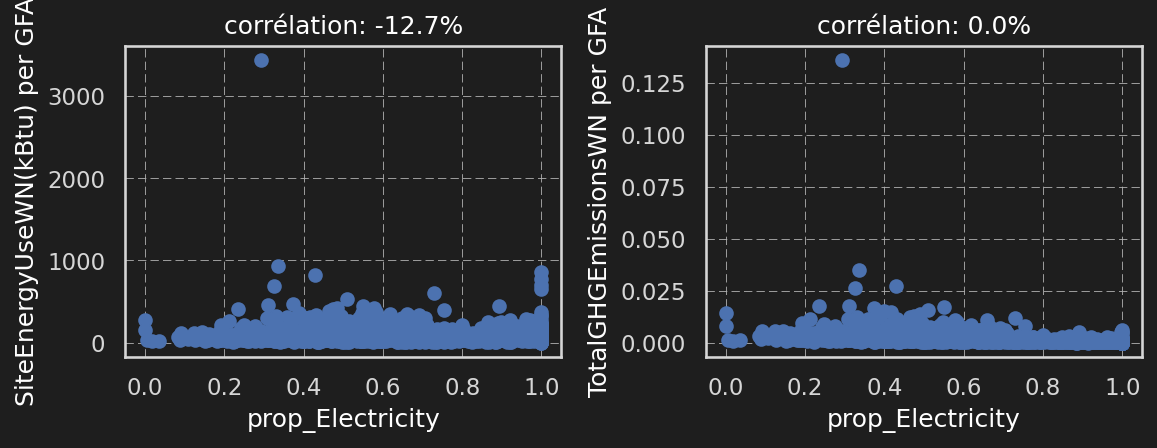

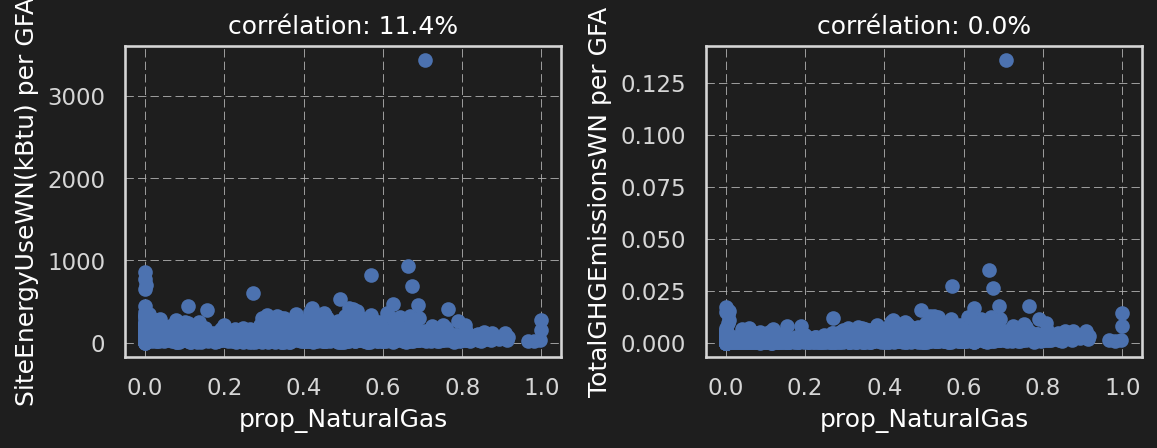

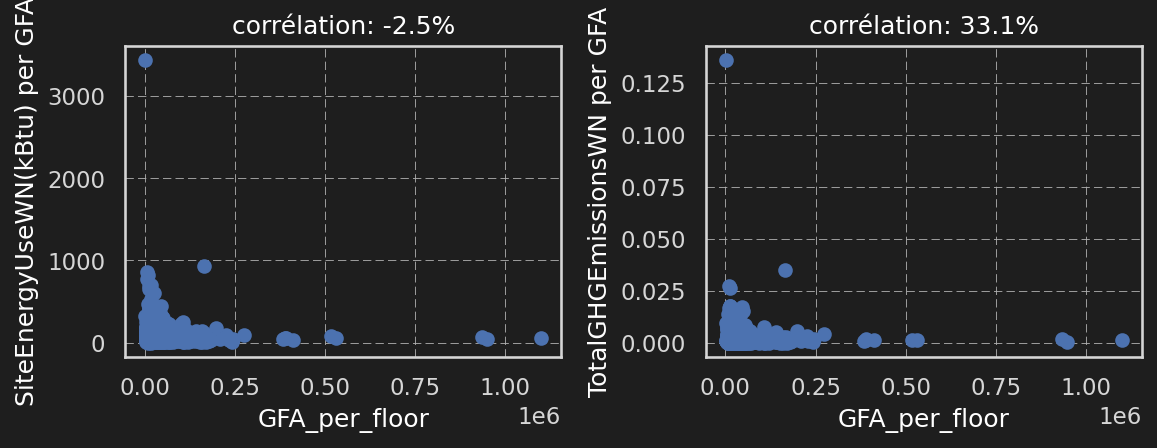

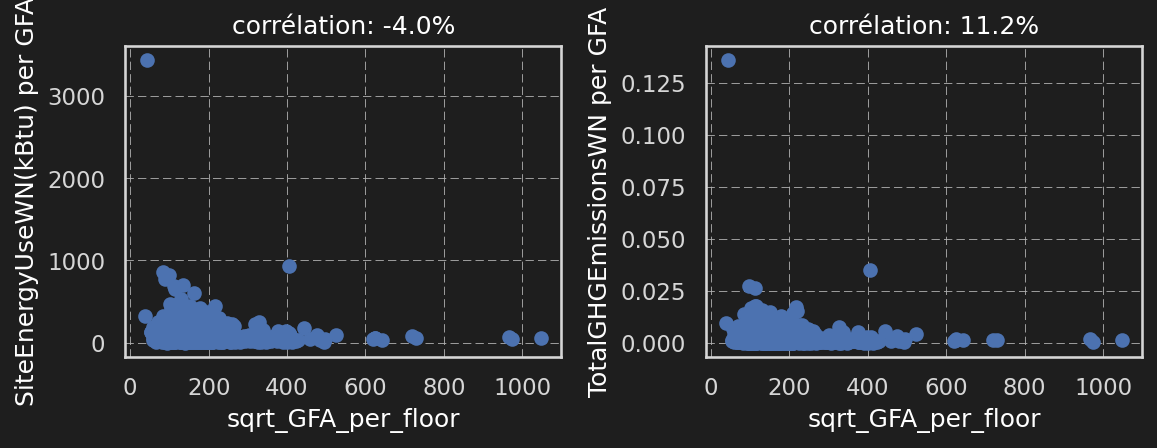

In [236]:
y,y2 = tmp.iloc[:,-2:].values.T

# outlier sur les cibles
loc = y > 1100
sr_loc
display( df_annexe.loc[loc, 'PropertyName'])
display( df.loc[ loc, : ] )

for var in variables:
    fig, axs = plt.subplots( ncols=2, figsize=(20*cm,8*cm) )
    x = tmp[var].values
    axs[0].plot( x, y, 'bo')
    axs[1].plot( x, y2, 'bo')
    axs[0].set_xlabel(var)
    axs[1].set_xlabel(var)
    axs[0].set_ylabel(targets[0] + ' per GFA')
    axs[1].set_ylabel(targets[1] + ' per GFA')
    axs[0].set_title( 'corrélation: {:.1f}%'.format( 100* st.pearsonr(x,y)[0] ) )
    axs[1].set_title( 'corrélation: {:.1f}%'.format( 100* st.pearsonr(x,y)[1] ) )
    fig.tight_layout()

## 5.8. <a id='toc5_8_'></a>[histogramme / transformation](#toc0_)

,AgeOfBuilding(s),CouncilDistrictCode,Latitude,Longitude,NumberofBuildings,NumberofFloors,prop_use_1,prop_use_2,prop_use_3,prop_SteamUse,prop_Electricity,prop_NaturalGas,GFA_per_floor,sqrt_GFA_per_floor
count,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1.551000e+03,1551.000000
mean,54.660219,4.410058,47.616304,-122.333510,1.212121,4.192134,0.948148,0.154102,0.025287,0.022650,0.704535,0.272815,3.127920e+04,157.049826
std,32.900847,2.194010,0.047022,0.023308,3.028596,6.267208,0.438830,0.226065,0.072386,0.094696,0.263110,0.264417,5.764929e+04,81.356122
min,1.000000,1.000000,47.509590,-122.411820,1.000000,1.000000,0.186469,0.000000,0.000000,0.000000,0.000000,0.000000,1.433333e+03,37.859389
25%,28.000000,2.000000,47.587695,-122.342940,1.000000,1.000000,0.806005,0.000000,0.000000,0.000000,0.491662,0.000000,1.180067e+04,108.630873
50%,51.000000,4.000000,47.612400,-122.333190,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.713660,0.228642,2.000000e+04,141.421356
75%,87.000000,7.000000,47.649045,-122.322630,1.000000,4.000000,1.000000,0.270743,0.000000,0.000000,1.000000,0.490680,3.134600e+04,177.048012
max,116.000000,7.000000,47.733870,-122.261800,111.000000,76.000000,9.900990,2.974256,0.929094,0.766988,1.000000,1.000000,1.100000e+06,1048.808848


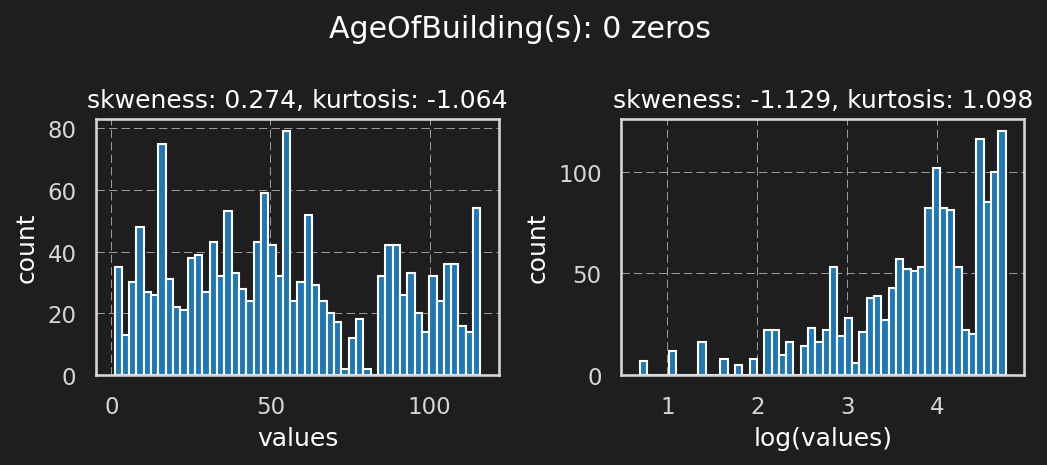

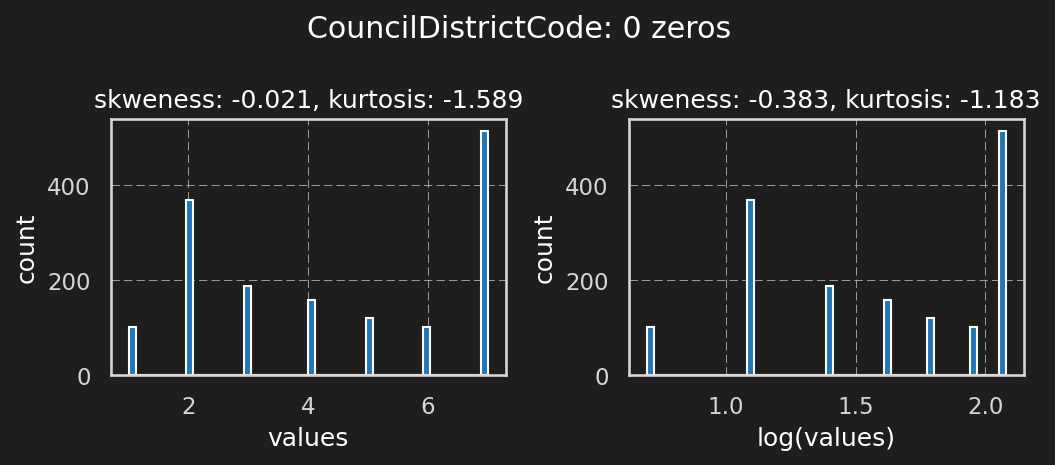

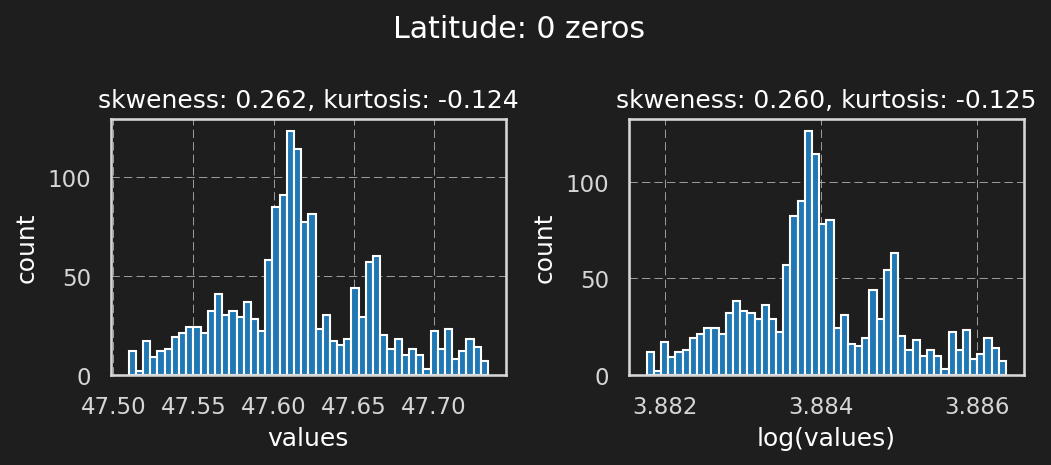

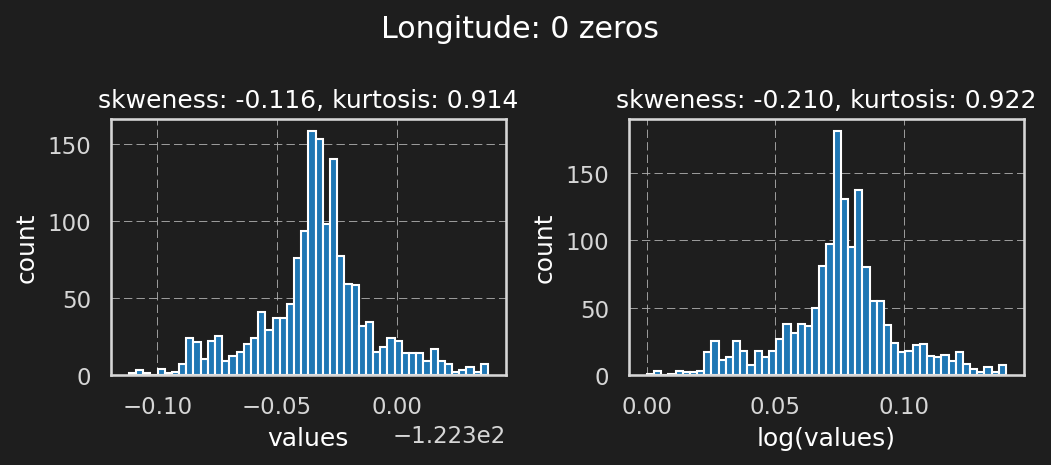

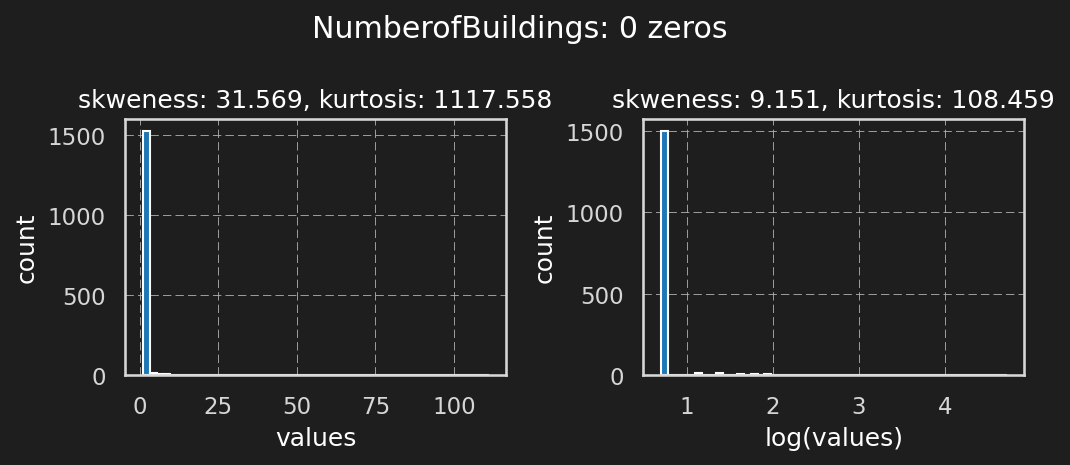

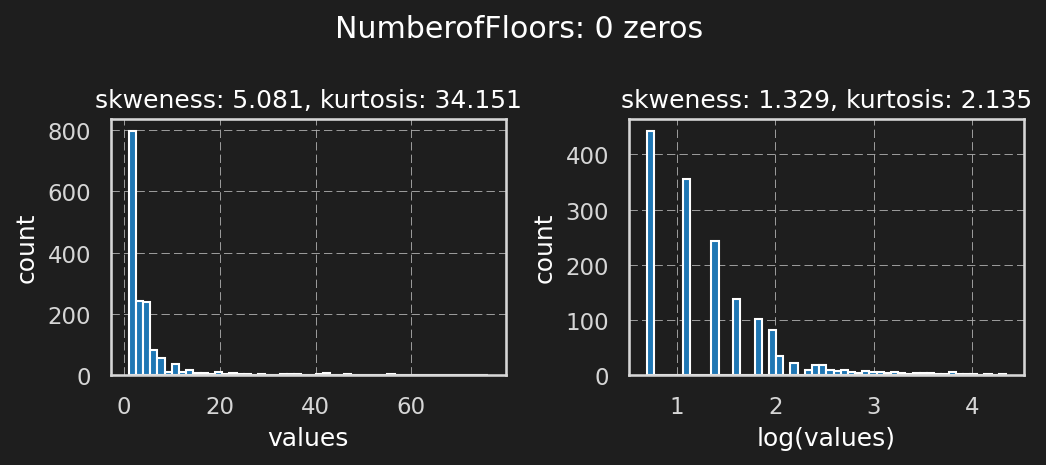

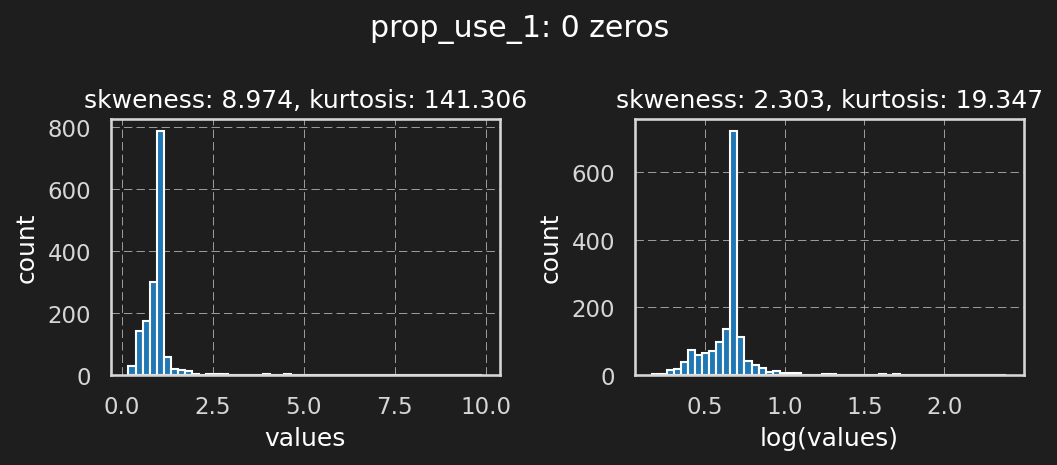

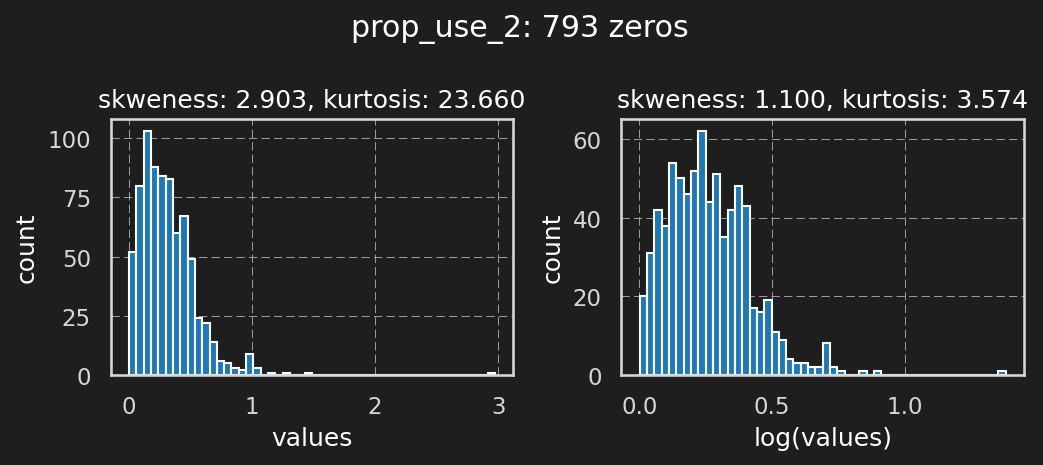

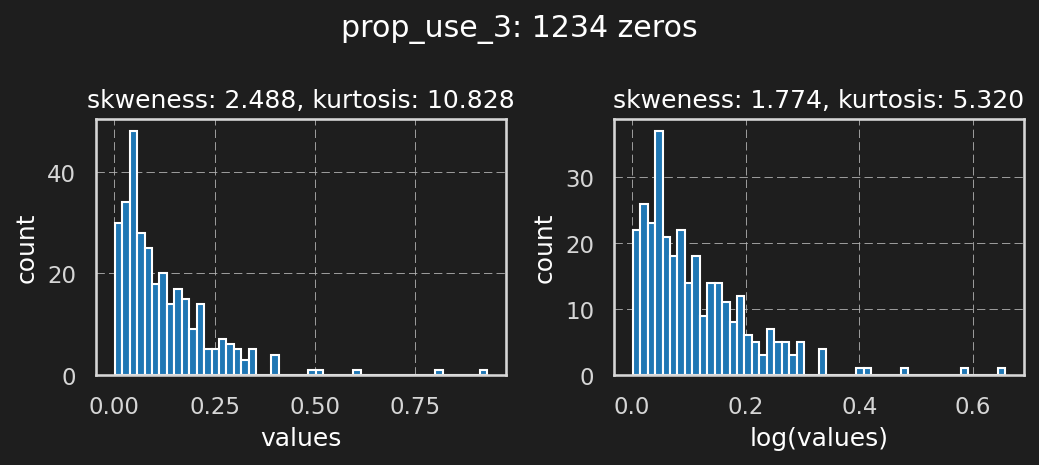

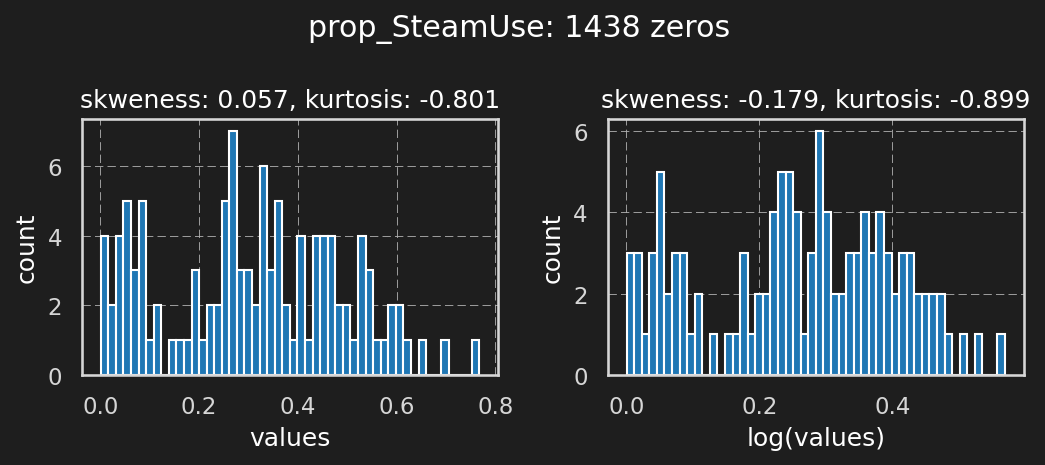

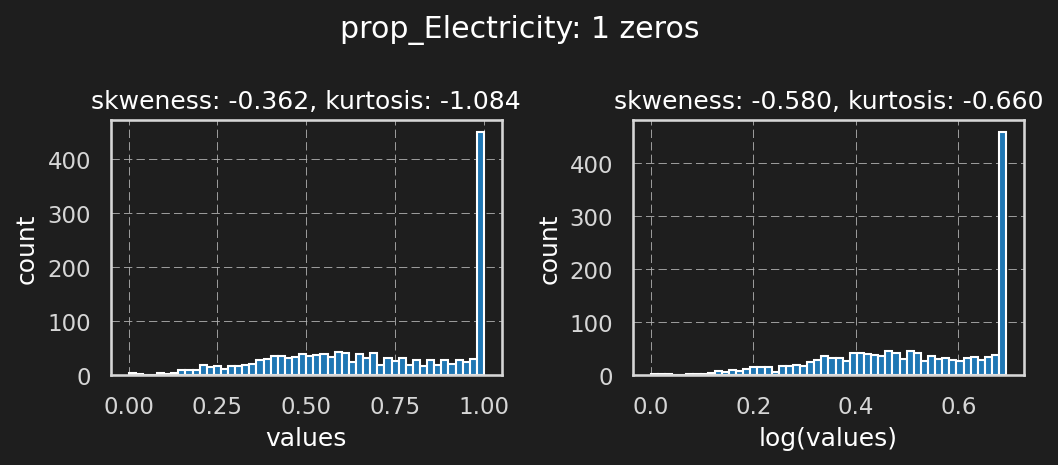

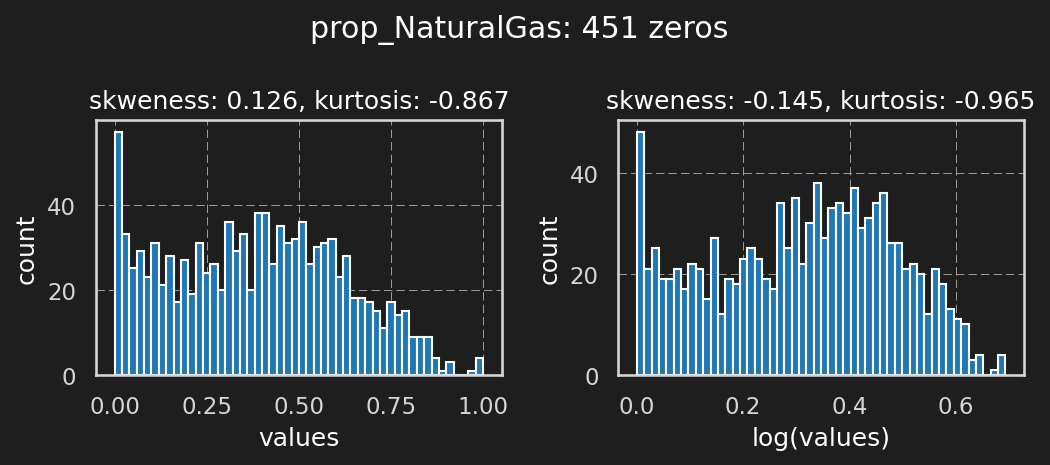

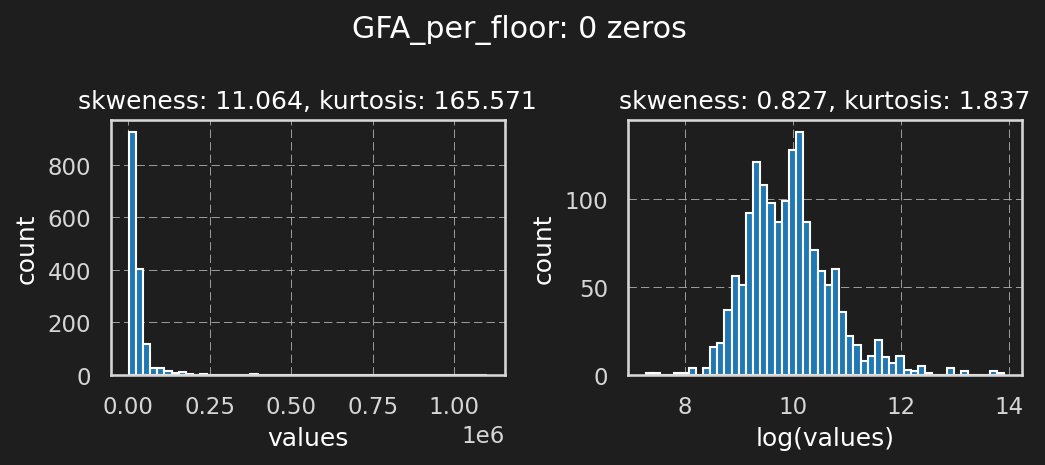

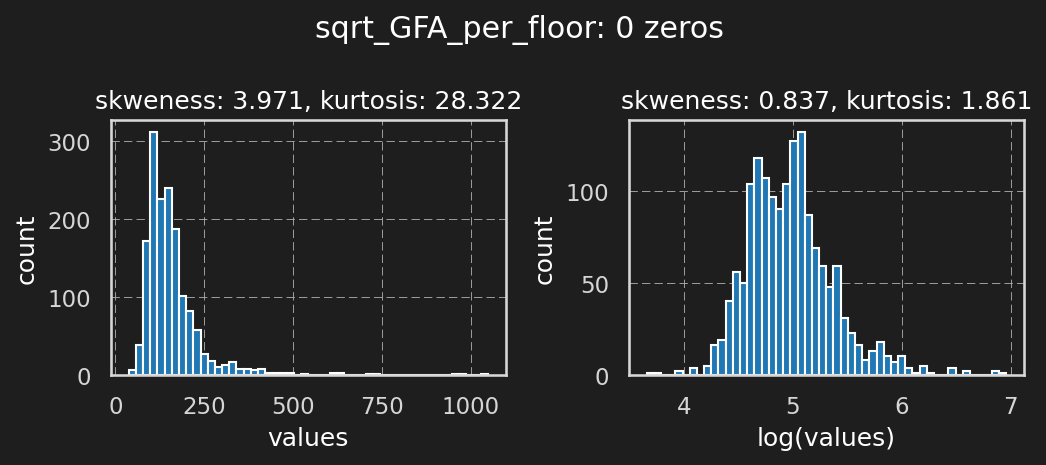

In [237]:
display( df[variables[1:]].describe() )

for var in variables[1:]:
    values = df[var]
    n_zeros = (values==0).sum()
    values = values[values !=0]
    if '%' in var:
        n_ones = (values==1.).sum()
        values = values[values!=1]
    kurtosis = st.kurtosis( values )
    skew = st.skew( values )

    suptitle = f'{var}: {n_zeros} zeros'
    if '%' in var:
        suptitle += f', {n_ones} ones'

    fig, axs = plt.subplots( ncols=2, figsize=(18*cm,8*cm))
    fig.suptitle( suptitle )
    axs[0].hist( values, bins=50 )
    axs[0].set_xlabel( 'values'  )
    axs[0].set_ylabel( 'count' )
    axs[0].set_title( f'skweness: {skew:.3f}, kurtosis: {kurtosis:.3f}')

    values_log = np.log(values + (1 - min(0,values.min())))
    kurtosis = st.kurtosis( values_log )
    skew = st.skew( values_log )
    axs[1].hist( values_log, bins=50 )
    axs[1].set_xlabel( 'log(values)' )
    axs[1].set_ylabel( 'count' )
    axs[1].set_title( f'skweness: {skew:.3f}, kurtosis: {kurtosis:.3f}')

    fig.tight_layout()

In [238]:
features = [ feature for feature in df.columns if not feature in vars_to_delete ]

print( features )

features_log = df.columns[df.columns.str.contains( '|'.join(['per_floor','Numberof']) )].tolist()
print('\nfeatures à passer au log:\n', features_log )

['AgeOfBuilding(s)', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'NumberofBuildings', 'NumberofFloors', 'Type_use_1', 'prop_use_1', 'Type_use_2', 'prop_use_2', 'Type_use_3', 'prop_use_3', 'prop_SteamUse', 'prop_Electricity', 'prop_NaturalGas', 'GFA_per_floor', 'sqrt_GFA_per_floor', 'SiteEnergyUseWN(kBtu)', 'TotalGHGEmissionsWN']

features à passer au log:
 ['NumberofBuildings', 'NumberofFloors', 'GFA_per_floor', 'sqrt_GFA_per_floor']


## 5.9. <a id='toc5_9_'></a>[OneHotEncoding](#toc0_)

In [239]:
value_counts = df['Type_use_1'].value_counts().add(
    df['Type_use_2'].value_counts(), fill_value=0 ).add(
    df['Type_use_3'].value_counts(), fill_value=0 ).astype(int)

PropertyUseTypes = value_counts.index
PropertyUseTypes = PropertyUseTypes.drop( 'parking' ) # valeur redondante avec % GFA Parking
print('propery use types:', PropertyUseTypes.tolist() )

X_propotion_PropertyUseTypeGFA = np.zeros( (len(df), len(PropertyUseTypes)) )
for i, index in enumerate(df.index):
    for j in range(1,4) :
        usetype = df.at[index, f'Type_use_{j}']
        if isinstance( usetype, float ): # test if isnan
            break
        if usetype == 'parking':
            continue
        k = PropertyUseTypes.get_loc( usetype )
        X_propotion_PropertyUseTypeGFA[i,k] += df.at[index, f'prop_use_{j}']

PropertyUseTypes = [ f'ohe0 {var}' for var in PropertyUseTypes]

propery use types: ['data center', 'education', 'entertainment - public assembly', 'industrial', 'lifestyle center', 'medical', 'medical office', 'office', 'other', 'other - entertainment/public assembly', 'residential - hotel', 'restaurant', 'science', 'self-storage facility', 'services', 'store', 'utility', 'worship facility']


In [240]:
df_hotencoding_usetype = pd.DataFrame( X_propotion_PropertyUseTypeGFA, columns=PropertyUseTypes, index=df.index )
print( 'DataFrame usetype shape:', df_hotencoding_usetype.shape )
df_hotencoding_usetype.head(10).round(2)

# print( df2ltx( df_hotencoding_usetype.iloc[15:20,:5].head(5).round(2) ) )

DataFrame usetype shape: (1551, 18)


,ohe0 data center,ohe0 education,ohe0 entertainment - public assembly,ohe0 industrial,ohe0 lifestyle center,ohe0 medical,ohe0 medical office,ohe0 office,ohe0 other,ohe0 other - entertainment/public assembly,ohe0 residential - hotel,ohe0 restaurant,ohe0 science,ohe0 self-storage facility,ohe0 services,ohe0 store,ohe0 utility,ohe0 worship facility
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.95,0.05,0.0,0.0,0.0,0.0,0.00,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.09,0.00,0.0,0.0,0.0,0.0,0.00,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,1.48,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.98,0.00,0.0,0.0,0.0,0.0,0.00,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0


In [241]:
key = 'Neighborhood'
df[key] = df[key].astype('category')
print( df[key].cat.categories )
features_location = [ f'ohe1 {var}' for var in df[key].cat.categories.tolist()]

X_location = np.zeros( (len(df), len(df[key].cat.categories) ) )
X_location[range(len(df)), df[key].cat.codes] = 1.
df_hotencoding_location = pd.DataFrame( X_location, columns=features_location, index=df.index )

print( 'DataFrame location shape:', df_hotencoding_location.shape )
display(df_hotencoding_location.sample(5) )

Index(['ballard', 'central', 'delridge', 'downtown', 'east',
       'greater duwamish', 'lake union', 'magnolia / queen anne', 'north',
       'northeast', 'northwest', 'southeast', 'southwest'],
      dtype='object')
DataFrame location shape: (1551, 13)


,ohe1 ballard,ohe1 central,ohe1 delridge,ohe1 downtown,ohe1 east,ohe1 greater duwamish,ohe1 lake union,ohe1 magnolia / queen anne,ohe1 north,ohe1 northeast,ohe1 northwest,ohe1 southeast,ohe1 southwest
556,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
254,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
548,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3109,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [242]:
print('DataFrame shape:', df.shape )
df.drop( columns= ['Neighborhood', 'Type_use_1', 'prop_use_1', 
    'Type_use_2', 'prop_use_2', 'Type_use_3', 'prop_use_3'], inplace=True )
print('DataFrame shape:', df.shape )

DataFrame shape: (1551, 20)
DataFrame shape: (1551, 13)


In [243]:
df.columns

Index(['AgeOfBuilding(s)', 'CouncilDistrictCode', 'Latitude', 'Longitude',
       'NumberofBuildings', 'NumberofFloors', 'prop_SteamUse',
       'prop_Electricity', 'prop_NaturalGas', 'GFA_per_floor',
       'sqrt_GFA_per_floor', 'SiteEnergyUseWN(kBtu)', 'TotalGHGEmissionsWN'],
      dtype='object')

# 6. <a id='toc6_'></a>[Sauvegarde](#toc0_)

In [244]:
path = 'data/cleaned/'
filename = '2016_Building_Energy_Benchmarking'
compression = 'gzip'

with open( path + filename + 'features_log', 'wb') as file:
    pickle.dump( features_log , file )

df.to_pickle( r'{:}{:}.pkl'.format(path, filename), compression=compression)
df_annexe.to_pickle( r'{:}{:}_annexe.pkl'.format(path, filename), compression=compression)
df_hotencoding_usetype.to_pickle( r'{:}{:}_usetype.pkl'.format(path, filename), compression=compression)
df_hotencoding_location.to_pickle( r'{:}{:}_location.pkl'.format(path, filename), compression=compression)